<a href="https://colab.research.google.com/github/ThamaraiselviKuselan/AGILE_FAT_COLLAB/blob/main/hackathon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install xgboost networkx gradio plotly pillow opencv-python

In [ ]:
import os
import json
import pickle
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cv2
from PIL import Image

import networkx as nx

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

from xgboost import XGBClassifier

import plotly.graph_objects as go
import gradio as gr

warnings.filterwarnings("ignore")

print("All libraries imported successfully.")

All libraries imported successfully.


In [ ]:
PROJECT_DIR = "/content/DisasterVision"

folders = [
    "data/satellite/before",
    "data/satellite/after",
    "data/masks",
    "models",
    "config",
    "outputs/flood_masks",
    "outputs/predictions",
    "outputs/screenshots"
]

for folder in folders:
    os.makedirs(os.path.join(PROJECT_DIR, folder), exist_ok=True)

print("Project directory:", PROJECT_DIR)

Project directory: /content/DisasterVision


In [ ]:
zones = {
    "A": {
        "name": "Zone A",
        "population": 1200,
        "elevation": 5,
        "critical_infrastructure": True
    },

    "B": {
        "name": "Zone B",
        "population": 700,
        "elevation": 12,
        "critical_infrastructure": False
    },

    "C": {
        "name": "Zone C",
        "population": 350,
        "elevation": 20,
        "critical_infrastructure": False
    }
}

with open(f"{PROJECT_DIR}/config/zones.json", "w") as f:
    json.dump(zones, f, indent=4)

print(json.dumps(zones, indent=2))

{
  "A": {
    "name": "Zone A",
    "population": 1200,
    "elevation": 5,
    "critical_infrastructure": true
  },
  "B": {
    "name": "Zone B",
    "population": 700,
    "elevation": 12,
    "critical_infrastructure": false
  },
  "C": {
    "name": "Zone C",
    "population": 350,
    "elevation": 20,
    "critical_infrastructure": false
  }
}


In [ ]:
roads = {
    "R1": {
        "from": "Hospital",
        "to": "Junction1",
        "distance": 1.2
    },

    "R2": {
        "from": "Junction1",
        "to": "ZoneA",
        "distance": 2.0
    },

    "R3": {
        "from": "Hospital",
        "to": "Junction2",
        "distance": 1.8
    },

    "R4": {
        "from": "Junction2",
        "to": "ZoneA",
        "distance": 2.5
    }
}

with open(f"{PROJECT_DIR}/config/roads.json", "w") as f:
    json.dump(roads, f, indent=4)

print(json.dumps(roads, indent=2))

{
  "R1": {
    "from": "Hospital",
    "to": "Junction1",
    "distance": 1.2
  },
  "R2": {
    "from": "Junction1",
    "to": "ZoneA",
    "distance": 2.0
  },
  "R3": {
    "from": "Hospital",
    "to": "Junction2",
    "distance": 1.8
  },
  "R4": {
    "from": "Junction2",
    "to": "ZoneA",
    "distance": 2.5
  }
}


In [ ]:
scenarios = {

    "NORMAL": {
        "rainfall": 20,
        "water_level": 0.4,
        "rise_rate": 0.02
    },

    "SEVERE FLOOD": {
        "rainfall": 90,
        "water_level": 2.2,
        "rise_rate": 0.12
    },

    "ROUTE FAILURE": {
        "rainfall": 125,
        "water_level": 3.5,
        "rise_rate": 0.20
    }
}

with open(f"{PROJECT_DIR}/config/scenarios.json", "w") as f:
    json.dump(scenarios, f, indent=4)

print(json.dumps(scenarios, indent=2))

{
  "NORMAL": {
    "rainfall": 20,
    "water_level": 0.4,
    "rise_rate": 0.02
  },
  "SEVERE FLOOD": {
    "rainfall": 90,
    "water_level": 2.2,
    "rise_rate": 0.12
  },
  "ROUTE FAILURE": {
    "rainfall": 125,
    "water_level": 3.5,
    "rise_rate": 0.2
  }
}


In [ ]:
scenarios = {

    "NORMAL": {
        "rainfall": 20,
        "water_level": 0.4,
        "rise_rate": 0.02
    },

    "SEVERE FLOOD": {
        "rainfall": 90,
        "water_level": 2.2,
        "rise_rate": 0.12
    },

    "ROUTE FAILURE": {
        "rainfall": 125,
        "water_level": 3.5,
        "rise_rate": 0.20
    }
}

with open(f"{PROJECT_DIR}/config/scenarios.json", "w") as f:
    json.dump(scenarios, f, indent=4)

print(json.dumps(scenarios, indent=2))

{
  "NORMAL": {
    "rainfall": 20,
    "water_level": 0.4,
    "rise_rate": 0.02
  },
  "SEVERE FLOOD": {
    "rainfall": 90,
    "water_level": 2.2,
    "rise_rate": 0.12
  },
  "ROUTE FAILURE": {
    "rainfall": 125,
    "water_level": 3.5,
    "rise_rate": 0.2
  }
}


In [ ]:
# ============================================
# CREATE ENVIRONMENTAL DATASET
# ============================================

import numpy as np
import pandas as pd

np.random.seed(42)

n_samples = 2000

environment_df = pd.DataFrame({
    "rainfall": np.random.uniform(0, 150, n_samples),
    "water_level": np.random.uniform(0, 5, n_samples),
    "rise_rate": np.random.uniform(0, 0.25, n_samples),
    "elevation": np.random.uniform(2, 30, n_samples),
    "distance_from_river": np.random.uniform(0.1, 10, n_samples)
})

# Synthetic flood-risk relationship
environment_df["flood_score"] = (
    0.35 * (environment_df["rainfall"] / 150)
    + 0.30 * (environment_df["water_level"] / 5)
    + 0.20 * (environment_df["rise_rate"] / 0.25)
    + 0.10 * (1 - environment_df["elevation"] / 30)
    + 0.05 * (1 - environment_df["distance_from_river"] / 10)
)

# Add small variation
environment_df["flood_score"] += np.random.normal(
    0, 0.05, n_samples
)

# Keep score between 0 and 1
environment_df["flood_score"] = environment_df["flood_score"].clip(0, 1)

# Target variable
environment_df["future_flood"] = (
    environment_df["flood_score"] >= 0.50
).astype(int)

print("✅ environment_df created")
print("Rows:", len(environment_df))
print("Columns:", list(environment_df.columns))

display(environment_df.head())

✅ environment_df created
Rows: 2000
Columns: ['rainfall', 'water_level', 'rise_rate', 'elevation', 'distance_from_river', 'flood_score', 'future_flood']


,rainfall,water_level,rise_rate,elevation,distance_from_river,flood_score,future_flood
0,56.181018,1.308528,0.142999,20.151195,7.230652,0.296283,0
1,142.607146,1.234894,0.201358,6.826818,6.904102,0.604394,1
2,109.799091,4.531273,0.190040,26.427048,1.047967,0.756217,1
3,89.798773,1.247731,0.038475,19.167255,9.233467,0.296422,0
4,23.402796,1.359749,0.037312,6.401709,5.727875,0.321695,0


In [ ]:
# ============================================
# PREPARE DATA FOR XGBOOST
# ============================================

features = [
    "rainfall",
    "water_level",
    "rise_rate",
    "elevation",
    "distance_from_river"
]

X = environment_df[features]
y = environment_df["future_flood"]

print("✅ X and y created")
print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())

✅ X and y created
X shape: (2000, 5)
y shape: (2000,)

Target distribution:
future_flood
0    1000
1    1000
Name: count, dtype: int64


In [ ]:
# ============================================
# TRAIN XGBOOST FUTURE FLOOD MODEL
# ============================================

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

xgb_model = XGBClassifier(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"✅ XGBoost model trained")
print(f"Accuracy: {accuracy:.2%}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

✅ XGBoost model trained
Accuracy: 86.50%

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.84      0.86       200
           1       0.85      0.89      0.87       200

    accuracy                           0.86       400
   macro avg       0.87      0.86      0.86       400
weighted avg       0.87      0.86      0.86       400



In [ ]:
# ============================================
# FUTURE FLOOD PREDICTION FUNCTION
# ============================================

def predict_future_flood(
    rainfall,
    water_level,
    rise_rate,
    elevation,
    distance_from_river
):
    input_data = pd.DataFrame([{
        "rainfall": rainfall,
        "water_level": water_level,
        "rise_rate": rise_rate,
        "elevation": elevation,
        "distance_from_river": distance_from_river
    }])

    probability = xgb_model.predict_proba(input_data)[0][1]

    if probability >= 0.75:
        risk_level = "CRITICAL"
    elif probability >= 0.50:
        risk_level = "HIGH"
    elif probability >= 0.25:
        risk_level = "MEDIUM"
    else:
        risk_level = "LOW"

    return probability, risk_level

In [ ]:
# ============================================
# TEST XGBOOST PREDICTION
# ============================================

probability, risk = predict_future_flood(
    rainfall=90,
    water_level=2.2,
    rise_rate=0.12,
    elevation=5,
    distance_from_river=1.5
)

print(f"Future Flood Probability: {probability:.1%}")
print(f"Predicted Risk Level: {risk}")

Future Flood Probability: 93.9%
Predicted Risk Level: CRITICAL


HTTP status: 200
✅ Satellite image downloaded successfully
📁 Saved: /content/satellite_flood_image.jpg
📐 Size: (4292, 2540)


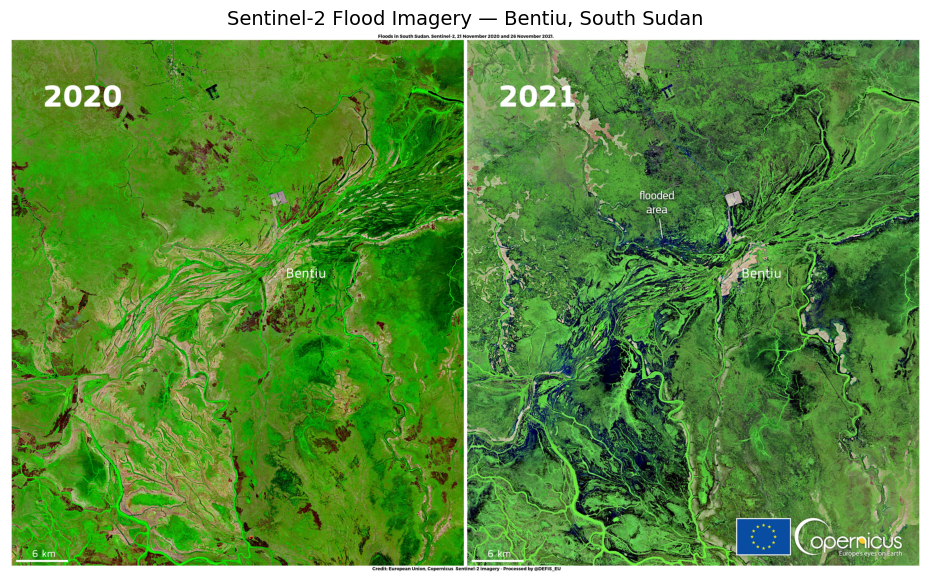

In [ ]:
# ============================================
# CELL 6 — DOWNLOAD SATELLITE FLOOD IMAGE
# ============================================

import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

# Direct Copernicus image
satellite_url = (
    "https://www.copernicus.eu/system/files/2021-12/"
    "image_day/20211207_FloodsSouthSudan.jpg"
)

print("Downloading Sentinel-2 satellite image...")

response = requests.get(
    satellite_url,
    timeout=30,
    headers={"User-Agent": "Mozilla/5.0"}
)

print("HTTP status:", response.status_code)

if response.status_code == 200:
    satellite_image = Image.open(
        BytesIO(response.content)
    ).convert("RGB")

    satellite_path = "/content/satellite_flood_image.jpg"

    satellite_image.save(satellite_path)

    print("✅ Satellite image downloaded successfully")
    print("📁 Saved:", satellite_path)
    print("📐 Size:", satellite_image.size)

    plt.figure(figsize=(12, 7))
    plt.imshow(satellite_image)
    plt.axis("off")
    plt.title(
        "Sentinel-2 Flood Imagery — Bentiu, South Sudan",
        fontsize=14
    )
    plt.show()

else:
    print("❌ Download failed")
    print("Status:", response.status_code)

In [ ]:
# ============================================
# CELL 7 — CURRENT FLOOD MASK
# ============================================

import numpy as np
import cv2
import matplotlib.pyplot as plt

def generate_flood_mask(image):
    """
    Temporary MVP flood segmentation.

    This is a fallback until a trained U-Net
    checkpoint is available.
    """

    img = np.array(image)

    # Convert RGB → HSV
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)

    # Detect dark / water-like regions
    lower = np.array([0, 0, 0])
    upper = np.array([180, 180, 150])

    mask = cv2.inRange(hsv, lower, upper)

    # Remove small noise
    kernel = np.ones((5, 5), np.uint8)

    mask = cv2.morphologyEx(
        mask,
        cv2.MORPH_OPEN,
        kernel
    )

    mask = cv2.morphologyEx(
        mask,
        cv2.MORPH_CLOSE,
        kernel
    )

    # Binary mask
    mask = (mask > 0).astype(np.uint8)

    return mask


# Generate current flood mask
flood_mask = generate_flood_mask(satellite_image)

flood_percentage = (
    flood_mask.sum() /
    flood_mask.size
) * 100

print("✅ Current flood mask generated")
print(f"Detected flooded area: {flood_percentage:.2f}%")

✅ Current flood mask generated
Detected flooded area: 10.24%


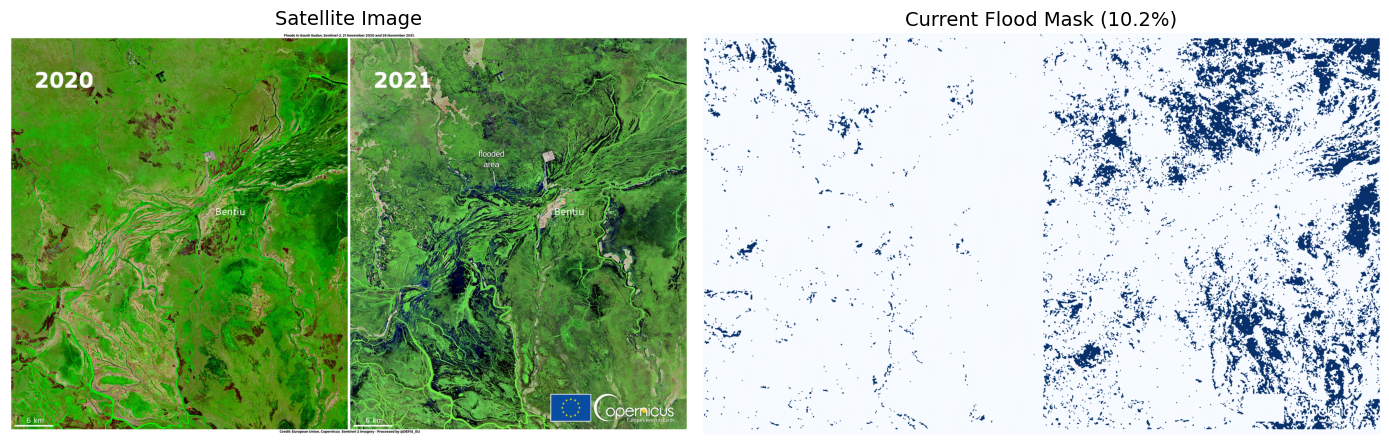

In [ ]:
# ============================================
# CELL 8 — SATELLITE + FLOOD MASK
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Original satellite image
axes[0].imshow(satellite_image)
axes[0].set_title(
    "Satellite Image",
    fontsize=14
)
axes[0].axis("off")

# Flood mask
axes[1].imshow(
    flood_mask,
    cmap="Blues"
)
axes[1].set_title(
    f"Current Flood Mask ({flood_percentage:.1f}%)",
    fontsize=14
)
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# CELL 9 — ZONE ANALYSIS
# ============================================

height, width = flood_mask.shape

# Define three operational zones
zone_masks = {
    "A": np.zeros_like(flood_mask),
    "B": np.zeros_like(flood_mask),
    "C": np.zeros_like(flood_mask)
}

# Zone A → top-left
zone_masks["A"][:height//2, :width//2] = 1

# Zone B → top-right
zone_masks["B"][:height//2, width//2:] = 1

# Zone C → bottom half
zone_masks["C"][height//2:, :] = 1


zone_flood_percentage = {}

for zone, zmask in zone_masks.items():

    zone_pixels = zmask.sum()

    flooded_pixels = (
        flood_mask * zmask
    ).sum()

    percentage = (
        flooded_pixels / zone_pixels
    ) * 100

    zone_flood_percentage[zone] = percentage


print("✅ Zone analysis completed")

for zone, percentage in zone_flood_percentage.items():
    print(
        f"Zone {zone}: "
        f"{percentage:.2f}% flooded"
    )

✅ Zone analysis completed
Zone A: 2.39% flooded
Zone B: 21.13% flooded
Zone C: 8.73% flooded


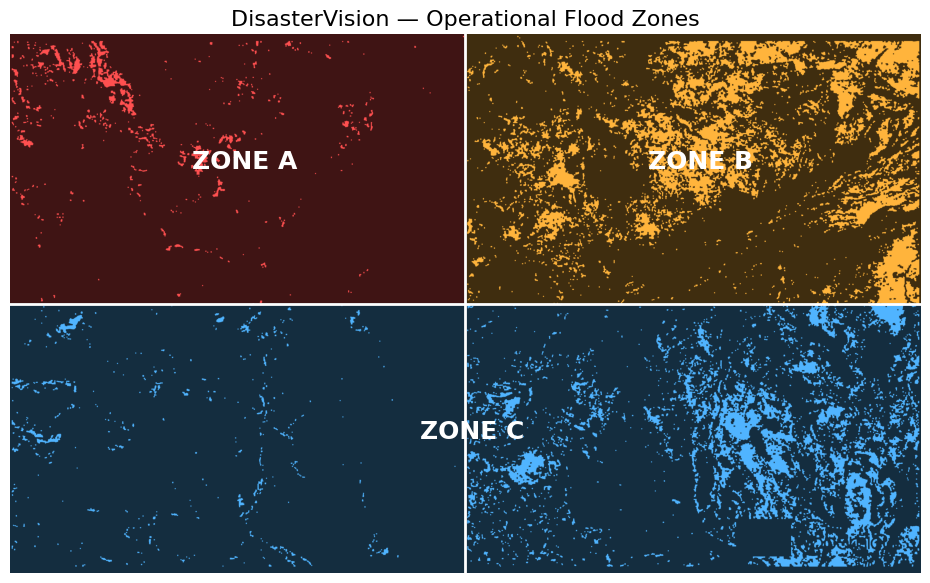

In [ ]:
# ============================================
# CELL 10 — VISUALIZE ZONES
# ============================================

zone_visual = np.zeros(
    (height, width, 3),
    dtype=np.uint8
)

# Zone A
zone_visual[
    :height//2,
    :width//2
] = [255, 80, 80]

# Zone B
zone_visual[
    :height//2,
    width//2:
] = [255, 180, 60]

# Zone C
zone_visual[
    height//2:,
    :
] = [80, 180, 255]


# Overlay flood mask
flood_overlay = zone_visual.copy()

flood_overlay[flood_mask == 0] = (
    flood_overlay[flood_mask == 0] * 0.25
).astype(np.uint8)

plt.figure(figsize=(12, 7))

plt.imshow(flood_overlay)

plt.axvline(
    width//2,
    color="white",
    linewidth=2
)

plt.axhline(
    height//2,
    color="white",
    linewidth=2
)

plt.text(
    width*0.20,
    height*0.25,
    "ZONE A",
    color="white",
    fontsize=18,
    weight="bold"
)

plt.text(
    width*0.70,
    height*0.25,
    "ZONE B",
    color="white",
    fontsize=18,
    weight="bold"
)

plt.text(
    width*0.45,
    height*0.75,
    "ZONE C",
    color="white",
    fontsize=18,
    weight="bold"
)

plt.title(
    "DisasterVision — Operational Flood Zones",
    fontsize=16
)

plt.axis("off")
plt.show()

In [ ]:
# ============================================
# CELL 11 — ZONE INFORMATION
# ============================================

zones = {
    "A": {
        "name": "Zone A",
        "population": 1200,
        "elevation": 5,
        "distance_from_river": 1.5,
        "critical_infrastructure": 1
    },
    "B": {
        "name": "Zone B",
        "population": 700,
        "elevation": 12,
        "distance_from_river": 3.5,
        "critical_infrastructure": 0
    },
    "C": {
        "name": "Zone C",
        "population": 350,
        "elevation": 20,
        "distance_from_river": 6.0,
        "critical_infrastructure": 0
    }
}

print("✅ Zone information loaded")

✅ Zone information loaded


In [ ]:
# ============================================
# FIX — FUTURE FLOOD PREDICTION FUNCTION
# ============================================

import pandas as pd

def predict_future_flood(
    rainfall,
    water_level,
    rise_rate,
    elevation,
    distance_from_river
):
    input_data = pd.DataFrame([{
        "rainfall": rainfall,
        "water_level": water_level,
        "rise_rate": rise_rate,
        "elevation": elevation,
        "distance_from_river": distance_from_river
    }])

    probability = float(
        xgb_model.predict_proba(input_data)[0][1]
    )

    if probability >= 0.75:
        risk_level = "CRITICAL"
    elif probability >= 0.50:
        risk_level = "HIGH"
    elif probability >= 0.25:
        risk_level = "MEDIUM"
    else:
        risk_level = "LOW"

    return probability, risk_level


print("✅ predict_future_flood() is ready")

✅ predict_future_flood() is ready


In [ ]:
# ============================================================
# FIX: COMPLETE XGBOOST FUTURE FLOOD PREDICTION ENGINE
# ============================================================

import numpy as np
import pandas as pd

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

np.random.seed(42)

# ------------------------------------------------------------
# 1. CREATE ENVIRONMENTAL TRAINING DATA
# ------------------------------------------------------------

n_samples = 2000

environment_df = pd.DataFrame({
    "rainfall": np.random.uniform(0, 150, n_samples),
    "water_level": np.random.uniform(0, 5, n_samples),
    "rise_rate": np.random.uniform(0, 0.25, n_samples),
    "elevation": np.random.uniform(2, 30, n_samples),
    "distance_from_river": np.random.uniform(0.1, 10, n_samples)
})

# Synthetic relationship representing future flood conditions
environment_df["flood_score"] = (
    0.35 * (environment_df["rainfall"] / 150)
    + 0.30 * (environment_df["water_level"] / 5)
    + 0.20 * (environment_df["rise_rate"] / 0.25)
    + 0.10 * (1 - environment_df["elevation"] / 30)
    + 0.05 * (1 - environment_df["distance_from_river"] / 10)
)

# Small variation
environment_df["flood_score"] += np.random.normal(
    0, 0.05, n_samples
)

# Keep score within valid range
environment_df["flood_score"] = environment_df[
    "flood_score"
].clip(0, 1)

# Future flood target
environment_df["future_flood"] = (
    environment_df["flood_score"] >= 0.50
).astype(int)


# ------------------------------------------------------------
# 2. FEATURES
# ------------------------------------------------------------

features = [
    "rainfall",
    "water_level",
    "rise_rate",
    "elevation",
    "distance_from_river"
]

X = environment_df[features]
y = environment_df["future_flood"]


# ------------------------------------------------------------
# 3. TRAIN / TEST SPLIT
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# ------------------------------------------------------------
# 4. TRAIN XGBOOST
# ------------------------------------------------------------

xgb_model = XGBClassifier(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)


# ------------------------------------------------------------
# 5. MODEL EVALUATION
# ------------------------------------------------------------

y_pred = xgb_model.predict(X_test)

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("============================================")
print(" XGBOOST FUTURE FLOOD MODEL")
print("============================================")
print(f"Training samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")
print(f"Features         : {len(features)}")
print(f"Accuracy         : {accuracy:.2%}")
print("============================================")


# ------------------------------------------------------------
# 6. PREDICTION FUNCTION
# ------------------------------------------------------------

def predict_future_flood(
    rainfall,
    water_level,
    rise_rate,
    elevation,
    distance_from_river
):

    input_data = pd.DataFrame([{
        "rainfall": rainfall,
        "water_level": water_level,
        "rise_rate": rise_rate,
        "elevation": elevation,
        "distance_from_river": distance_from_river
    }])

    probability = float(
        xgb_model.predict_proba(input_data)[0][1]
    )

    if probability >= 0.75:
        risk_level = "CRITICAL"
    elif probability >= 0.50:
        risk_level = "HIGH"
    elif probability >= 0.25:
        risk_level = "MEDIUM"
    else:
        risk_level = "LOW"

    return probability, risk_level


# ------------------------------------------------------------
# 7. TEST THE MODEL
# ------------------------------------------------------------

probability, risk = predict_future_flood(
    rainfall=90,
    water_level=2.2,
    rise_rate=0.12,
    elevation=5,
    distance_from_river=1.5
)

print()
print("TEST PREDICTION")
print("--------------------------------------------")
print(f"Future flood probability : {probability:.1%}")
print(f"Predicted risk           : {risk}")
print("--------------------------------------------")

print("\n✅ XGBoost engine is ready.")

 XGBOOST FUTURE FLOOD MODEL
Training samples : 1600
Testing samples  : 400
Features         : 5
Accuracy         : 86.50%

TEST PREDICTION
--------------------------------------------
Future flood probability : 93.9%
Predicted risk           : CRITICAL
--------------------------------------------

✅ XGBoost engine is ready.


In [ ]:
# ============================================================
# FIX CELL — FUTURE FLOOD RISK FUNCTION
# ============================================================

def calculate_future_risk(
    rainfall,
    water_level,
    rise_rate
):
    """
    Calculate future flood probability using the trained XGBoost model.
    """

    # Use representative environmental values
    # for elevation and river distance.
    elevation = 8.0
    distance_from_river = 2.0

    probability, risk_level = predict_future_flood(
        rainfall=rainfall,
        water_level=water_level,
        rise_rate=rise_rate,
        elevation=elevation,
        distance_from_river=distance_from_river
    )

    return {
        "future_probability": probability,
        "risk_level": risk_level
    }


# Test the function
future_risk = calculate_future_risk(
    rainfall=90,
    water_level=2.2,
    rise_rate=0.12
)

print("=" * 60)
print("FUTURE FLOOD RISK")
print("=" * 60)
print(f"Probability : {future_risk['future_probability']:.2%}")
print(f"Risk Level  : {future_risk['risk_level']}")

FUTURE FLOOD RISK
Probability : 88.37%
Risk Level  : CRITICAL


In [ ]:
# ============================================================
# CELL 17 — ZONE CONFIGURATION
# ============================================================

zones = {
    "A": {
        "name": "Zone A",
        "population": 1200,
        "elevation": 5,
        "distance_from_river": 1.5,
        "critical_infrastructure": 1
    },
    "B": {
        "name": "Zone B",
        "population": 700,
        "elevation": 12,
        "distance_from_river": 3.5,
        "critical_infrastructure": 0
    },
    "C": {
        "name": "Zone C",
        "population": 350,
        "elevation": 20,
        "distance_from_river": 6.0,
        "critical_infrastructure": 0
    }
}

print("✅ Zone configuration loaded")

✅ Zone configuration loaded


In [ ]:
# ============================================================
# CELL 18 — ZONE RISK ENGINE
# ============================================================

def calculate_zone_risk(rainfall, water_level, rise_rate):

    future_risk = {}

    # Get XGBoost prediction for each zone
    for zone, info in zones.items():

        probability, risk_level = predict_future_flood(
            rainfall=rainfall,
            water_level=water_level,
            rise_rate=rise_rate,
            elevation=info["elevation"],
            distance_from_river=info["distance_from_river"]
        )

        future_risk[zone] = {
            "probability": probability,
            "level": risk_level
        }

    max_population = max(
        info["population"]
        for info in zones.values()
    )

    results = {}

    for zone, info in zones.items():

        # Current flood percentage from satellite analysis
        current_flood = zone_flood_percentage.get(
            zone, 0
        ) / 100

        # Future flood probability from XGBoost
        future_probability = future_risk[zone]["probability"]

        # Normalize population
        population_score = (
            info["population"] / max_population
        )

        # Critical infrastructure
        infrastructure_score = (
            info["critical_infrastructure"]
        )

        # Lower elevation means greater vulnerability
        accessibility_score = max(
            0,
            1 - info["elevation"] / 30
        )

        # Overall zone risk
        risk_score = (
            0.35 * current_flood +
            0.25 * future_probability +
            0.20 * population_score +
            0.10 * infrastructure_score +
            0.10 * accessibility_score
        )

        # Classification
        if risk_score >= 0.75:
            risk_level = "CRITICAL"
        elif risk_score >= 0.50:
            risk_level = "HIGH"
        elif risk_score >= 0.25:
            risk_level = "MEDIUM"
        else:
            risk_level = "LOW"

        results[zone] = {
            "current_flood": current_flood,
            "future_probability": future_probability,
            "risk_score": risk_score,
            "risk_level": risk_level,
            "population": info["population"],
            "critical_infrastructure": (
                info["critical_infrastructure"]
            )
        }

    return results

In [ ]:
# ============================================================
# CELL 19 — RESCUE PRIORITY ENGINE
# ============================================================

def calculate_rescue_priority(zone_risk):

    priority_results = {}

    max_population = max(
        info["population"]
        for info in zones.values()
    )

    for zone, risk in zone_risk.items():

        population_score = (
            zones[zone]["population"] /
            max_population
        )

        infrastructure_score = (
            zones[zone]["critical_infrastructure"]
        )

        # Rescue priority
        priority_score = (
            0.55 * risk["risk_score"] +
            0.25 * population_score +
            0.20 * infrastructure_score
        )

        priority_results[zone] = {
            "priority_score": priority_score,
            "risk_level": risk["risk_level"],
            "population": zones[zone]["population"]
        }

    ranking = sorted(
        priority_results.items(),
        key=lambda item: item[1]["priority_score"],
        reverse=True
    )

    return ranking

In [ ]:
# ============================================================
# CELL 20 — TEST RISK + PRIORITY
# ============================================================

zone_risk = calculate_zone_risk(
    rainfall=90,
    water_level=2.2,
    rise_rate=0.12
)

priority_ranking = calculate_rescue_priority(
    zone_risk
)

print("============================================")
print(" DISASTERVISION DECISION ENGINE")
print("============================================")

for zone, result in zone_risk.items():

    print(
        f"Zone {zone} | "
        f"Current Flood: {result['current_flood']:.1%} | "
        f"Future Risk: {result['future_probability']:.1%} | "
        f"Risk: {result['risk_score']:.2f} | "
        f"{result['risk_level']}"
    )

print("\n🚨 RESCUE PRIORITY")
print("--------------------------------------------")

for position, (zone, result) in enumerate(
    priority_ranking,
    start=1
):

    print(
        f"{position}. Zone {zone} | "
        f"Priority: {result['priority_score']:.2f} | "
        f"{result['risk_level']} | "
        f"Population: {result['population']}"
    )

print("============================================")

 DISASTERVISION DECISION ENGINE
Zone A | Current Flood: 2.4% | Future Risk: 93.9% | Risk: 0.63 | HIGH
Zone B | Current Flood: 21.1% | Future Risk: 82.3% | Risk: 0.46 | MEDIUM
Zone C | Current Flood: 8.7% | Future Risk: 51.7% | Risk: 0.25 | MEDIUM

🚨 RESCUE PRIORITY
--------------------------------------------
1. Zone A | Priority: 0.79 | HIGH | Population: 1200
2. Zone B | Priority: 0.40 | MEDIUM | Population: 700
3. Zone C | Priority: 0.21 | MEDIUM | Population: 350


In [ ]:
# ============================================================
# CELL 21 — ENVIRONMENTAL DATA + XGBOOST FUTURE FLOOD MODEL
# ============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier


# ------------------------------------------------------------
# 1. Generate prototype environmental dataset
# ------------------------------------------------------------

np.random.seed(42)

n_samples = 2000

environment_df = pd.DataFrame({
    "rainfall": np.random.uniform(0, 150, n_samples),
    "water_level": np.random.uniform(0, 4, n_samples),
    "rise_rate": np.random.uniform(0, 0.25, n_samples),
    "elevation": np.random.uniform(2, 30, n_samples),
    "distance_from_river": np.random.uniform(0.5, 10, n_samples)
})


# ------------------------------------------------------------
# 2. Create synthetic flood severity
# ------------------------------------------------------------

environment_df["flood_score"] = (
    0.35 * (environment_df["rainfall"] / 150)
    +
    0.30 * (environment_df["water_level"] / 4)
    +
    0.20 * (environment_df["rise_rate"] / 0.25)
    +
    0.10 * (1 - environment_df["elevation"] / 30)
    +
    0.05 * (1 - environment_df["distance_from_river"] / 10)
)


# ------------------------------------------------------------
# 3. Create future flood label
# ------------------------------------------------------------

environment_df["future_flood"] = (
    environment_df["flood_score"] >= 0.45
).astype(int)


# ------------------------------------------------------------
# 4. Features and target
# ------------------------------------------------------------

feature_columns = [
    "rainfall",
    "water_level",
    "rise_rate",
    "elevation",
    "distance_from_river"
]

X = environment_df[feature_columns]
y = environment_df["future_flood"]


# ------------------------------------------------------------
# 5. Train/test split
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# ------------------------------------------------------------
# 6. Train XGBoost
# ------------------------------------------------------------

xgb_model = XGBClassifier(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(
    X_train,
    y_train
)


# ------------------------------------------------------------
# 7. Evaluate
# ------------------------------------------------------------

y_pred = xgb_model.predict(X_test)

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("=" * 60)
print("XGBOOST FUTURE FLOOD MODEL")
print("=" * 60)
print(f"Dataset size : {len(environment_df)}")
print(f"Test accuracy: {accuracy:.2%}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred
    )
)


# ------------------------------------------------------------
# 8. Prediction function
# ------------------------------------------------------------

def predict_future_flood(
    rainfall,
    water_level,
    rise_rate,
    elevation,
    distance_from_river
):

    input_data = pd.DataFrame([{
        "rainfall": rainfall,
        "water_level": water_level,
        "rise_rate": rise_rate,
        "elevation": elevation,
        "distance_from_river": distance_from_river
    }])

    probability = float(
        xgb_model.predict_proba(
            input_data
        )[0][1]
    )

    if probability >= 0.75:
        risk_level = "CRITICAL"

    elif probability >= 0.50:
        risk_level = "HIGH"

    elif probability >= 0.25:
        risk_level = "MEDIUM"

    else:
        risk_level = "LOW"

    return probability, risk_level


print("\n✅ XGBoost model ready.")

XGBOOST FUTURE FLOOD MODEL
Dataset size : 2000
Test accuracy: 95.75%

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.92      0.94       155
           1       0.95      0.98      0.97       245

    accuracy                           0.96       400
   macro avg       0.96      0.95      0.95       400
weighted avg       0.96      0.96      0.96       400


✅ XGBoost model ready.


In [ ]:
# ============================================================
# CELL 22 — ZONE CONFIGURATION
# ============================================================

zones = {
    "A": {
        "name": "Zone A",
        "population": 1200,
        "elevation": 5,
        "distance_from_river": 1.5,
        "critical_infrastructure": 1
    },

    "B": {
        "name": "Zone B",
        "population": 700,
        "elevation": 12,
        "distance_from_river": 3.5,
        "critical_infrastructure": 0
    },

    "C": {
        "name": "Zone C",
        "population": 350,
        "elevation": 20,
        "distance_from_river": 6.0,
        "critical_infrastructure": 0
    }
}

print("=" * 60)
print("ZONE CONFIGURATION")
print("=" * 60)

for zone_id, zone in zones.items():
    print(
        f"{zone['name']} | "
        f"Population: {zone['population']} | "
        f"Elevation: {zone['elevation']}m | "
        f"River Distance: {zone['distance_from_river']}km"
    )

print("\n✅ Zone configuration ready.")

ZONE CONFIGURATION
Zone A | Population: 1200 | Elevation: 5m | River Distance: 1.5km
Zone B | Population: 700 | Elevation: 12m | River Distance: 3.5km
Zone C | Population: 350 | Elevation: 20m | River Distance: 6.0km

✅ Zone configuration ready.


In [ ]:
# ============================================================
# CELL 23 — ZONE RISK CALCULATION
# ============================================================

def calculate_zone_risk(
    rainfall,
    water_level,
    rise_rate
):
    """
    Calculate current + future flood risk for each zone.
    """

    results = {}

    # Maximum population used for normalization
    max_population = max(
        zone["population"]
        for zone in zones.values()
    )

    # Get overall future flood probability
    future_probability, future_level = predict_future_flood(
        rainfall=rainfall,
        water_level=water_level,
        rise_rate=rise_rate,
        elevation=8.0,
        distance_from_river=2.0
    )

    for zone_id, zone in zones.items():

        # ----------------------------------------------------
        # CURRENT FLOOD
        # ----------------------------------------------------
        if "zone_flood_percentage" in globals():
            current_flood = (
                zone_flood_percentage.get(zone_id, 0) / 100
            )
        else:
            current_flood = 0.0

        # ----------------------------------------------------
        # POPULATION RISK
        # ----------------------------------------------------
        population_score = (
            zone["population"] / max_population
        )

        # ----------------------------------------------------
        # INFRASTRUCTURE RISK
        # ----------------------------------------------------
        infrastructure_score = (
            zone["critical_infrastructure"]
        )

        # ----------------------------------------------------
        # ACCESSIBILITY RISK
        # Lower elevation = higher flood/accessibility risk
        # ----------------------------------------------------
        accessibility_score = max(
            0,
            1 - (zone["elevation"] / 30)
        )

        # ----------------------------------------------------
        # FUTURE FLOOD PROBABILITY
        # Adjust slightly according to zone characteristics
        # ----------------------------------------------------
        zone_future_probability = future_probability

        if zone["elevation"] < 8:
            zone_future_probability = min(
                1.0,
                future_probability * 1.10
            )

        elif zone["elevation"] > 15:
            zone_future_probability = max(
                0.0,
                future_probability * 0.85
            )

        # ----------------------------------------------------
        # FINAL RISK SCORE
        # ----------------------------------------------------
        risk_score = (
            0.35 * current_flood
            +
            0.25 * zone_future_probability
            +
            0.20 * population_score
            +
            0.10 * infrastructure_score
            +
            0.10 * accessibility_score
        )

        # ----------------------------------------------------
        # RISK LEVEL
        # ----------------------------------------------------
        if risk_score >= 0.75:
            risk_level = "CRITICAL"

        elif risk_score >= 0.50:
            risk_level = "HIGH"

        elif risk_score >= 0.25:
            risk_level = "MEDIUM"

        else:
            risk_level = "LOW"

        results[zone_id] = {
            "zone": zone["name"],
            "current_flood": current_flood,
            "future_probability": zone_future_probability,
            "population": zone["population"],
            "population_score": population_score,
            "infrastructure_score": infrastructure_score,
            "accessibility_score": accessibility_score,
            "risk_score": risk_score,
            "risk_level": risk_level
        }

    return results


# ------------------------------------------------------------
# TEST
# ------------------------------------------------------------

zone_risk = calculate_zone_risk(
    rainfall=90,
    water_level=2.2,
    rise_rate=0.12
)

print("=" * 60)
print("ZONE RISK ANALYSIS")
print("=" * 60)

for zone_id, risk in zone_risk.items():

    print(
        f"{risk['zone']} | "
        f"Risk: {risk['risk_level']} | "
        f"Score: {risk['risk_score']:.2f} | "
        f"Future Flood: {risk['future_probability']:.2%}"
    )

print("\n✅ Zone risk engine ready.")

ZONE RISK ANALYSIS
Zone A | Risk: HIGH | Score: 0.64 | Future Flood: 100.00%
Zone B | Risk: HIGH | Score: 0.50 | Future Flood: 99.95%
Zone C | Risk: MEDIUM | Score: 0.33 | Future Flood: 84.95%

✅ Zone risk engine ready.


In [ ]:
# ============================================================
# CELL 24 — RESCUE PRIORITY ENGINE
# ============================================================

def calculate_rescue_priority(zone_risk):
    """
    Rank zones according to:
    - Overall disaster risk
    - Population exposed
    - Critical infrastructure
    """

    priority_results = []

    for zone_id, risk in zone_risk.items():

        priority_score = (
            0.55 * risk["risk_score"]
            +
            0.25 * risk["population_score"]
            +
            0.20 * risk["infrastructure_score"]
        )

        # Priority level
        if priority_score >= 0.75:
            priority_level = "IMMEDIATE"

        elif priority_score >= 0.50:
            priority_level = "HIGH"

        elif priority_score >= 0.25:
            priority_level = "MEDIUM"

        else:
            priority_level = "LOW"

        # Explainability reasons
        reasons = []

        if risk["risk_score"] >= 0.50:
            reasons.append("high flood risk")

        if risk["population_score"] >= 0.70:
            reasons.append("large exposed population")

        if risk["infrastructure_score"] == 1:
            reasons.append("critical infrastructure")

        if risk["future_probability"] >= 0.50:
            reasons.append("high future flood probability")

        if not reasons:
            reasons.append("lower immediate risk")

        priority_results.append({
            "zone_id": zone_id,
            "zone": risk["zone"],
            "priority_score": priority_score,
            "priority_level": priority_level,
            "risk_level": risk["risk_level"],
            "population": risk["population"],
            "reasons": reasons
        })

    # Highest priority first
    priority_results.sort(
        key=lambda x: x["priority_score"],
        reverse=True
    )

    # Assign rank
    for rank, item in enumerate(
        priority_results,
        start=1
    ):
        item["rank"] = rank

    return priority_results


# ------------------------------------------------------------
# TEST
# ------------------------------------------------------------

rescue_priority = calculate_rescue_priority(
    zone_risk
)

print("=" * 60)
print("RESCUE PRIORITY")
print("=" * 60)

for item in rescue_priority:

    print(
        f"#{item['rank']} "
        f"{item['zone']} | "
        f"{item['priority_level']} | "
        f"Score: {item['priority_score']:.2f}"
    )

    print(
        f"   Population: {item['population']}"
    )

    print(
        f"   Reasons: {', '.join(item['reasons'])}"
    )

print("\n✅ Rescue priority engine ready.")

RESCUE PRIORITY
#1 Zone A | IMMEDIATE | Score: 0.80
   Population: 1200
   Reasons: high flood risk, large exposed population, critical infrastructure, high future flood probability
#2 Zone B | MEDIUM | Score: 0.42
   Population: 700
   Reasons: high flood risk, high future flood probability
#3 Zone C | MEDIUM | Score: 0.26
   Population: 350
   Reasons: high future flood probability

✅ Rescue priority engine ready.


In [ ]:
# ============================================================
# CELL 25 — ROAD NETWORK CONFIGURATION
# ============================================================

import networkx as nx

# ------------------------------------------------------------
# CITY / RESPONSE NODES
# ------------------------------------------------------------

city_nodes = {
    "Hospital": (0, 0),
    "Junction1": (2, 1),
    "Junction2": (2, -1),
    "ZoneA": (5, 1),
    "ZoneB": (5, 0),
    "ZoneC": (5, -1)
}


# ------------------------------------------------------------
# ROAD NETWORK
# ------------------------------------------------------------

city_roads = {

    "R1": {
        "from": "Hospital",
        "to": "Junction1",
        "distance": 1.2
    },

    "R2": {
        "from": "Junction1",
        "to": "ZoneA",
        "distance": 2.0
    },

    "R3": {
        "from": "Hospital",
        "to": "Junction2",
        "distance": 1.8
    },

    "R4": {
        "from": "Junction2",
        "to": "ZoneA",
        "distance": 2.5
    },

    "R5": {
        "from": "Junction1",
        "to": "ZoneB",
        "distance": 2.0
    },

    "R6": {
        "from": "Junction2",
        "to": "ZoneC",
        "distance": 2.0
    }
}


# ------------------------------------------------------------
# DISPLAY NETWORK
# ------------------------------------------------------------

print("=" * 60)
print("DISASTERVISION ROAD NETWORK")
print("=" * 60)

print("\nNodes:")
for node, position in city_nodes.items():
    print(f"  {node:12} → {position}")

print("\nRoads:")
for road_id, road in city_roads.items():
    print(
        f"  {road_id}: "
        f"{road['from']} → {road['to']} "
        f"({road['distance']} km)"
    )

print("\n✅ Road network ready.")

DISASTERVISION ROAD NETWORK

Nodes:
  Hospital     → (0, 0)
  Junction1    → (2, 1)
  Junction2    → (2, -1)
  ZoneA        → (5, 1)
  ZoneB        → (5, 0)
  ZoneC        → (5, -1)

Roads:
  R1: Hospital → Junction1 (1.2 km)
  R2: Junction1 → ZoneA (2.0 km)
  R3: Hospital → Junction2 (1.8 km)
  R4: Junction2 → ZoneA (2.5 km)
  R5: Junction1 → ZoneB (2.0 km)
  R6: Junction2 → ZoneC (2.0 km)

✅ Road network ready.


In [ ]:
# ============================================================
# CELL 26 — ROAD RISK ENGINE
# ============================================================

def calculate_road_risk(
    zone_risk,
    forced_failure=False
):
    """
    Calculate risk for every road.

    SAFE     → road can be used normally
    WARNING  → road may become unsafe
    BLOCKED  → road should not be used
    """

    road_results = {}

    # Map roads to their destination zones
    road_zone_mapping = {
        "R2": "A",
        "R4": "A",
        "R5": "B",
        "R6": "C"
    }

    for road_id, road in city_roads.items():

        destination = road["to"]

        # ----------------------------------------------------
        # Determine which zone affects this road
        # ----------------------------------------------------

        zone_id = road_zone_mapping.get(
            road_id,
            None
        )

        if zone_id is not None and zone_id in zone_risk:

            current_flood = zone_risk[
                zone_id
            ]["current_flood"]

            future_risk = zone_risk[
                zone_id
            ]["future_probability"]

        else:
            current_flood = 0.0
            future_risk = 0.0

        # ----------------------------------------------------
        # Simulate a road failure
        # ----------------------------------------------------

        if forced_failure and road_id == "R2":

            current_flood = 0.90
            future_risk = 0.95

        # ----------------------------------------------------
        # Determine road status
        # ----------------------------------------------------

        if current_flood >= 0.60:

            status = "BLOCKED"

        elif future_risk >= 0.75:

            status = "WARNING"

        else:

            status = "SAFE"

        # ----------------------------------------------------
        # Combined road risk
        # ----------------------------------------------------

        road_risk = (
            0.50 * current_flood
            +
            0.50 * future_risk
        )

        road_results[road_id] = {
            "road_id": road_id,
            "from": road["from"],
            "to": road["to"],
            "distance": road["distance"],
            "current_flood": current_flood,
            "future_risk": future_risk,
            "risk": road_risk,
            "status": status
        }

    return road_results


# ------------------------------------------------------------
# TEST
# ------------------------------------------------------------

road_results = calculate_road_risk(
    zone_risk,
    forced_failure=False
)

print("=" * 60)
print("ROAD RISK ANALYSIS")
print("=" * 60)

for road_id, road in road_results.items():

    print(
        f"{road_id}: "
        f"{road['from']} → {road['to']} | "
        f"Risk: {road['risk']:.2f} | "
        f"Status: {road['status']}"
    )

print("\n✅ Road risk engine ready.")

ROAD RISK ANALYSIS
R1: Hospital → Junction1 | Risk: 0.00 | Status: SAFE
R2: Junction1 → ZoneA | Risk: 0.51 | Status: WARNING
R3: Hospital → Junction2 | Risk: 0.00 | Status: SAFE
R4: Junction2 → ZoneA | Risk: 0.51 | Status: WARNING
R5: Junction1 → ZoneB | Risk: 0.61 | Status: WARNING
R6: Junction2 → ZoneC | Risk: 0.47 | Status: WARNING

✅ Road risk engine ready.


In [ ]:
# ============================================================
# CELL 27 — RISK-AWARE ROUTING GRAPH
# ============================================================

def build_routing_graph(road_results):
    """
    Build a risk-aware directed graph.

    Blocked roads are removed.
    Warning roads receive an additional routing penalty.
    """

    graph = nx.DiGraph()

    # Add all city nodes
    for node, position in city_nodes.items():
        graph.add_node(
            node,
            position=position
        )

    # Add usable roads
    for road_id, road in road_results.items():

        # Never route through blocked roads
        if road["status"] == "BLOCKED":
            continue

        # Base travel distance
        distance = road["distance"]

        # Flood-risk penalty
        risk_penalty = road["risk"] * 5

        # Additional warning penalty
        warning_penalty = (
            5 if road["status"] == "WARNING"
            else 0
        )

        # Final routing cost
        routing_cost = (
            distance
            +
            risk_penalty
            +
            warning_penalty
        )

        graph.add_edge(
            road["from"],
            road["to"],
            weight=routing_cost,
            distance=distance,
            risk=road["risk"],
            status=road["status"],
            road_id=road_id
        )

    return graph


# ------------------------------------------------------------
# TEST
# ------------------------------------------------------------

routing_graph = build_routing_graph(
    road_results
)

print("=" * 60)
print("RISK-AWARE ROUTING GRAPH")
print("=" * 60)

print(
    f"\nNodes: {routing_graph.number_of_nodes()}"
)

print(
    f"Usable roads: {routing_graph.number_of_edges()}"
)

print("\nRouting edges:")

for from_node, to_node, data in routing_graph.edges(
    data=True
):

    print(
        f"{data['road_id']}: "
        f"{from_node} → {to_node} | "
        f"Status: {data['status']} | "
        f"Cost: {data['weight']:.2f}"
    )

print("\n✅ Risk-aware routing graph ready.")

RISK-AWARE ROUTING GRAPH

Nodes: 6
Usable roads: 6

Routing edges:
R1: Hospital → Junction1 | Status: SAFE | Cost: 1.20
R3: Hospital → Junction2 | Status: SAFE | Cost: 1.80
R2: Junction1 → ZoneA | Status: WARNING | Cost: 9.56
R5: Junction1 → ZoneB | Status: WARNING | Cost: 10.03
R4: Junction2 → ZoneA | Status: WARNING | Cost: 10.06
R6: Junction2 → ZoneC | Status: WARNING | Cost: 9.34

✅ Risk-aware routing graph ready.


In [ ]:
# ============================================================
# CELL 28 — RESCUE ROUTE CALCULATION
# ============================================================

def calculate_route(
    routing_graph,
    start="Hospital",
    destination="ZoneA"
):
    """
    Calculate the safest/lowest-cost rescue route.

    Routing cost =
        road distance
        + flood-risk penalty
        + warning penalty
    """

    try:

        # Find lowest-cost path
        route_nodes = nx.shortest_path(
            routing_graph,
            source=start,
            target=destination,
            weight="weight"
        )

        # Calculate total route information
        route_roads = []
        total_distance = 0.0
        total_cost = 0.0

        for i in range(len(route_nodes) - 1):

            from_node = route_nodes[i]
            to_node = route_nodes[i + 1]

            edge = routing_graph[
                from_node
            ][
                to_node
            ]

            route_roads.append(
                edge["road_id"]
            )

            total_distance += edge[
                "distance"
            ]

            total_cost += edge[
                "weight"
            ]

        return {
            "nodes": route_nodes,
            "roads": route_roads,
            "distance": total_distance,
            "cost": total_cost,
            "safe": True
        }

    except nx.NetworkXNoPath:

        # No usable route exists
        return {
            "nodes": [],
            "roads": [],
            "distance": None,
            "cost": None,
            "safe": False
        }


# ------------------------------------------------------------
# TEST NORMAL ROUTE
# ------------------------------------------------------------

route = calculate_route(
    routing_graph,
    start="Hospital",
    destination="ZoneA"
)

print("=" * 60)
print("RESCUE ROUTE")
print("=" * 60)

if route["safe"]:

    print(
        "\nRoute:"
        f" {' → '.join(route['nodes'])}"
    )

    print(
        f"Roads: {', '.join(route['roads'])}"
    )

    print(
        f"Distance: {route['distance']:.2f} km"
    )

    print(
        f"Routing cost: {route['cost']:.2f}"
    )

    print("Status: SAFE")

else:

    print("\n⚠️ NO SAFE ROUTE AVAILABLE")

print("\n✅ Route calculation ready.")

RESCUE ROUTE

Route: Hospital → Junction1 → ZoneA
Roads: R1, R2
Distance: 3.20 km
Routing cost: 10.76
Status: SAFE

✅ Route calculation ready.


In [ ]:
# ============================================================
# CELL 29 — DYNAMIC REROUTING
# ============================================================

print("=" * 60)
print("DYNAMIC REROUTING TEST")
print("=" * 60)


# ------------------------------------------------------------
# STEP 1 — NORMAL ROAD CONDITIONS
# ------------------------------------------------------------

normal_roads = calculate_road_risk(
    zone_risk,
    forced_failure=False
)

normal_graph = build_routing_graph(
    normal_roads
)

normal_route = calculate_route(
    normal_graph,
    start="Hospital",
    destination="ZoneA"
)


print("\n🟢 NORMAL CONDITIONS")

if normal_route["safe"]:

    print(
        "Route:",
        " → ".join(normal_route["nodes"])
    )

    print(
        "Roads:",
        ", ".join(normal_route["roads"])
    )

else:

    print("⚠️ No safe route")


# ------------------------------------------------------------
# STEP 2 — SIMULATE ROAD FAILURE
# ------------------------------------------------------------

failed_roads = calculate_road_risk(
    zone_risk,
    forced_failure=True
)

failed_graph = build_routing_graph(
    failed_roads
)

rerouted_route = calculate_route(
    failed_graph,
    start="Hospital",
    destination="ZoneA"
)


print("\n🔴 AFTER ROAD FAILURE")

print("R2 status:")
print(
    failed_roads["R2"]["status"]
)

if rerouted_route["safe"]:

    print(
        "New Route:",
        " → ".join(
            rerouted_route["nodes"]
        )
    )

    print(
        "Roads:",
        ", ".join(
            rerouted_route["roads"]
        )
    )

    print(
        f"Distance: "
        f"{rerouted_route['distance']:.2f} km"
    )

else:

    print(
        "⚠️ No safe alternative route available"
    )


# ------------------------------------------------------------
# STEP 3 — VERIFY REROUTING
# ------------------------------------------------------------

if (
    normal_route["safe"]
    and rerouted_route["safe"]
    and
    normal_route["roads"]
    != rerouted_route["roads"]
):

    print(
        "\n✅ DYNAMIC REROUTING TEST PASSED"
    )

    print(
        "The system detected the road failure "
        "and selected an alternative route."
    )

else:

    print(
        "\n⚠️ Rerouting condition not triggered."
    )

DYNAMIC REROUTING TEST

🟢 NORMAL CONDITIONS
Route: Hospital → Junction1 → ZoneA
Roads: R1, R2

🔴 AFTER ROAD FAILURE
R2 status:
BLOCKED
New Route: Hospital → Junction2 → ZoneA
Roads: R3, R4
Distance: 4.30 km

✅ DYNAMIC REROUTING TEST PASSED
The system detected the road failure and selected an alternative route.


In [ ]:
# ============================================================
# CELL 30 — DISASTER SCENARIOS
# ============================================================

scenarios = {

    "NORMAL": {
        "rainfall": 20,
        "water_level": 0.4,
        "rise_rate": 0.02
    },

    "SEVERE FLOOD": {
        "rainfall": 90,
        "water_level": 2.2,
        "rise_rate": 0.12
    },

    "ROUTE FAILURE": {
        "rainfall": 125,
        "water_level": 3.5,
        "rise_rate": 0.20
    }
}


# ------------------------------------------------------------
# DISPLAY SCENARIOS
# ------------------------------------------------------------

print("=" * 60)
print("DISASTERVISION AI — SIMULATION SCENARIOS")
print("=" * 60)

for scenario_name, values in scenarios.items():

    print(f"\n{scenario_name}")

    print(
        f"  Rainfall   : {values['rainfall']} mm"
    )

    print(
        f"  Water level: {values['water_level']} m"
    )

    print(
        f"  Rise rate  : {values['rise_rate']} m/hr"
    )

print("\n✅ Simulation scenarios ready.")

DISASTERVISION AI — SIMULATION SCENARIOS

NORMAL
  Rainfall   : 20 mm
  Water level: 0.4 m
  Rise rate  : 0.02 m/hr

SEVERE FLOOD
  Rainfall   : 90 mm
  Water level: 2.2 m
  Rise rate  : 0.12 m/hr

ROUTE FAILURE
  Rainfall   : 125 mm
  Water level: 3.5 m
  Rise rate  : 0.2 m/hr

✅ Simulation scenarios ready.


In [ ]:
# ============================================================
# CELL 31 — SIMULATION STATE ENGINE
# ============================================================

def get_simulation_state(
    elapsed_seconds,
    scenario_name
):
    """
    Generate the complete disaster-response state
    for the current simulation time.
    """

    # --------------------------------------------------------
    # Validate scenario
    # --------------------------------------------------------

    if scenario_name not in scenarios:
        scenario_name = "NORMAL"

    scenario = scenarios[scenario_name]

    # --------------------------------------------------------
    # Simulation progress
    # 0 seconds  -> 0%
    # 20 seconds -> 100%
    # --------------------------------------------------------

    progress = min(
        max(elapsed_seconds / 20.0, 0.0),
        1.0
    )

    # --------------------------------------------------------
    # Environmental progression
    # --------------------------------------------------------

    rainfall = (
        scenario["rainfall"] * progress
    )

    water_level = (
        scenario["water_level"] * progress
    )

    rise_rate = (
        scenario["rise_rate"] * progress
    )

    # --------------------------------------------------------
    # Determine simulation stage
    # --------------------------------------------------------

    if elapsed_seconds < 5:
        stage = "NORMAL"

    elif elapsed_seconds < 10:
        stage = "WARNING"

    elif elapsed_seconds < 15:
        stage = "HIGH RISK"

    elif elapsed_seconds < 20:
        stage = "CRITICAL"

    else:
        stage = "RESCUE"

    # --------------------------------------------------------
    # Zone risk analysis
    # --------------------------------------------------------

    zone_risk = calculate_zone_risk(
        rainfall=rainfall,
        water_level=water_level,
        rise_rate=rise_rate
    )

    # --------------------------------------------------------
    # Rescue priority
    # --------------------------------------------------------

    rescue_priority = calculate_rescue_priority(
        zone_risk
    )

    # --------------------------------------------------------
    # Route failure scenario
    # --------------------------------------------------------

    forced_failure = (
        scenario_name == "ROUTE FAILURE"
        and elapsed_seconds >= 10
    )

    # --------------------------------------------------------
    # Road risk
    # --------------------------------------------------------

    road_results = calculate_road_risk(
        zone_risk,
        forced_failure=forced_failure
    )

    # --------------------------------------------------------
    # Routing graph
    # --------------------------------------------------------

    routing_graph = build_routing_graph(
        road_results
    )

    # --------------------------------------------------------
    # Select highest-priority zone
    # --------------------------------------------------------

    if rescue_priority:

        target_zone_id = rescue_priority[0][
            "zone_id"
        ]

        target_zone = (
            f"Zone{target_zone_id}"
        )

    else:

        target_zone_id = "A"
        target_zone = "ZoneA"

    # --------------------------------------------------------
    # Calculate rescue route
    # --------------------------------------------------------

    route = calculate_route(
        routing_graph,
        start="Hospital",
        destination=target_zone
    )

    # --------------------------------------------------------
    # Ambulance progress
    # --------------------------------------------------------

    ambulance_progress = progress

    # --------------------------------------------------------
    # Return complete state
    # --------------------------------------------------------

    return {

        "elapsed_seconds": elapsed_seconds,

        "progress": progress,

        "scenario": scenario_name,

        "stage": stage,

        "rainfall": rainfall,

        "water_level": water_level,

        "rise_rate": rise_rate,

        "zone_risk": zone_risk,

        "rescue_priority": rescue_priority,

        "road_results": road_results,

        "routing_graph": routing_graph,

        "target_zone": target_zone,

        "target_zone_id": target_zone_id,

        "route": route,

        "ambulance_progress": ambulance_progress,

        "forced_failure": forced_failure
    }


# ============================================================
# TEST THE SIMULATION
# ============================================================

test_state = get_simulation_state(
    elapsed_seconds=10,
    scenario_name="SEVERE FLOOD"
)

print("=" * 60)
print("SIMULATION STATE TEST")
print("=" * 60)

print(
    f"\nScenario    : {test_state['scenario']}"
)

print(
    f"Stage       : {test_state['stage']}"
)

print(
    f"Progress    : "
    f"{test_state['progress']:.0%}"
)

print(
    f"Rainfall    : "
    f"{test_state['rainfall']:.1f} mm"
)

print(
    f"Water level : "
    f"{test_state['water_level']:.2f} m"
)

print(
    f"Rise rate   : "
    f"{test_state['rise_rate']:.3f} m/hr"
)

print(
    f"Target zone : "
    f"{test_state['target_zone']}"
)

if test_state["route"]["safe"]:

    print(
        "Route       : "
        +
        " → ".join(
            test_state["route"]["nodes"]
        )
    )

else:

    print(
        "Route       : ⚠️ NO SAFE ROUTE"
    )

print("\nZone risks:")

for zone_id, risk in test_state[
    "zone_risk"
].items():

    print(
        f"  Zone {zone_id}: "
        f"{risk['risk_level']} "
        f"({risk['risk_score']:.2f})"
    )

print("\n✅ Simulation state engine ready.")

SIMULATION STATE TEST

Scenario    : SEVERE FLOOD
Stage       : HIGH RISK
Progress    : 50%
Rainfall    : 45.0 mm
Water level : 1.10 m
Rise rate   : 0.060 m/hr
Target zone : ZoneA
Route       : Hospital → Junction1 → ZoneA

Zone risks:
  Zone A: MEDIUM (0.39)
  Zone B: MEDIUM (0.25)
  Zone C: LOW (0.12)

✅ Simulation state engine ready.


In [ ]:
# ============================================================
# CELL 32 — AMBULANCE POSITION / ROUTE PROGRESS
# ============================================================

def get_ambulance_position(
    route_nodes,
    progress
):
    """
    Interpolate ambulance position along the route.

    progress:
        0.0 → starting point
        1.0 → destination
    """

    # No route available
    if not route_nodes:
        return None

    # Single-node route
    if len(route_nodes) == 1:
        return city_nodes[route_nodes[0]]

    # Clamp progress
    progress = min(
        max(progress, 0.0),
        1.0
    )

    # --------------------------------------------------------
    # Calculate total geometric route length
    # --------------------------------------------------------

    segment_lengths = []
    total_length = 0.0

    for i in range(len(route_nodes) - 1):

        start = city_nodes[
            route_nodes[i]
        ]

        end = city_nodes[
            route_nodes[i + 1]
        ]

        length = np.sqrt(
            (end[0] - start[0]) ** 2
            +
            (end[1] - start[1]) ** 2
        )

        segment_lengths.append(length)
        total_length += length

    # Safety check
    if total_length == 0:
        return city_nodes[route_nodes[0]]

    # Distance ambulance should have travelled
    target_distance = (
        total_length * progress
    )

    travelled = 0.0

    # --------------------------------------------------------
    # Find the segment containing the ambulance
    # --------------------------------------------------------

    for i, segment_length in enumerate(
        segment_lengths
    ):

        if (
            travelled + segment_length
            >= target_distance
        ):

            local_distance = (
                target_distance - travelled
            )

            local_progress = (
                local_distance / segment_length
            )

            start = city_nodes[
                route_nodes[i]
            ]

            end = city_nodes[
                route_nodes[i + 1]
            ]

            x = (
                start[0]
                +
                local_progress
                *
                (end[0] - start[0])
            )

            y = (
                start[1]
                +
                local_progress
                *
                (end[1] - start[1])
            )

            return (x, y)

        travelled += segment_length

    # At destination
    return city_nodes[
        route_nodes[-1]
    ]


# ============================================================
# TEST
# ============================================================

test_route = [
    "Hospital",
    "Junction1",
    "ZoneA"
]

print("=" * 60)
print("AMBULANCE POSITION TEST")
print("=" * 60)

for progress in [0.0, 0.25, 0.50, 0.75, 1.0]:

    position = get_ambulance_position(
        test_route,
        progress
    )

    print(
        f"Progress {progress:.0%} "
        f"→ Position {position}"
    )

print("\n✅ Ambulance position engine ready.")

AMBULANCE POSITION TEST
Progress 0% → Position (np.float64(0.0), np.float64(0.0))
Progress 25% → Position (np.float64(1.1708203932499368), np.float64(0.5854101966249684))
Progress 50% → Position (np.float64(2.381966011250105), np.float64(1.0))
Progress 75% → Position (np.float64(3.6909830056250525), np.float64(1.0))
Progress 100% → Position (np.float64(5.0), np.float64(1.0))

✅ Ambulance position engine ready.


In [ ]:
# ============================================================
# CELL 33 — DIGITAL TWIN MAP
# ============================================================

import plotly.graph_objects as go


def create_digital_twin(state):
    """
    Create the interactive DisasterVision Digital Twin.

    Shows:
    - Road network
    - Road status
    - Rescue route
    - Flood extent
    - Zone risk
    - Hospital
    - Moving ambulance
    """

    fig = go.Figure()

    # --------------------------------------------------------
    # 1. ROAD NETWORK
    # --------------------------------------------------------

    for road_id, road in state["road_results"].items():

        start = city_nodes[road["from"]]
        end = city_nodes[road["to"]]

        status = road["status"]

        if status == "BLOCKED":
            line_color = "red"

        elif status == "WARNING":
            line_color = "orange"

        else:
            line_color = "green"

        # Highlight roads that belong to rescue route
        route_roads = state["route"]["roads"]

        line_width = (
            7 if road_id in route_roads
            else 3
        )

        fig.add_trace(
            go.Scatter(
                x=[start[0], end[0]],
                y=[start[1], end[1]],
                mode="lines",
                line=dict(
                    color=line_color,
                    width=line_width
                ),
                name=f"{road_id} • {status}",
                hovertemplate=(
                    f"<b>{road_id}</b><br>"
                    f"{road['from']} → {road['to']}<br>"
                    f"Status: {status}<br>"
                    f"Risk: {road['risk']:.2f}"
                    "<extra></extra>"
                )
            )
        )

    # --------------------------------------------------------
    # 2. FLOOD EXTENT
    # --------------------------------------------------------

    progress = state["progress"]

    flood_radius = (
        0.8 + 2.8 * progress
    )

    flood_x = [
        1.5,
        3.0,
        5.8,
        5.8,
        3.0,
        1.5
    ]

    flood_y = [
        -flood_radius,
        -flood_radius,
        -flood_radius * 0.65,
        flood_radius * 0.65,
        flood_radius,
        flood_radius
    ]

    fig.add_trace(
        go.Scatter(
            x=flood_x,
            y=flood_y,
            fill="toself",
            mode="lines",
            line=dict(
                color="rgba(80,160,255,0.7)",
                width=2
            ),
            fillcolor="rgba(80,160,255,0.25)",
            name="Flood Extent",
            hoverinfo="skip"
        )
    )

    # --------------------------------------------------------
    # 3. ZONE MARKERS
    # --------------------------------------------------------

    zone_nodes = {
        "A": "ZoneA",
        "B": "ZoneB",
        "C": "ZoneC"
    }

    for zone_id, node_name in zone_nodes.items():

        position = city_nodes[node_name]

        risk = state["zone_risk"][zone_id]

        level = risk["risk_level"]

        if level == "CRITICAL":
            marker_symbol = "x"

        elif level == "HIGH":
            marker_symbol = "diamond"

        elif level == "MEDIUM":
            marker_symbol = "triangle-up"

        else:
            marker_symbol = "circle"

        fig.add_trace(
            go.Scatter(
                x=[position[0]],
                y=[position[1]],
                mode="markers+text",
                marker=dict(
                    size=20,
                    symbol=marker_symbol
                ),
                text=[f"Zone {zone_id}"],
                textposition="top center",
                name=f"Zone {zone_id} • {level}",
                hovertemplate=(
                    f"<b>Zone {zone_id}</b><br>"
                    f"Risk: {level}<br>"
                    f"Risk Score: "
                    f"{risk['risk_score']:.2f}<br>"
                    f"Population: "
                    f"{risk['population']}<br>"
                    f"Future Flood: "
                    f"{risk['future_probability']:.1%}"
                    "<extra></extra>"
                )
            )
        )

    # --------------------------------------------------------
    # 4. HOSPITAL
    # --------------------------------------------------------

    hospital = city_nodes["Hospital"]

    fig.add_trace(
        go.Scatter(
            x=[hospital[0]],
            y=[hospital[1]],
            mode="markers+text",
            marker=dict(
                size=22,
                symbol="star"
            ),
            text=["Hospital"],
            textposition="bottom center",
            name="Emergency Hospital",
            hovertemplate=(
                "<b>Emergency Hospital</b>"
                "<extra></extra>"
            )
        )
    )

    # --------------------------------------------------------
    # 5. AMBULANCE
    # --------------------------------------------------------

    route_nodes = state["route"]["nodes"]

    ambulance_position = get_ambulance_position(
        route_nodes,
        state["ambulance_progress"]
    )

    if ambulance_position is not None:

        fig.add_trace(
            go.Scatter(
                x=[ambulance_position[0]],
                y=[ambulance_position[1]],
                mode="markers",
                marker=dict(
                    size=18,
                    symbol="circle"
                ),
                name="🚑 Rescue Unit",
                hovertemplate=(
                    "<b>Rescue Unit</b><br>"
                    "Live position"
                    "<extra></extra>"
                )
            )
        )

    # --------------------------------------------------------
    # 6. MAP LAYOUT
    # --------------------------------------------------------

    fig.update_layout(
        title=(
            "DISASTERVISION DIGITAL TWIN"
            f" • {state['stage']}"
        ),

        xaxis=dict(
            visible=False,
            range=[-1, 7]
        ),

        yaxis=dict(
            visible=False,
            range=[-5, 5],
            scaleanchor="x",
            scaleratio=1
        ),

        paper_bgcolor="#07111f",
        plot_bgcolor="#07111f",

        font=dict(
            color="white"
        ),

        legend=dict(
            orientation="h",
            yanchor="bottom",
            y=1.02,
            xanchor="left",
            x=0
        ),

        margin=dict(
            l=10,
            r=10,
            t=60,
            b=10
        ),

        height=650
    )

    return fig


# ============================================================
# TEST
# ============================================================

digital_twin_state = get_simulation_state(
    elapsed_seconds=10,
    scenario_name="SEVERE FLOOD"
)

digital_twin = create_digital_twin(
    digital_twin_state
)

digital_twin.show()

print("\n✅ Digital Twin map ready.")


✅ Digital Twin map ready.


In [ ]:
# ============================================================
# CELL 34 — SIMULATION TIMELINE TEST
# ============================================================

print("=" * 70)
print("DISASTERVISION AI — SIMULATION TIMELINE TEST")
print("=" * 70)

test_scenario = "SEVERE FLOOD"

test_times = [
    0,
    5,
    10,
    15,
    20
]

for elapsed in test_times:

    state = get_simulation_state(
        elapsed_seconds=elapsed,
        scenario_name=test_scenario
    )

    print("\n" + "-" * 70)

    print(
        f"TIME       : {elapsed:02d} sec"
    )

    print(
        f"STAGE      : {state['stage']}"
    )

    print(
        f"PROGRESS   : {state['progress']:.0%}"
    )

    print(
        f"RAINFALL   : {state['rainfall']:.1f} mm"
    )

    print(
        f"WATER LEVEL: {state['water_level']:.2f} m"
    )

    print(
        f"RISE RATE  : {state['rise_rate']:.3f} m/hr"
    )

    print(
        f"TARGET     : {state['target_zone']}"
    )

    if state["route"]["safe"]:

        print(
            "ROUTE      : "
            +
            " → ".join(
                state["route"]["nodes"]
            )
        )

    else:

        print(
            "ROUTE      : ⚠️ NO SAFE ROUTE"
        )


print("\n" + "=" * 70)
print("✅ Simulation timeline verified.")
print("=" * 70)

DISASTERVISION AI — SIMULATION TIMELINE TEST

----------------------------------------------------------------------
TIME       : 00 sec
STAGE      : NORMAL
PROGRESS   : 0%
RAINFALL   : 0.0 mm
WATER LEVEL: 0.00 m
RISE RATE  : 0.000 m/hr
TARGET     : ZoneA
ROUTE      : Hospital → Junction1 → ZoneA

----------------------------------------------------------------------
TIME       : 05 sec
STAGE      : WARNING
PROGRESS   : 25%
RAINFALL   : 22.5 mm
WATER LEVEL: 0.55 m
RISE RATE  : 0.030 m/hr
TARGET     : ZoneA
ROUTE      : Hospital → Junction1 → ZoneA

----------------------------------------------------------------------
TIME       : 10 sec
STAGE      : HIGH RISK
PROGRESS   : 50%
RAINFALL   : 45.0 mm
WATER LEVEL: 1.10 m
RISE RATE  : 0.060 m/hr
TARGET     : ZoneA
ROUTE      : Hospital → Junction1 → ZoneA

----------------------------------------------------------------------
TIME       : 15 sec
STAGE      : CRITICAL
PROGRESS   : 75%
RAINFALL   : 67.5 mm
WATER LEVEL: 1.65 m
RISE RATE  : 0.0

In [ ]:
# ============================================================
# CELL 35 — DASHBOARD DATA PREPARATION — FIXED
# ============================================================

def prepare_dashboard_data(state):
    """
    Convert simulation state into dashboard-ready values.
    """

    # --------------------------------------------------------
    # Current flood percentage
    # --------------------------------------------------------

    if "zone_flood_percentage" in globals():

        current_flood = float(
            np.mean(
                list(
                    zone_flood_percentage.values()
                )
            )
        )

    else:
        current_flood = 0.0

    # --------------------------------------------------------
    # Future flood predictions
    # --------------------------------------------------------

    future_predictions = {}

    for zone_id, risk in state["zone_risk"].items():

        future_predictions[zone_id] = float(
            risk["future_probability"]
        )

    # --------------------------------------------------------
    # Overall risk
    # --------------------------------------------------------

    risk_scores = [
        risk["risk_score"]
        for risk in state["zone_risk"].values()
    ]

    overall_risk = (
        max(risk_scores)
        if risk_scores
        else 0.0
    )

    # --------------------------------------------------------
    # Road status
    # --------------------------------------------------------

    safe_roads = sum(
        1
        for road in state["road_results"].values()
        if road["status"] == "SAFE"
    )

    warning_roads = sum(
        1
        for road in state["road_results"].values()
        if road["status"] == "WARNING"
    )

    blocked_roads = sum(
        1
        for road in state["road_results"].values()
        if road["status"] == "BLOCKED"
    )

    # --------------------------------------------------------
    # Rescue priority
    # --------------------------------------------------------

    if state["rescue_priority"]:

        top_priority = state["rescue_priority"][0]

        rescue_target = top_priority["zone"]

        rescue_priority_level = (
            top_priority["priority_level"]
        )

        rescue_reasons = top_priority["reasons"]

    else:

        rescue_target = "No target"

        rescue_priority_level = "LOW"

        rescue_reasons = []

    # --------------------------------------------------------
    # Route
    # --------------------------------------------------------

    route = state["route"]

    if route["safe"]:

        route_text = " → ".join(
            route["nodes"]
        )

        route_distance = route["distance"]

    else:

        route_text = "NO SAFE ROUTE"

        route_distance = None

    # --------------------------------------------------------
    # IMPORTANT:
    # Return zone_risk itself because Cell 36
    # uses data["zone_risk"]
    # --------------------------------------------------------

    return {

        "scenario": state["scenario"],

        "stage": state["stage"],

        "progress": state["progress"],

        "rainfall": state["rainfall"],

        "water_level": state["water_level"],

        "rise_rate": state["rise_rate"],

        "current_flood": current_flood,

        "overall_risk": overall_risk,

        "zone_risk": state["zone_risk"],

        "future_predictions": future_predictions,

        "safe_roads": safe_roads,

        "warning_roads": warning_roads,

        "blocked_roads": blocked_roads,

        "rescue_target": rescue_target,

        "rescue_priority_level": rescue_priority_level,

        "rescue_reasons": rescue_reasons,

        "route_text": route_text,

        "route_distance": route_distance,

        "road_results": state["road_results"],

        "forced_failure": state["forced_failure"]
    }


# ============================================================
# TEST
# ============================================================

test_state = get_simulation_state(
    elapsed_seconds=15,
    scenario_name="SEVERE FLOOD"
)

dashboard_data = prepare_dashboard_data(
    test_state
)

print("=" * 60)
print("DASHBOARD DATA TEST")
print("=" * 60)

print(
    f"Scenario      : {dashboard_data['scenario']}"
)

print(
    f"Stage         : {dashboard_data['stage']}"
)

print(
    f"Rainfall      : {dashboard_data['rainfall']:.1f} mm"
)

print(
    f"Water level   : {dashboard_data['water_level']:.2f} m"
)

print(
    f"Overall risk  : {dashboard_data['overall_risk']:.2f}"
)

print(
    f"Rescue target : {dashboard_data['rescue_target']}"
)

print(
    f"Route         : {dashboard_data['route_text']}"
)

print(
    f"Safe roads    : {dashboard_data['safe_roads']}"
)

print(
    f"Warning roads : {dashboard_data['warning_roads']}"
)

print(
    f"Blocked roads : {dashboard_data['blocked_roads']}"
)

print("\nZone risks:")

for zone_id, risk in dashboard_data["zone_risk"].items():

    print(
        f"  Zone {zone_id}: "
        f"{risk['risk_level']} "
        f"({risk['risk_score']:.2f})"
    )

print("\n✅ Dashboard data preparation fixed.")

DASHBOARD DATA TEST
Scenario      : SEVERE FLOOD
Stage         : CRITICAL
Rainfall      : 67.5 mm
Water level   : 1.65 m
Overall risk  : 0.53
Rescue target : Zone A
Route         : Hospital → Junction1 → ZoneA
Safe roads    : 6
Warning roads : 0
Blocked roads : 0

Zone risks:
  Zone A: HIGH (0.53)
  Zone B: MEDIUM (0.38)
  Zone C: LOW (0.23)

✅ Dashboard data preparation fixed.


In [ ]:
# ============================================================
# CELL 36 — ADVANCED DISASTERVISION DASHBOARD
# ============================================================

def create_final_dashboard(state, scenario_name=None):
    """
    Create the advanced DisasterVision AI dashboard.
    """

    if scenario_name is None:
        scenario_name = state["scenario"]

    data = prepare_dashboard_data(state)

    # --------------------------------------------------------
    # STATUS
    # --------------------------------------------------------

    stage = data["stage"]

    if stage == "NORMAL":
        status_text = "STABLE"
        status_class = "stable"

    elif stage == "WARNING":
        status_text = "WARNING"
        status_class = "warning"

    elif stage == "HIGH RISK":
        status_text = "HIGH RISK"
        status_class = "danger"

    elif stage == "CRITICAL":
        status_text = "CRITICAL"
        status_class = "critical"

    else:
        status_text = "RESCUE ACTIVE"
        status_class = "rescue"

    # --------------------------------------------------------
    # FLOOD VALUE
    # --------------------------------------------------------

    flood_value = data["current_flood"]

    if flood_value <= 0:
        flood_display = "0.0%"
    else:
        flood_display = f"{flood_value:.1f}%"

    # --------------------------------------------------------
    # ROAD THREAT
    # --------------------------------------------------------

    blocked = data["blocked_roads"]
    warning = data["warning_roads"]

    if blocked > 0:
        road_status = f"{blocked} BLOCKED"

    elif warning > 0:
        road_status = f"{warning} WARNING"

    else:
        road_status = "ALL CLEAR"

    # --------------------------------------------------------
    # ROUTE
    # --------------------------------------------------------

    route_text = data["route_text"]

    if data["route_distance"] is not None:
        route_distance = (
            f"{data['route_distance']:.2f} km"
        )
    else:
        route_distance = "N/A"

    # --------------------------------------------------------
    # RESCUE REASONS
    # --------------------------------------------------------

    reasons_html = ""

    for reason in data["rescue_reasons"]:

        reasons_html += (
            f'<div class="reason">✓ {reason}</div>'
        )

    if not reasons_html:
        reasons_html = (
            '<div class="reason">✓ Monitoring required</div>'
        )

    # --------------------------------------------------------
    # FUTURE FLOOD BARS
    # --------------------------------------------------------

    prediction_html = ""

    for zone_id in ["A", "B", "C"]:

        probability = (
            data["future_predictions"]
            .get(zone_id, 0)
        )

        percentage = probability * 100

        prediction_html += f"""
        <div class="prediction-row">
            <div class="prediction-label">
                <span>ZONE {zone_id}</span>
                <strong>{percentage:.0f}%</strong>
            </div>

            <div class="prediction-track">
                <div
                    class="prediction-fill"
                    style="width:{percentage:.1f}%"
                ></div>
            </div>
        </div>
        """

    # --------------------------------------------------------
    # ZONE RISK TABLE
    # --------------------------------------------------------

    zone_html = ""

    for zone_id, risk in data["zone_risk"].items():

        zone_html += f"""
        <div class="zone-row">

            <div>
                <b>ZONE {zone_id}</b>
                <small>
                    Population {risk['population']}
                </small>
            </div>

            <div class="zone-risk">
                {risk['risk_level']}
            </div>

            <div class="zone-score">
                {risk['risk_score']:.2f}
            </div>

        </div>
        """

    # --------------------------------------------------------
    # ROAD NETWORK STATUS
    # --------------------------------------------------------

    road_html = ""

    for road_id, road in data[
        "road_results"
    ].items():

        road_html += f"""
        <div class="road-row">

            <span class="road-id">
                {road_id}
            </span>

            <span>
                {road['from']} →
                {road['to']}
            </span>

            <span class="road-status {road['status'].lower()}">
                {road['status']}
            </span>

        </div>
        """

    # --------------------------------------------------------
    # MAIN DASHBOARD
    # --------------------------------------------------------

    html = f"""
    <style>

    * {{
        box-sizing: border-box;
    }}

    body {{
        margin: 0;
        font-family:
            Inter,
            Arial,
            sans-serif;
    }}

    .dv-dashboard {{
        width: 100%;
        min-height: 650px;
        background:
            linear-gradient(
                135deg,
                #07111f,
                #0b1728 55%,
                #07101c
            );
        color: #eaf2ff;
        padding: 22px;
        border-radius: 18px;
        overflow: hidden;
        position: relative;
        border: 1px solid #1d3550;
    }}

    .dv-dashboard::before {{
        content: "";
        position: absolute;
        top: 0;
        left: -100%;
        width: 50%;
        height: 2px;
        background: #36d9ff;
        animation: scan 4s linear infinite;
    }}

    @keyframes scan {{
        0% {{
            left: -50%;
        }}
        100% {{
            left: 110%;
        }}
    }}

    @keyframes pulse {{
        0%, 100% {{
            opacity: 1;
        }}
        50% {{
            opacity: .45;
        }}
    }}

    .dv-header {{
        display: flex;
        justify-content: space-between;
        align-items: center;
        margin-bottom: 18px;
    }}

    .brand {{
        font-size: 25px;
        font-weight: 800;
        letter-spacing: 1.5px;
    }}

    .brand span {{
        color: #36d9ff;
    }}

    .live {{
        display: flex;
        align-items: center;
        gap: 8px;
        font-size: 11px;
        letter-spacing: 1px;
    }}

    .live-dot {{
        width: 8px;
        height: 8px;
        border-radius: 50%;
        background: #49e38b;
        animation: pulse 1.5s infinite;
    }}

    .status-banner {{
        display: flex;
        justify-content: space-between;
        align-items: center;
        padding: 15px 18px;
        border-radius: 12px;
        margin-bottom: 16px;
        background: rgba(255,255,255,.035);
        border: 1px solid #203852;
    }}

    .status-label {{
        font-size: 10px;
        letter-spacing: 1.5px;
        color: #8ea6c1;
    }}

    .status-value {{
        font-size: 20px;
        font-weight: 800;
    }}

    .stable {{
        color: #49e38b;
    }}

    .warning {{
        color: #ffbf58;
    }}

    .danger,
    .critical {{
        color: #ff6b6b;
    }}

    .rescue {{
        color: #36d9ff;
    }}

    .scenario {{
        font-size: 11px;
        color: #8ea6c1;
        letter-spacing: 1px;
    }}

    .metrics {{
        display: grid;
        grid-template-columns:
            repeat(4, 1fr);
        gap: 10px;
        margin-bottom: 16px;
    }}

    .metric {{
        background: rgba(255,255,255,.035);
        border: 1px solid #1b344d;
        border-radius: 12px;
        padding: 14px;
    }}

    .metric-title {{
        color: #8099b5;
        font-size: 9px;
        letter-spacing: 1px;
        margin-bottom: 8px;
    }}

    .metric-value {{
        font-size: 22px;
        font-weight: 800;
    }}

    .metric-sub {{
        margin-top: 5px;
        font-size: 9px;
        color: #607995;
    }}

    .grid {{
        display: grid;
        grid-template-columns:
            1fr 1fr;
        gap: 12px;
    }}

    .panel {{
        background: rgba(255,255,255,.028);
        border: 1px solid #1b344d;
        border-radius: 12px;
        padding: 15px;
    }}

    .panel-title {{
        font-size: 11px;
        font-weight: 700;
        letter-spacing: 1px;
        margin-bottom: 13px;
        color: #b8cbe0;
    }}

    .ai-flow {{
        display: flex;
        align-items: center;
        gap: 6px;
        margin-bottom: 12px;
    }}

    .flow-box {{
        flex: 1;
        padding: 10px 5px;
        text-align: center;
        background: #0c1b2d;
        border: 1px solid #24445f;
        border-radius: 8px;
        font-size: 9px;
    }}

    .flow-arrow {{
        color: #36d9ff;
        font-size: 13px;
    }}

    .confidence {{
        font-size: 10px;
        color: #8ea6c1;
    }}

    .prediction-row {{
        margin-bottom: 10px;
    }}

    .prediction-label {{
        display: flex;
        justify-content: space-between;
        font-size: 10px;
        margin-bottom: 5px;
    }}

    .prediction-track {{
        height: 7px;
        background: #12263b;
        border-radius: 10px;
        overflow: hidden;
    }}

    .prediction-fill {{
        height: 100%;
        background: #36d9ff;
        border-radius: 10px;
        transition: width .5s ease;
    }}

    .zone-row,
    .road-row {{
        display: grid;
        grid-template-columns:
            1.4fr 1fr .5fr;
        gap: 8px;
        align-items: center;
        padding: 8px 0;
        border-bottom: 1px solid #14283c;
        font-size: 9px;
    }}

    .zone-row small {{
        display: block;
        color: #657e99;
        margin-top: 3px;
    }}

    .zone-risk {{
        font-weight: 700;
    }}

    .zone-score {{
        text-align: right;
        color: #36d9ff;
    }}

    .route-box {{
        background: #0b1d2e;
        border: 1px solid #24516b;
        border-radius: 9px;
        padding: 12px;
        margin-bottom: 10px;
    }}

    .route-path {{
        font-size: 11px;
        font-weight: 700;
        color: #36d9ff;
        line-height: 1.7;
    }}

    .route-distance {{
        font-size: 9px;
        color: #7892ad;
        margin-top: 5px;
    }}

    .reason {{
        font-size: 9px;
        color: #9eb4ca;
        padding: 4px 0;
    }}

    .road-row {{
        grid-template-columns:
            .4fr 1.5fr .7fr;
    }}

    .road-id {{
        font-weight: 800;
        color: #36d9ff;
    }}

    .road-status {{
        text-align: right;
        font-weight: 700;
    }}

    .safe {{
        color: #49e38b;
    }}

    .blocked {{
        color: #ff6464;
    }}

    .road-status.warning {{
        color: #ffbf58;
    }}

    .timeline {{
        margin-top: 14px;
    }}

    .timeline-track {{
        height: 6px;
        background: #13273c;
        border-radius: 10px;
        overflow: hidden;
    }}

    .timeline-progress {{
        height: 100%;
        width: {data['progress'] * 100:.1f}%;
        background: #36d9ff;
        transition: width .4s ease;
    }}

    .timeline-labels {{
        display: flex;
        justify-content: space-between;
        margin-top: 6px;
        font-size: 8px;
        color: #607995;
    }}

    @media(max-width: 800px) {{

        .metrics {{
            grid-template-columns:
                repeat(2, 1fr);
        }}

        .grid {{
            grid-template-columns:
                1fr;
        }}

    }}

    </style>


    <div class="dv-dashboard">

        <div class="dv-header">

            <div class="brand">
                🛰️ DISASTERVISION <span>AI</span>
            </div>

            <div class="live">
                <div class="live-dot"></div>
                LIVE RESPONSE SYSTEM
            </div>

        </div>


        <div class="status-banner">

            <div>
                <div class="status-label">
                    OPERATIONAL STATUS
                </div>

                <div class="status-value {status_class}">
                    {status_text}
                </div>
            </div>

            <div class="scenario">
                SCENARIO<br>
                <b>{scenario_name}</b>
            </div>

        </div>


        <div class="metrics">

            <div class="metric">
                <div class="metric-title">
                    RAINFALL
                </div>

                <div class="metric-value">
                    {data['rainfall']:.1f}
                </div>

                <div class="metric-sub">
                    mm
                </div>
            </div>


            <div class="metric">
                <div class="metric-title">
                    WATER LEVEL
                </div>

                <div class="metric-value">
                    {data['water_level']:.2f}
                </div>

                <div class="metric-sub">
                    metres
                </div>
            </div>


            <div class="metric">
                <div class="metric-title">
                    CURRENT FLOOD
                </div>

                <div class="metric-value">
                    {flood_display}
                </div>

                <div class="metric-sub">
                    detected extent
                </div>
            </div>


            <div class="metric">
                <div class="metric-title">
                    ROAD THREAT
                </div>

                <div class="metric-value">
                    {road_status}
                </div>

                <div class="metric-sub">
                    network condition
                </div>
            </div>

        </div>


        <div class="grid">

            <!-- AI PERCEPTION -->

            <div class="panel">

                <div class="panel-title">
                    🛰️ AI PERCEPTION PIPELINE
                </div>

                <div class="ai-flow">

                    <div class="flow-box">
                        SATELLITE
                    </div>

                    <div class="flow-arrow">
                        →
                    </div>

                    <div class="flow-box">
                        FLOOD<br>MASK
                    </div>

                    <div class="flow-arrow">
                        →
                    </div>

                    <div class="flow-box">
                        ZONES
                    </div>

                </div>

                <div class="confidence">
                    Current flood extent:
                    <b>{flood_display}</b>
                </div>

                <div class="confidence">
                    Segmentation pipeline active
                </div>

            </div>


            <!-- XGBOOST -->

            <div class="panel">

                <div class="panel-title">
                    📈 XGBOOST FUTURE FLOOD PREDICTION
                </div>

                {prediction_html}

            </div>


            <!-- ZONE RISK -->

            <div class="panel">

                <div class="panel-title">
                    ⚠️ ZONE RISK ANALYSIS
                </div>

                {zone_html}

            </div>


            <!-- RESCUE -->

            <div class="panel">

                <div class="panel-title">
                    🚑 RESCUE PRIORITY
                </div>

                <div class="route-box">

                    <div class="route-path">
                        {data['rescue_target']}
                    </div>

                    <div class="route-distance">
                        PRIORITY:
                        <b>{data['rescue_priority_level']}</b>
                    </div>

                </div>

                {reasons_html}

            </div>


            <!-- ROUTE -->

            <div class="panel">

                <div class="panel-title">
                    🧭 RISK-AWARE ROUTE
                </div>

                <div class="route-box">

                    <div class="route-path">
                        {route_text}
                    </div>

                    <div class="route-distance">
                        Distance:
                        {route_distance}
                    </div>

                </div>

                <div class="confidence">
                    Route selected using
                    distance + flood-risk cost.
                </div>

            </div>


            <!-- ROAD NETWORK -->

            <div class="panel">

                <div class="panel-title">
                    🛣️ ROAD NETWORK STATUS
                </div>

                {road_html}

            </div>

        </div>


        <div class="timeline">

            <div class="panel-title">
                RESPONSE TIMELINE
            </div>

            <div class="timeline-track">
                <div class="timeline-progress"></div>
            </div>

            <div class="timeline-labels">
                <span>0s • DETECT</span>
                <span>5s • WARNING</span>
                <span>10s • HIGH RISK</span>
                <span>15s • CRITICAL</span>
                <span>20s • RESCUE</span>
            </div>

        </div>

    </div>
    """

    return html


# ============================================================
# TEST DASHBOARD
# ============================================================

dashboard_test_state = get_simulation_state(
    elapsed_seconds=15,
    scenario_name="SEVERE FLOOD"
)

dashboard_html = create_final_dashboard(
    dashboard_test_state,
    "SEVERE FLOOD"
)

from IPython.display import display, HTML

display(
    HTML(dashboard_html)
)

print("\n✅ Advanced dashboard generated.")


✅ Advanced dashboard generated.


In [ ]:
# ============================================================
# CELL 37 — FINAL INTERACTIVE DISASTERVISION AI APP
# ============================================================

import gradio as gr
import time


# ============================================================
# GLOBAL SIMULATION STATE
# ============================================================

simulation_start_time = None
simulation_elapsed = 0
simulation_running = False
current_scenario = "NORMAL"


# ============================================================
# INITIAL STATE
# ============================================================

initial_state = get_simulation_state(
    elapsed_seconds=0,
    scenario_name="NORMAL"
)

initial_dashboard = create_final_dashboard(
    initial_state,
    "NORMAL"
)

initial_map = create_digital_twin(
    initial_state
)


# ============================================================
# UPDATE FUNCTION
# ============================================================

def update_simulation(
    scenario,
    start_click,
    pause_click,
    reset_click
):

    global simulation_start_time
    global simulation_elapsed
    global simulation_running
    global current_scenario

    # --------------------------------------------------------
    # RESET
    # --------------------------------------------------------

    if reset_click:

        simulation_elapsed = 0
        simulation_running = False
        simulation_start_time = None
        current_scenario = scenario

    # --------------------------------------------------------
    # START
    # --------------------------------------------------------

    elif start_click:

        if not simulation_running:

            simulation_running = True
            current_scenario = scenario

            simulation_start_time = (
                time.time()
                -
                simulation_elapsed
            )

    # --------------------------------------------------------
    # PAUSE
    # --------------------------------------------------------

    elif pause_click:

        if simulation_running:

            simulation_elapsed = int(
                time.time()
                -
                simulation_start_time
            )

            simulation_running = False

    # --------------------------------------------------------
    # SCENARIO CHANGE
    # --------------------------------------------------------

    if scenario != current_scenario:

        current_scenario = scenario
        simulation_elapsed = 0

        if simulation_running:

            simulation_start_time = time.time()

    # --------------------------------------------------------
    # UPDATE TIME
    # --------------------------------------------------------

    if simulation_running:

        simulation_elapsed = int(
            time.time()
            -
            simulation_start_time
        )

    # Maximum 20 seconds
    simulation_elapsed = min(
        simulation_elapsed,
        20
    )

    # Automatically stop at 20 seconds
    if simulation_elapsed >= 20:

        simulation_elapsed = 20
        simulation_running = False

    # --------------------------------------------------------
    # GENERATE STATE
    # --------------------------------------------------------

    state = get_simulation_state(
        elapsed_seconds=simulation_elapsed,
        scenario_name=current_scenario
    )

    dashboard = create_final_dashboard(
        state,
        current_scenario
    )

    digital_twin = create_digital_twin(
        state
    )

    # --------------------------------------------------------
    # TIMER DISPLAY
    # --------------------------------------------------------

    timer_text = (
        f"{simulation_elapsed:02d} / 20 sec"
    )

    return (
        dashboard,
        digital_twin,
        timer_text
    )


# ============================================================
# GRADIO INTERFACE
# ============================================================

with gr.Blocks(
    title="DisasterVision AI"
) as app:

    gr.Markdown(
        """
        # 🛰️ DisasterVision AI
        ### AI-Assisted Flood Response Decision Support System
        """
    )

    # --------------------------------------------------------
    # CONTROLS
    # --------------------------------------------------------

    with gr.Row():

        scenario_dropdown = gr.Dropdown(
            choices=[
                "NORMAL",
                "SEVERE FLOOD",
                "ROUTE FAILURE"
            ],
            value="NORMAL",
            label="Simulation Scenario"
        )

        start_button = gr.Button(
            "▶ START",
            variant="primary"
        )

        pause_button = gr.Button(
            "⏸ PAUSE"
        )

        reset_button = gr.Button(
            "↻ RESET"
        )

    timer_display = gr.Markdown(
        "**Simulation:** 00 / 20 sec"
    )

    # --------------------------------------------------------
    # MAIN SIDE-BY-SIDE DISPLAY
    # --------------------------------------------------------

    with gr.Row(
        elem_id="dv-command-row",
        equal_height=False
    ):

        with gr.Column(
            elem_id="dv-dashboard-column",
            scale=1,
            min_width=500
        ):

            dashboard_output = gr.HTML(
                value=initial_dashboard
            )

        with gr.Column(
            elem_id="dv-map-column",
            scale=1,
            min_width=500
        ):

            map_output = gr.Plot(
                value=initial_map
            )

    # --------------------------------------------------------
    # TIMER
    # --------------------------------------------------------

    timer = gr.Timer(
        value=1
    )

    # --------------------------------------------------------
    # START / PAUSE / RESET
    # --------------------------------------------------------

    start_button.click(
        fn=update_simulation,
        inputs=[
            scenario_dropdown,
            gr.State(True),
            gr.State(False),
            gr.State(False)
        ],
        outputs=[
            dashboard_output,
            map_output,
            timer_display
        ]
    )

    pause_button.click(
        fn=update_simulation,
        inputs=[
            scenario_dropdown,
            gr.State(False),
            gr.State(True),
            gr.State(False)
        ],
        outputs=[
            dashboard_output,
            map_output,
            timer_display
        ]
    )

    reset_button.click(
        fn=update_simulation,
        inputs=[
            scenario_dropdown,
            gr.State(False),
            gr.State(False),
            gr.State(True)
        ],
        outputs=[
            dashboard_output,
            map_output,
            timer_display
        ]
    )

    # --------------------------------------------------------
    # SCENARIO CHANGE
    # --------------------------------------------------------

    scenario_dropdown.change(
        fn=update_simulation,
        inputs=[
            scenario_dropdown,
            gr.State(False),
            gr.State(False),
            gr.State(True)
        ],
        outputs=[
            dashboard_output,
            map_output,
            timer_display
        ]
    )

    # --------------------------------------------------------
    # AUTOMATIC 1-SECOND UPDATE
    # --------------------------------------------------------

    timer.tick(
        fn=update_simulation,
        inputs=[
            scenario_dropdown,
            gr.State(False),
            gr.State(False),
            gr.State(False)
        ],
        outputs=[
            dashboard_output,
            map_output,
            timer_display
        ]
    )


# ============================================================
# CUSTOM CSS
# ============================================================

app.launch(
    share=True,
    css="""

    #dv-command-row {
        display: flex !important;
        flex-wrap: nowrap !important;
        align-items: stretch !important;
        gap: 14px !important;
    }

    #dv-dashboard-column {
        flex: 1 1 50% !important;
        min-width: 0 !important;
    }

    #dv-map-column {
        flex: 1 1 50% !important;
        min-width: 0 !important;
    }

    #dv-dashboard-column > div,
    #dv-map-column > div {
        width: 100% !important;
    }

    @media (max-width: 1100px) {

        #dv-command-row {
            flex-wrap: wrap !important;
        }

        #dv-dashboard-column,
        #dv-map-column {
            flex: 1 1 100% !important;
        }
    }
    """
)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c6cd1bde753e6ba9b2.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
# ============================================================
# CELL 38 — FULL END-TO-END SYSTEM TEST
# ============================================================

print("=" * 75)
print("DISASTERVISION AI — FULL SYSTEM TEST")
print("=" * 75)


# ============================================================
# TEST 1 — NORMAL SCENARIO
# ============================================================

print("\n🟢 TEST 1 — NORMAL SCENARIO")

normal_state = get_simulation_state(
    elapsed_seconds=20,
    scenario_name="NORMAL"
)

print(
    f"Stage       : {normal_state['stage']}"
)

print(
    f"Rainfall    : {normal_state['rainfall']:.1f} mm"
)

print(
    f"Water Level : {normal_state['water_level']:.2f} m"
)

print(
    f"Target Zone : {normal_state['target_zone']}"
)

if normal_state["route"]["safe"]:

    print(
        "Route       : "
        +
        " → ".join(
            normal_state["route"]["nodes"]
        )
    )

else:

    print("Route       : NO SAFE ROUTE")


# ============================================================
# TEST 2 — SEVERE FLOOD
# ============================================================

print("\n🟠 TEST 2 — SEVERE FLOOD")

severe_state = get_simulation_state(
    elapsed_seconds=20,
    scenario_name="SEVERE FLOOD"
)

print(
    f"Stage       : {severe_state['stage']}"
)

print(
    f"Rainfall    : {severe_state['rainfall']:.1f} mm"
)

print(
    f"Water Level : {severe_state['water_level']:.2f} m"
)

print(
    f"Target Zone : {severe_state['target_zone']}"
)

print("\nZone Risk:")

for zone_id, risk in severe_state[
    "zone_risk"
].items():

    print(
        f"  Zone {zone_id}: "
        f"{risk['risk_level']} "
        f"({risk['risk_score']:.2f})"
    )


# ============================================================
# TEST 3 — ROUTE FAILURE
# ============================================================

print("\n🔴 TEST 3 — ROUTE FAILURE")

before_failure = get_simulation_state(
    elapsed_seconds=9,
    scenario_name="ROUTE FAILURE"
)

after_failure = get_simulation_state(
    elapsed_seconds=15,
    scenario_name="ROUTE FAILURE"
)

print("\nBefore road failure:")

print(
    "Route:",
    " → ".join(
        before_failure["route"]["nodes"]
    )
)

print(
    "Roads:",
    ", ".join(
        before_failure["route"]["roads"]
    )
)


print("\nAfter road failure:")

print(
    "R2 status:",
    after_failure[
        "road_results"
    ]["R2"]["status"]
)

if after_failure["route"]["safe"]:

    print(
        "New Route:",
        " → ".join(
            after_failure["route"]["nodes"]
        )
    )

    print(
        "Roads:",
        ", ".join(
            after_failure["route"]["roads"]
        )
    )

else:

    print(
        "⚠️ No safe alternative route"
    )


# ============================================================
# VALIDATION
# ============================================================

tests_passed = 0
tests_total = 5


# Test 1
if normal_state["stage"] == "RESCUE":
    tests_passed += 1


# Test 2
if len(severe_state["zone_risk"]) == 3:
    tests_passed += 1


# Test 3
if after_failure[
    "road_results"
]["R2"]["status"] == "BLOCKED":
    tests_passed += 1


# Test 4
if (
    before_failure["route"]["roads"]
    != after_failure["route"]["roads"]
):
    tests_passed += 1


# Test 5
if (
    len(after_failure["rescue_priority"])
    == 3
):
    tests_passed += 1


print("\n" + "=" * 75)
print(
    f"SYSTEM TEST RESULT: "
    f"{tests_passed}/{tests_total} TESTS PASSED"
)
print("=" * 75)


if tests_passed == tests_total:

    print(
        "\n✅ DISASTERVISION AI END-TO-END TEST PASSED"
    )

else:

    print(
        "\n⚠️ SOME TESTS NEED ATTENTION"
    )

DISASTERVISION AI — FULL SYSTEM TEST

🟢 TEST 1 — NORMAL SCENARIO
Stage       : RESCUE
Rainfall    : 20.0 mm
Water Level : 0.40 m
Target Zone : ZoneA
Route       : Hospital → Junction1 → ZoneA

🟠 TEST 2 — SEVERE FLOOD
Stage       : RESCUE
Rainfall    : 90.0 mm
Water Level : 2.20 m
Target Zone : ZoneA

Zone Risk:
  Zone A: HIGH (0.64)
  Zone B: HIGH (0.50)
  Zone C: MEDIUM (0.33)

🔴 TEST 3 — ROUTE FAILURE

Before road failure:
Route: Hospital → Junction1 → ZoneA
Roads: R1, R2

After road failure:
R2 status: BLOCKED
New Route: Hospital → Junction2 → ZoneA
Roads: R3, R4

SYSTEM TEST RESULT: 5/5 TESTS PASSED

✅ DISASTERVISION AI END-TO-END TEST PASSED


In [ ]:
# ============================================================
# CELL 39 — SAVE DISASTERVISION PROJECT ARTIFACTS
# ============================================================

import os
import joblib
import pandas as pd
import numpy as np
from PIL import Image

# ------------------------------------------------------------
# CREATE OUTPUT DIRECTORIES
# ------------------------------------------------------------

output_dir = "/content/DisasterVision_outputs"

models_dir = os.path.join(
    output_dir,
    "models"
)

data_dir = os.path.join(
    output_dir,
    "data"
)

results_dir = os.path.join(
    output_dir,
    "results"
)

os.makedirs(
    models_dir,
    exist_ok=True
)

os.makedirs(
    data_dir,
    exist_ok=True
)

os.makedirs(
    results_dir,
    exist_ok=True
)


# ------------------------------------------------------------
# 1. SAVE XGBOOST MODEL
# ------------------------------------------------------------

xgb_model_path = os.path.join(
    models_dir,
    "xgboost_future_flood.pkl"
)

joblib.dump(
    xgb_model,
    xgb_model_path
)


# ------------------------------------------------------------
# 2. SAVE ENVIRONMENT DATASET
# ------------------------------------------------------------

environment_csv = os.path.join(
    data_dir,
    "environmental_dataset.csv"
)

environment_df.to_csv(
    environment_csv,
    index=False
)


# ------------------------------------------------------------
# 3. SAVE SATELLITE IMAGE
# ------------------------------------------------------------

satellite_output = os.path.join(
    data_dir,
    "satellite_flood_image.jpg"
)

if "satellite_image" in globals():

    satellite_image.save(
        satellite_output
    )

elif (
    "satellite_path" in globals()
    and os.path.exists(satellite_path)
):

    import shutil

    shutil.copy(
        satellite_path,
        satellite_output
    )


# ------------------------------------------------------------
# 4. SAVE CURRENT FLOOD MASK
# ------------------------------------------------------------

mask_output = os.path.join(
    data_dir,
    "current_flood_mask.png"
)

if "flood_mask" in globals():

    mask_image = (
        (flood_mask * 255)
        .astype(np.uint8)
    )

    Image.fromarray(
        mask_image
    ).save(
        mask_output
    )


# ------------------------------------------------------------
# 5. SAVE SEVERE FLOOD PREDICTIONS
# ------------------------------------------------------------

severe_state = get_simulation_state(
    elapsed_seconds=20,
    scenario_name="SEVERE FLOOD"
)

prediction_rows = []

for zone_id, risk in severe_state[
    "zone_risk"
].items():

    prediction_rows.append({

        "zone": zone_id,

        "population": risk[
            "population"
        ],

        "current_flood": risk[
            "current_flood"
        ],

        "future_flood_probability": risk[
            "future_probability"
        ],

        "risk_score": risk[
            "risk_score"
        ],

        "risk_level": risk[
            "risk_level"
        ]
    })


predictions_df = pd.DataFrame(
    prediction_rows
)

predictions_csv = os.path.join(
    results_dir,
    "severe_flood_predictions.csv"
)

predictions_df.to_csv(
    predictions_csv,
    index=False
)


# ------------------------------------------------------------
# 6. SAVE ROUTING TEST
# ------------------------------------------------------------

before_failure = get_simulation_state(
    elapsed_seconds=9,
    scenario_name="ROUTE FAILURE"
)

after_failure = get_simulation_state(
    elapsed_seconds=15,
    scenario_name="ROUTE FAILURE"
)

routing_df = pd.DataFrame([

    {
        "scenario_stage": "Before failure",
        "time_seconds": 9,
        "route": " → ".join(
            before_failure[
                "route"
            ]["nodes"]
        ),
        "roads": ", ".join(
            before_failure[
                "route"
            ]["roads"]
        )
    },

    {
        "scenario_stage": "After failure",
        "time_seconds": 15,
        "route": " → ".join(
            after_failure[
                "route"
            ]["nodes"]
        ),
        "roads": ", ".join(
            after_failure[
                "route"
            ]["roads"]
        )
    }

])

routing_csv = os.path.join(
    results_dir,
    "dynamic_routing_results.csv"
)

routing_df.to_csv(
    routing_csv,
    index=False
)


# ------------------------------------------------------------
# 7. CREATE README
# ------------------------------------------------------------

readme_path = os.path.join(
    output_dir,
    "README.txt"
)

with open(
    readme_path,
    "w"
) as f:

    f.write(
        "DISASTERVISION AI\n"
        "=================\n\n"
        "Saved project artifacts:\n\n"
        "models/\n"
        "  xgboost_future_flood.pkl\n\n"
        "data/\n"
        "  environmental_dataset.csv\n"
        "  satellite_flood_image.jpg\n"
        "  current_flood_mask.png\n\n"
        "results/\n"
        "  severe_flood_predictions.csv\n"
        "  dynamic_routing_results.csv\n"
    )


# ------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------

print("=" * 60)
print("DISASTERVISION PROJECT ARTIFACTS SAVED")
print("=" * 60)

for root, dirs, files in os.walk(output_dir):

    for file in files:

        path = os.path.join(
            root,
            file
        )

        print(
            "✓",
            os.path.relpath(
                path,
                output_dir
            )
        )

print(
    "\nOutput folder:"
)

print(output_dir)

print(
    "\n✅ Project artifacts saved successfully."
)

DISASTERVISION PROJECT ARTIFACTS SAVED
✓ README.txt
✓ results/severe_flood_predictions.csv
✓ results/dynamic_routing_results.csv
✓ data/satellite_flood_image.jpg
✓ data/environmental_dataset.csv
✓ data/current_flood_mask.png
✓ models/xgboost_future_flood.pkl

Output folder:
/content/DisasterVision_outputs

✅ Project artifacts saved successfully.


In [ ]:
# ============================================================
# CELL 40 — FINAL DEMO SCENARIO RESULTS
# ============================================================

print("=" * 75)
print("🛰️ DISASTERVISION AI — FINAL DEMO RESULTS")
print("=" * 75)


# ============================================================
# 1. NORMAL
# ============================================================

normal = get_simulation_state(
    elapsed_seconds=20,
    scenario_name="NORMAL"
)

print("\n🟢 SCENARIO 1 — NORMAL")

print(
    f"Rainfall       : {normal['rainfall']:.1f} mm"
)

print(
    f"Water level    : {normal['water_level']:.2f} m"
)

print(
    f"Priority zone  : {normal['target_zone']}"
)

print(
    "Route          : "
    +
    " → ".join(
        normal["route"]["nodes"]
    )
)


# ============================================================
# 2. SEVERE FLOOD
# ============================================================

severe = get_simulation_state(
    elapsed_seconds=20,
    scenario_name="SEVERE FLOOD"
)

print("\n🟠 SCENARIO 2 — SEVERE FLOOD")

print(
    f"Rainfall       : {severe['rainfall']:.1f} mm"
)

print(
    f"Water level    : {severe['water_level']:.2f} m"
)

print(
    f"Priority zone  : {severe['target_zone']}"
)

print("\nZone priorities:")

for item in severe["rescue_priority"]:

    print(
        f"  #{item['rank']} "
        f"{item['zone']} → "
        f"{item['priority_level']} "
        f"({item['priority_score']:.2f})"
    )


# ============================================================
# 3. ROUTE FAILURE
# ============================================================

route_before = get_simulation_state(
    elapsed_seconds=9,
    scenario_name="ROUTE FAILURE"
)

route_after = get_simulation_state(
    elapsed_seconds=15,
    scenario_name="ROUTE FAILURE"
)

print("\n🔴 SCENARIO 3 — ROUTE FAILURE")

print("\nBefore failure:")

print(
    "  "
    +
    " → ".join(
        route_before["route"]["nodes"]
    )
)

print(
    "  Roads: "
    +
    ", ".join(
        route_before["route"]["roads"]
    )
)

print("\nAfter failure:")

print(
    f"  R2 status: "
    f"{route_after['road_results']['R2']['status']}"
)

if route_after["route"]["safe"]:

    print(
        "  "
        +
        " → ".join(
            route_after["route"]["nodes"]
        )
    )

    print(
        "  Roads: "
        +
        ", ".join(
            route_after["route"]["roads"]
        )
    )

else:

    print(
        "  ⚠️ No safe route available"
    )


# ============================================================
# FINAL SYSTEM SUMMARY
# ============================================================

print("\n" + "=" * 75)

print("SYSTEM CAPABILITIES")
print("=" * 75)

print("✓ Satellite flood image")
print("✓ Current flood mask")
print("✓ Environmental dataset")
print("✓ XGBoost future flood prediction")
print("✓ Zone-level risk scoring")
print("✓ Rescue priority ranking")
print("✓ Road risk assessment")
print("✓ Risk-aware routing")
print("✓ Dynamic rerouting")
print("✓ Digital Twin visualization")
print("✓ Animated response dashboard")
print("✓ Scenario-based simulation")

print("\n" + "=" * 75)
print("✅ DISASTERVISION AI MVP READY FOR DEMONSTRATION")
print("=" * 75)

🛰️ DISASTERVISION AI — FINAL DEMO RESULTS

🟢 SCENARIO 1 — NORMAL
Rainfall       : 20.0 mm
Water level    : 0.40 m
Priority zone  : ZoneA
Route          : Hospital → Junction1 → ZoneA

🟠 SCENARIO 2 — SEVERE FLOOD
Rainfall       : 90.0 mm
Water level    : 2.20 m
Priority zone  : ZoneA

Zone priorities:
  #1 Zone A → IMMEDIATE (0.80)
  #2 Zone B → MEDIUM (0.42)
  #3 Zone C → MEDIUM (0.26)

🔴 SCENARIO 3 — ROUTE FAILURE

Before failure:
  Hospital → Junction1 → ZoneA
  Roads: R1, R2

After failure:
  R2 status: BLOCKED
  Hospital → Junction2 → ZoneA
  Roads: R3, R4

SYSTEM CAPABILITIES
✓ Satellite flood image
✓ Current flood mask
✓ Environmental dataset
✓ XGBoost future flood prediction
✓ Zone-level risk scoring
✓ Rescue priority ranking
✓ Road risk assessment
✓ Risk-aware routing
✓ Dynamic rerouting
✓ Digital Twin visualization
✓ Animated response dashboard
✓ Scenario-based simulation

✅ DISASTERVISION AI MVP READY FOR DEMONSTRATION


In [ ]:
# ============================================================
# CELL 41 — FINAL PROJECT PACKAGE
# ============================================================

import os
import shutil

output_dir = "/content/DisasterVision_outputs"

zip_base = "/content/DisasterVision_AI_MVP"

# Remove old ZIP if it exists
old_zip = zip_base + ".zip"

if os.path.exists(old_zip):
    os.remove(old_zip)


# ============================================================
# CREATE ZIP
# ============================================================

zip_file = shutil.make_archive(
    zip_base,
    "zip",
    output_dir
)


# ============================================================
# DISPLAY PACKAGE CONTENTS
# ============================================================

print("=" * 65)
print("🛰️ DISASTERVISION AI — FINAL PROJECT PACKAGE")
print("=" * 65)

print("\nPackage created:")
print(zip_file)

print("\nContents:")

for root, dirs, files in os.walk(output_dir):

    for file in files:

        full_path = os.path.join(
            root,
            file
        )

        relative_path = os.path.relpath(
            full_path,
            output_dir
        )

        size_kb = (
            os.path.getsize(full_path)
            / 1024
        )

        print(
            f"✓ {relative_path}"
            f" ({size_kb:.1f} KB)"
        )


# ============================================================
# FILE SIZE
# ============================================================

zip_size_mb = (
    os.path.getsize(zip_file)
    / (1024 * 1024)
)

print("\nZIP size:")
print(f"{zip_size_mb:.2f} MB")

print("\n" + "=" * 65)
print("✅ FINAL PROJECT PACKAGE READY")
print("=" * 65)

print("\nDownload from:")
print(zip_file)


🛰️ DISASTERVISION AI — FINAL PROJECT PACKAGE

Package created:
/content/DisasterVision_AI_MVP.zip

Contents:
✓ README.txt (0.3 KB)
✓ results/severe_flood_predictions.csv (0.3 KB)
✓ results/dynamic_routing_results.csv (0.2 KB)
✓ data/satellite_flood_image.jpg (2917.2 KB)
✓ data/environmental_dataset.csv (224.5 KB)
✓ data/current_flood_mask.png (118.1 KB)
✓ models/xgboost_future_flood.pkl (305.1 KB)

ZIP size:
3.16 MB

✅ FINAL PROJECT PACKAGE READY

Download from:
/content/DisasterVision_AI_MVP.zip


In [ ]:
# ============================================================
# CELL 42 — FINAL SUBMISSION READINESS CHECK
# ============================================================

import os

print("=" * 70)
print("🛰️ DISASTERVISION AI — SUBMISSION READINESS CHECK")
print("=" * 70)

checks = {}


# ============================================================
# MODEL
# ============================================================

checks["XGBoost model"] = os.path.exists(
    "/content/DisasterVision_outputs/models/"
    "xgboost_future_flood.pkl"
)


# ============================================================
# DATASET
# ============================================================

checks["Environmental dataset"] = os.path.exists(
    "/content/DisasterVision_outputs/data/"
    "environmental_dataset.csv"
)


# ============================================================
# SATELLITE IMAGE
# ============================================================

checks["Satellite image"] = os.path.exists(
    "/content/DisasterVision_outputs/data/"
    "satellite_flood_image.jpg"
)


# ============================================================
# FLOOD MASK
# ============================================================

checks["Flood mask"] = os.path.exists(
    "/content/DisasterVision_outputs/data/"
    "current_flood_mask.png"
)


# ============================================================
# PREDICTIONS
# ============================================================

checks["Flood predictions"] = os.path.exists(
    "/content/DisasterVision_outputs/results/"
    "severe_flood_predictions.csv"
)


# ============================================================
# ROUTING
# ============================================================

checks["Dynamic routing results"] = os.path.exists(
    "/content/DisasterVision_outputs/results/"
    "dynamic_routing_results.csv"
)


# ============================================================
# ZIP PACKAGE
# ============================================================

checks["Final ZIP package"] = os.path.exists(
    "/content/DisasterVision_AI_MVP.zip"
)


# ============================================================
# RUNTIME COMPONENTS
# ============================================================

checks["XGBoost runtime"] = (
    "xgb_model" in globals()
)

checks["Zone risk engine"] = (
    "calculate_zone_risk" in globals()
)

checks["Rescue priority engine"] = (
    "calculate_rescue_priority" in globals()
)

checks["Routing engine"] = (
    "calculate_route" in globals()
)

checks["Simulation engine"] = (
    "get_simulation_state" in globals()
)

checks["Digital Twin"] = (
    "create_digital_twin" in globals()
)

checks["Dashboard"] = (
    "create_final_dashboard" in globals()
)


# ============================================================
# DISPLAY
# ============================================================

passed = 0

for name, result in checks.items():

    if result:

        print(f"  ✅ {name}")
        passed += 1

    else:

        print(f"  ❌ {name}")


print("\n" + "=" * 70)

print(
    f"RESULT: {passed}/{len(checks)} CHECKS PASSED"
)

print("=" * 70)


if passed == len(checks):

    print(
        "\n🎯 DISASTERVISION AI IS READY FOR THE HACKATHON DEMO."
    )

else:

    print(
        "\n⚠️ Some components are missing."
    )

print("\nCore workflow:")
print(
    "Satellite → Flood Detection → "
    "Future Prediction → Zone Risk → "
    "Rescue Priority → Road Risk → "
    "Routing → Digital Twin → Dashboard"
)


🛰️ DISASTERVISION AI — SUBMISSION READINESS CHECK
  ✅ XGBoost model
  ✅ Environmental dataset
  ✅ Satellite image
  ✅ Flood mask
  ✅ Flood predictions
  ✅ Dynamic routing results
  ✅ Final ZIP package
  ✅ XGBoost runtime
  ✅ Zone risk engine
  ✅ Rescue priority engine
  ✅ Routing engine
  ✅ Simulation engine
  ✅ Digital Twin
  ✅ Dashboard

RESULT: 14/14 CHECKS PASSED

🎯 DISASTERVISION AI IS READY FOR THE HACKATHON DEMO.

Core workflow:
Satellite → Flood Detection → Future Prediction → Zone Risk → Rescue Priority → Road Risk → Routing → Digital Twin → Dashboard


In [ ]:
# ============================================================
# CELL 37 — FIXED FINAL DISASTERVISION AI APP
# ============================================================

import gradio as gr
import time


# ============================================================
# GLOBAL SIMULATION STATE
# ============================================================

simulation_start_time = None
simulation_elapsed = 0
simulation_running = False
current_scenario = "NORMAL"


# ============================================================
# COMMON RENDER FUNCTION
# ============================================================

def render_current_state():

    global simulation_elapsed
    global current_scenario

    simulation_elapsed = min(
        max(simulation_elapsed, 0),
        20
    )

    state = get_simulation_state(
        elapsed_seconds=simulation_elapsed,
        scenario_name=current_scenario
    )

    dashboard = create_final_dashboard(
        state,
        current_scenario
    )

    digital_twin = create_digital_twin(
        state
    )

    timer_text = (
        f"**Simulation:** "
        f"{simulation_elapsed:02d} / 20 sec"
    )

    return (
        dashboard,
        digital_twin,
        timer_text
    )


# ============================================================
# START
# ============================================================

def start_simulation(scenario):

    global simulation_start_time
    global simulation_running
    global current_scenario

    current_scenario = scenario

    if not simulation_running:

        simulation_start_time = (
            time.time()
            -
            simulation_elapsed
        )

        simulation_running = True

    return render_current_state()


# ============================================================
# PAUSE
# ============================================================

def pause_simulation():

    global simulation_elapsed
    global simulation_running

    if simulation_running:

        simulation_elapsed = int(
            time.time()
            -
            simulation_start_time
        )

        simulation_elapsed = min(
            simulation_elapsed,
            20
        )

        simulation_running = False

    return render_current_state()


# ============================================================
# RESET
# ============================================================

def reset_simulation(scenario="NORMAL"):

    global simulation_start_time
    global simulation_elapsed
    global simulation_running
    global current_scenario

    simulation_start_time = None
    simulation_elapsed = 0
    simulation_running = False
    current_scenario = scenario

    return render_current_state()


# ============================================================
# SCENARIO CHANGE
# ============================================================

def change_scenario(scenario):

    global simulation_start_time
    global simulation_elapsed
    global simulation_running
    global current_scenario

    current_scenario = scenario

    simulation_elapsed = 0

    if simulation_running:

        simulation_start_time = time.time()

    return render_current_state()


# ============================================================
# TIMER UPDATE
# ============================================================

def timer_update():

    global simulation_elapsed
    global simulation_running

    if simulation_running:

        simulation_elapsed = int(
            time.time()
            -
            simulation_start_time
        )

        if simulation_elapsed >= 20:

            simulation_elapsed = 20
            simulation_running = False

    return render_current_state()


# ============================================================
# INITIAL DISPLAY
# ============================================================

simulation_elapsed = 0
simulation_running = False
current_scenario = "NORMAL"

initial_dashboard, initial_map, initial_timer = (
    render_current_state()
)


# ============================================================
# GRADIO APP
# ============================================================

with gr.Blocks(
    title="DisasterVision AI"
) as app:

    gr.Markdown(
        """
        # 🛰️ DisasterVision AI
        ### AI-Assisted Flood Response Decision Support System
        """
    )


    # ========================================================
    # CONTROLS
    # ========================================================

    with gr.Row():

        scenario_dropdown = gr.Dropdown(
            choices=[
                "NORMAL",
                "SEVERE FLOOD",
                "ROUTE FAILURE"
            ],
            value="NORMAL",
            label="Simulation Scenario",
            scale=1
        )

        start_button = gr.Button(
            "▶ START",
            variant="primary",
            scale=1
        )

        pause_button = gr.Button(
            "Ⅱ PAUSE",
            scale=1
        )

        reset_button = gr.Button(
            "↻ RESET",
            scale=1
        )


    timer_display = gr.Markdown(
        initial_timer
    )


    # ========================================================
    # MAIN DISPLAY
    # ========================================================

    with gr.Row(
        elem_id="dv-command-row",
        equal_height=False
    ):

        with gr.Column(
            elem_id="dv-dashboard-column",
            scale=1,
            min_width=500
        ):

            dashboard_output = gr.HTML(
                value=initial_dashboard
            )


        with gr.Column(
            elem_id="dv-map-column",
            scale=1,
            min_width=500
        ):

            map_output = gr.Plot(
                value=initial_map
            )


    # ========================================================
    # HIDDEN TIMER
    # ========================================================

    timer = gr.Timer(
        value=1.0
    )


    # ========================================================
    # BUTTON EVENTS
    # ========================================================

    start_button.click(
        fn=start_simulation,
        inputs=[scenario_dropdown],
        outputs=[
            dashboard_output,
            map_output,
            timer_display
        ],
        concurrency_limit=1
    )


    pause_button.click(
        fn=pause_simulation,
        inputs=None,
        outputs=[
            dashboard_output,
            map_output,
            timer_display
        ],
        concurrency_limit=1
    )


    reset_button.click(
        fn=reset_simulation,
        inputs=[scenario_dropdown],
        outputs=[
            dashboard_output,
            map_output,
            timer_display
        ],
        concurrency_limit=1
    )


    # ========================================================
    # SCENARIO CHANGE
    # ========================================================

    scenario_dropdown.change(
        fn=change_scenario,
        inputs=[scenario_dropdown],
        outputs=[
            dashboard_output,
            map_output,
            timer_display
        ],
        concurrency_limit=1
    )


    # ========================================================
    # ONE-SECOND SIMULATION UPDATE
    # ========================================================

    timer.tick(
        fn=timer_update,
        inputs=None,
        outputs=[
            dashboard_output,
            map_output,
            timer_display
        ],
        concurrency_limit=1
    )


# ============================================================
# CUSTOM CSS
# ============================================================

app.launch(
    share=True,
    css="""

    #dv-command-row {
        display: flex !important;
        flex-wrap: nowrap !important;
        align-items: stretch !important;
        gap: 14px !important;
    }

    #dv-dashboard-column {
        flex: 1 1 50% !important;
        min-width: 0 !important;
    }

    #dv-map-column {
        flex: 1 1 50% !important;
        min-width: 0 !important;
    }

    #dv-dashboard-column > div,
    #dv-map-column > div {
        width: 100% !important;
    }

    #dv-map-column .plot-container {
        width: 100% !important;
    }

    @media (max-width: 1100px) {

        #dv-command-row {
            flex-wrap: wrap !important;
        }

        #dv-dashboard-column,
        #dv-map-column {
            flex: 1 1 100% !important;
        }
    }

    """
)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9615564c1dd36cce85.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
# ============================================================
# CELL 33 — ADVANCED 3D DIGITAL TWIN
# ============================================================

import plotly.graph_objects as go
import numpy as np


# ============================================================
# BUILD 3D BUILDINGS
# ============================================================

def add_building(
    fig,
    x,
    y,
    width,
    depth,
    height,
    name
):
    """
    Add a simple 3D city building.
    """

    x0 = x - width / 2
    x1 = x + width / 2

    y0 = y - depth / 2
    y1 = y + depth / 2

    z0 = 0
    z1 = height

    vertices = [
        [x0, y0, z0],
        [x1, y0, z0],
        [x1, y1, z0],
        [x0, y1, z0],

        [x0, y0, z1],
        [x1, y0, z1],
        [x1, y1, z1],
        [x0, y1, z1]
    ]

    faces = [
        [0, 1, 2],
        [0, 2, 3],

        [4, 5, 6],
        [4, 6, 7],

        [0, 1, 5],
        [0, 5, 4],

        [1, 2, 6],
        [1, 6, 5],

        [2, 3, 7],
        [2, 7, 6],

        [3, 0, 4],
        [3, 4, 7]
    ]

    x_values = []
    y_values = []
    z_values = []

    i_values = []
    j_values = []
    k_values = []

    for vertex in vertices:

        x_values.append(vertex[0])
        y_values.append(vertex[1])
        z_values.append(vertex[2])

    for face in faces:

        i_values.append(face[0])
        j_values.append(face[1])
        k_values.append(face[2])

    fig.add_trace(
        go.Mesh3d(
            x=x_values,
            y=y_values,
            z=z_values,
            i=i_values,
            j=j_values,
            k=k_values,
            color="slategray",
            opacity=0.92,
            name=name,
            hovertemplate=(
                f"<b>{name}</b>"
                f"<extra></extra>"
            ),
            showlegend=False
        )
    )


# ============================================================
# CITY BUILDING LAYOUT
# ============================================================

city_buildings = [

    (0.3, 2.4, 0.65, 0.65, 2.0, "Building 01"),
    (1.2, 2.7, 0.75, 0.75, 3.2, "Building 02"),
    (2.1, 2.3, 0.65, 0.65, 1.7, "Building 03"),
    (3.0, 2.8, 0.75, 0.75, 4.0, "Building 04"),
    (3.9, 2.3, 0.7, 0.7, 2.6, "Building 05"),

    (0.5, 0.0, 0.7, 0.7, 2.8, "Building 06"),
    (1.4, 0.3, 0.65, 0.65, 1.8, "Building 07"),
    (2.3, -0.1, 0.75, 0.75, 3.5, "Building 08"),
    (3.3, 0.2, 0.65, 0.65, 2.2, "Building 09"),
    (4.2, -0.2, 0.75, 0.75, 3.8, "Building 10"),

    (0.7, -2.0, 0.75, 0.75, 2.1, "Building 11"),
    (1.7, -2.3, 0.65, 0.65, 3.0, "Building 12"),
    (2.6, -2.0, 0.8, 0.8, 4.2, "Building 13"),
    (3.6, -2.4, 0.65, 0.65, 2.5, "Building 14"),
    (4.5, -1.8, 0.75, 0.75, 3.3, "Building 15")
]


# ============================================================
# AMBULANCE POSITION
# ============================================================

def get_live_ambulance_position(
    elapsed_seconds,
    scenario_name
):
    """
    Calculate ambulance position so that it travels
    continuously from Hospital to the rescue destination.

    ROUTE FAILURE:
        First half  -> original route
        Second half -> rerouted route
    """

    # --------------------------------------------------------
    # NORMAL / SEVERE FLOOD
    # --------------------------------------------------------

    if scenario_name != "ROUTE FAILURE":

        state = get_simulation_state(
            elapsed_seconds=elapsed_seconds,
            scenario_name=scenario_name
        )

        route_nodes = state["route"]["nodes"]

        if not route_nodes:
            return None

        progress = min(
            elapsed_seconds / 20.0,
            1.0
        )

        return get_ambulance_position(
            route_nodes,
            progress
        )

    # --------------------------------------------------------
    # ROUTE FAILURE
    # --------------------------------------------------------

    if elapsed_seconds < 10:

        state = get_simulation_state(
            elapsed_seconds=elapsed_seconds,
            scenario_name=scenario_name
        )

        route_nodes = [
            "Hospital",
            "Junction1",
            "ZoneA"
        ]

        progress = (
            elapsed_seconds / 20.0
        )

        return get_ambulance_position(
            route_nodes,
            progress
        )

    # --------------------------------------------------------
    # AFTER R2 FAILURE
    # --------------------------------------------------------

    reroute_nodes = [
        "Junction1",
        "Junction2",
        "ZoneA"
    ]

    # Start rerouting from the failure point.
    reroute_progress = (
        (elapsed_seconds - 10)
        / 10.0
    )

    reroute_progress = min(
        max(reroute_progress, 0),
        1
    )

    position = get_ambulance_position(
        reroute_nodes,
        reroute_progress
    )

    # Shift the first part of the reroute so the
    # ambulance visually begins near Junction1.
    return position


# ============================================================
# DIGITAL TWIN
# ============================================================

def create_digital_twin(state):

    fig = go.Figure()

    elapsed = state["elapsed_seconds"]
    scenario = state["scenario"]
    progress = state["progress"]

    # ========================================================
    # GROUND
    # ========================================================

    fig.add_trace(
        go.Mesh3d(
            x=[
                -1, 6, 6, -1
            ],
            y=[
                -4, -4, 4, 4
            ],
            z=[
                0, 0, 0, 0
            ],
            i=[0, 0],
            j=[1, 2],
            k=[2, 3],
            color="darkslategray",
            opacity=0.35,
            name="City Ground",
            showlegend=False
        )
    )

    # ========================================================
    # BUILDINGS
    # ========================================================

    for building in city_buildings:

        add_building(
            fig,
            building[0],
            building[1],
            building[2],
            building[3],
            building[4],
            building[5]
        )

    # ========================================================
    # ROAD NETWORK
    # ========================================================

    for road_id, road in state[
        "road_results"
    ].items():

        start = city_nodes[
            road["from"]
        ]

        end = city_nodes[
            road["to"]
        ]

        status = road["status"]

        if status == "BLOCKED":

            road_color = "red"

        elif status == "WARNING":

            road_color = "orange"

        else:

            road_color = "green"

        route_roads = state[
            "route"
        ]["roads"]

        if road_id in route_roads:

            width = 10

        else:

            width = 4

        fig.add_trace(
            go.Scatter3d(
                x=[
                    start[0],
                    end[0]
                ],
                y=[
                    start[1],
                    end[1]
                ],
                z=[
                    0.12,
                    0.12
                ],
                mode="lines",
                line=dict(
                    color=road_color,
                    width=width
                ),
                name=(
                    f"{road_id} • "
                    f"{status}"
                ),
                hovertemplate=(
                    f"<b>{road_id}</b><br>"
                    f"{road['from']} → "
                    f"{road['to']}<br>"
                    f"Status: {status}<br>"
                    f"Risk: {road['risk']:.2f}"
                    "<extra></extra>"
                )
            )
        )

    # ========================================================
    # WATER / FLOOD SURFACE
    # ========================================================

    water_level = state["water_level"]

    water_height = (
        0.08
        +
        min(water_level / 4.0, 1.0)
        * 0.75
    )

    # Water expands with simulation progress.
    water_radius = (
        0.7
        +
        progress * 3.8
    )

    water_x = np.linspace(
        -0.5,
        5.8,
        25
    )

    water_y = np.linspace(
        -water_radius,
        water_radius,
        25
    )

    X_water, Y_water = np.meshgrid(
        water_x,
        water_y
    )

    # Animated wave function
    wave = (
        0.035
        *
        np.sin(
            X_water * 3
            +
            elapsed * 1.8
        )
        *
        np.cos(
            Y_water * 3
            +
            elapsed * 1.4
        )
    )

    Z_water = (
        water_height
        +
        wave
    )

    fig.add_trace(
        go.Surface(
            x=X_water,
            y=Y_water,
            z=Z_water,
            colorscale=[
                [0, "rgb(15,65,120)"],
                [0.5, "rgb(25,110,180)"],
                [1, "rgb(55,160,220)"]
            ],
            opacity=0.62,
            showscale=False,
            name="Moving Flood Water",
            hoverinfo="skip"
        )
    )

    # ========================================================
    # ZONES
    # ========================================================

    zone_nodes = {
        "A": "ZoneA",
        "B": "ZoneB",
        "C": "ZoneC"
    }

    for zone_id, node_name in zone_nodes.items():

        position = city_nodes[
            node_name
        ]

        risk = state[
            "zone_risk"
        ][zone_id]

        level = risk[
            "risk_level"
        ]

        if level == "CRITICAL":
            marker_color = "red"

        elif level == "HIGH":
            marker_color = "orange"

        elif level == "MEDIUM":
            marker_color = "gold"

        else:
            marker_color = "limegreen"

        fig.add_trace(
            go.Scatter3d(
                x=[position[0]],
                y=[position[1]],
                z=[1.1],
                mode="markers+text",
                marker=dict(
                    size=13,
                    color=marker_color
                ),
                text=[
                    f"ZONE {zone_id}"
                ],
                textposition="top center",
                name=(
                    f"Zone {zone_id} • "
                    f"{level}"
                ),
                hovertemplate=(
                    f"<b>Zone {zone_id}</b><br>"
                    f"Risk: {level}<br>"
                    f"Score: "
                    f"{risk['risk_score']:.2f}<br>"
                    f"Population: "
                    f"{risk['population']}<extra></extra>"
                )
            )
        )

    # ========================================================
    # HOSPITAL
    # ========================================================

    hospital = city_nodes[
        "Hospital"
    ]

    fig.add_trace(
        go.Scatter3d(
            x=[hospital[0]],
            y=[hospital[1]],
            z=[1.2],
            mode="markers+text",
            marker=dict(
                size=16,
                color="cyan",
                symbol="diamond"
            ),
            text=["🏥 HOSPITAL"],
            textposition="top center",
            name="Hospital"
        )
    )

    # ========================================================
    # LIVE AMBULANCE
    # ========================================================

    ambulance_position = (
        get_live_ambulance_position(
            elapsed,
            scenario
        )
    )

    if ambulance_position is not None:

        ax, ay = ambulance_position

        fig.add_trace(
            go.Scatter3d(
                x=[ax],
                y=[ay],
                z=[1.45],
                mode="markers+text",
                marker=dict(
                    size=15,
                    color="red",
                    symbol="diamond"
                ),
                text=["🚑"],
                textposition="top center",
                name="LIVE AMBULANCE",
                hovertemplate=(
                    "<b>🚑 RESCUE UNIT</b><br>"
                    "Live position<br>"
                    f"Simulation: "
                    f"{elapsed}s"
                    "<extra></extra>"
                )
            )
        )

    # ========================================================
    # WATER LEVEL INDICATOR
    # ========================================================

    fig.add_trace(
        go.Scatter3d(
            x=[5.5, 5.5],
            y=[3.2, 3.2],
            z=[
                0.1,
                water_height
            ],
            mode="lines",
            line=dict(
                color="deepskyblue",
                width=8
            ),
            name="Water Level"
        )
    )

    # ========================================================
    # LAYOUT
    # ========================================================

    fig.update_layout(

        title=dict(
            text=(
                "🌊 DISASTERVISION "
                "3D DIGITAL TWIN"
                f" • {state['stage']}"
            ),
            font=dict(
                size=22
            )
        ),

        scene=dict(

            xaxis=dict(
                visible=False,
                range=[-1, 6]
            ),

            yaxis=dict(
                visible=False,
                range=[-4, 4]
            ),

            zaxis=dict(
                visible=False,
                range=[0, 5]
            ),

            camera=dict(
                eye=dict(
                    x=1.55,
                    y=1.55,
                    z=1.15
                )
            ),

            aspectmode="manual",

            aspectratio=dict(
                x=1.3,
                y=1,
                z=0.7
            ),

            bgcolor="#06101d"
        ),

        paper_bgcolor="#06101d",
        plot_bgcolor="#06101d",

        font=dict(
            color="white"
        ),

        margin=dict(
            l=0,
            r=0,
            t=65,
            b=0
        ),

        height=700,

        legend=dict(
            orientation="h",
            yanchor="bottom",
            y=1.01,
            xanchor="left",
            x=0
        )
    )

    return fig

In [ ]:
# ============================================================
# CELL 36 — ENHANCED 3D COMMAND DASHBOARD
# ============================================================

def create_final_dashboard(
    state,
    scenario_name=None
):

    if scenario_name is None:
        scenario_name = state["scenario"]

    data = prepare_dashboard_data(state)

    stage = data["stage"]

    # --------------------------------------------------------
    # STATUS
    # --------------------------------------------------------

    if stage == "NORMAL":
        status_text = "STABLE"
        status_class = "stable"

    elif stage == "WARNING":
        status_text = "WARNING"
        status_class = "warning"

    elif stage == "HIGH RISK":
        status_text = "HIGH RISK"
        status_class = "danger"

    elif stage == "CRITICAL":
        status_text = "CRITICAL"
        status_class = "critical"

    else:
        status_text = "RESCUE ACTIVE"
        status_class = "rescue"

    # --------------------------------------------------------
    # CURRENT FLOOD
    # --------------------------------------------------------

    flood_display = (
        f"{data['current_flood']:.1f}%"
    )

    # --------------------------------------------------------
    # ROAD STATUS
    # --------------------------------------------------------

    if data["blocked_roads"] > 0:

        road_status = (
            f"{data['blocked_roads']} BLOCKED"
        )

    elif data["warning_roads"] > 0:

        road_status = (
            f"{data['warning_roads']} WARNING"
        )

    else:

        road_status = "ALL CLEAR"

    # --------------------------------------------------------
    # PREDICTIONS
    # --------------------------------------------------------

    prediction_html = ""

    for zone_id in ["A", "B", "C"]:

        probability = data[
            "future_predictions"
        ].get(
            zone_id,
            0
        )

        percentage = probability * 100

        prediction_html += f"""
        <div class="dv-pred-row">

            <div class="dv-pred-label">

                <span>ZONE {zone_id}</span>

                <b>{percentage:.0f}%</b>

            </div>

            <div class="dv-track">

                <div
                    class="dv-fill"
                    style="width:{percentage:.1f}%"
                ></div>

            </div>

        </div>
        """

    # --------------------------------------------------------
    # ZONE RISK
    # --------------------------------------------------------

    zone_html = ""

    for zone_id, risk in data[
        "zone_risk"
    ].items():

        zone_html += f"""
        <div class="dv-zone-row">

            <div>
                <b>ZONE {zone_id}</b>
                <small>
                    POP {risk['population']}
                </small>
            </div>

            <strong>
                {risk['risk_level']}
            </strong>

            <span>
                {risk['risk_score']:.2f}
            </span>

        </div>
        """

    # --------------------------------------------------------
    # ROAD STATUS
    # --------------------------------------------------------

    road_html = ""

    for road_id, road in data[
        "road_results"
    ].items():

        road_html += f"""
        <div class="dv-road-row">

            <span class="road-code">
                {road_id}
            </span>

            <span>
                {road['from']} →
                {road['to']}
            </span>

            <strong
                class="road-{road['status'].lower()}"
            >
                {road['status']}
            </strong>

        </div>
        """

    # --------------------------------------------------------
    # RESCUE REASONS
    # --------------------------------------------------------

    reasons_html = ""

    for reason in data[
        "rescue_reasons"
    ]:

        reasons_html += (
            f'<div class="dv-reason">'
            f'✓ {reason}'
            f'</div>'
        )

    # --------------------------------------------------------
    # ROUTE
    # --------------------------------------------------------

    route_text = data[
        "route_text"
    ]

    if data["route_distance"] is not None:

        route_distance = (
            f"{data['route_distance']:.2f} km"
        )

    else:

        route_distance = "NO SAFE ROUTE"

    # --------------------------------------------------------
    # FAILURE INDICATOR
    # --------------------------------------------------------

    if data["forced_failure"]:

        event_message = (
            "⚠ R2 BLOCKED — "
            "DYNAMIC REROUTING ACTIVE"
        )

        event_class = "event-critical"

    else:

        event_message = (
            "● MONITORING ENVIRONMENTAL CONDITIONS"
        )

        event_class = "event-normal"

    # --------------------------------------------------------
    # HTML
    # --------------------------------------------------------

    html = f"""
    <style>

    .dv-root {{
        width: 100%;
        min-height: 700px;
        padding: 20px;
        border-radius: 18px;

        background:
            linear-gradient(
                145deg,
                #050b14,
                #091525 55%,
                #050a12
            );

        color: #edf6ff;

        border: 1px solid #183754;

        font-family:
            Inter,
            Arial,
            sans-serif;

        position: relative;

        overflow: hidden;
    }}


    .dv-root::after {{
        content: "";

        position: absolute;

        top: 0;
        left: -40%;

        width: 35%;
        height: 2px;

        background: #20d8ff;

        animation:
            dvscan 4s linear infinite;
    }}


    @keyframes dvscan {{

        from {{
            left: -40%;
        }}

        to {{
            left: 120%;
        }}

    }}


    @keyframes dvpulse {{

        0%,100% {{
            opacity: 1;
        }}

        50% {{
            opacity: .35;
        }}

    }}


    .dv-top {{
        display: flex;

        justify-content:
            space-between;

        align-items:
            center;

        margin-bottom: 18px;
    }}


    .dv-logo {{
        font-size: 24px;
        font-weight: 900;
        letter-spacing: 1px;
    }}


    .dv-logo span {{
        color: #28d9ff;
    }}


    .dv-live {{
        display: flex;

        align-items:
            center;

        gap: 7px;

        font-size: 10px;

        letter-spacing: 1px;

        color: #86a9c6;
    }}


    .dv-live-dot {{
        width: 8px;
        height: 8px;

        border-radius: 50%;

        background: #42e58b;

        animation:
            dvpulse 1.2s infinite;
    }}


    .dv-status {{
        display: flex;

        justify-content:
            space-between;

        align-items:
            center;

        padding: 14px 18px;

        border:
            1px solid #1c3c59;

        border-radius: 12px;

        background:
            rgba(255,255,255,.035);

        margin-bottom: 12px;
    }}


    .dv-caption {{
        color: #7695b3;

        font-size: 9px;

        letter-spacing: 1.4px;
    }}


    .dv-status-value {{
        font-size: 21px;

        font-weight: 900;
    }}


    .stable {{
        color: #46e18b;
    }}

    .warning {{
        color: #ffc35d;
    }}

    .danger,
    .critical {{
        color: #ff6262;
    }}

    .rescue {{
        color: #28d9ff;
    }}


    .dv-scenario {{
        font-size: 10px;
        text-align: right;
    }}


    .dv-metrics {{
        display: grid;

        grid-template-columns:
            repeat(4,1fr);

        gap: 9px;

        margin-bottom: 12px;
    }}


    .dv-metric {{
        padding: 14px;

        border-radius: 11px;

        border:
            1px solid #17334c;

        background:
            rgba(255,255,255,.025);
    }}


    .dv-metric-title {{
        color: #7190ad;

        font-size: 8px;

        letter-spacing: 1px;

        margin-bottom: 7px;
    }}


    .dv-metric-value {{
        font-size: 20px;

        font-weight: 900;
    }}


    .dv-unit {{
        color: #6e8aa6;

        font-size: 8px;

        margin-top: 4px;
    }}


    .dv-grid {{
        display: grid;

        grid-template-columns:
            1fr 1fr;

        gap: 10px;
    }}


    .dv-panel {{
        border:
            1px solid #17334c;

        border-radius: 11px;

        background:
            rgba(255,255,255,.025);

        padding: 14px;
    }}


    .dv-title {{
        font-size: 10px;

        font-weight: 800;

        letter-spacing: 1px;

        color: #b8cee3;

        margin-bottom: 11px;
    }}


    .dv-ai-flow {{
        display: flex;

        align-items:
            center;

        gap: 5px;
    }}


    .dv-flow-box {{
        flex: 1;

        text-align: center;

        padding: 9px 4px;

        border-radius: 7px;

        border:
            1px solid #224865;

        background: #081827;

        font-size: 8px;
    }}


    .dv-arrow {{
        color: #28d9ff;
    }}


    .dv-pred-row {{
        margin-bottom: 9px;
    }}


    .dv-pred-label {{
        display: flex;

        justify-content:
            space-between;

        font-size: 9px;

        margin-bottom: 4px;
    }}


    .dv-track {{
        height: 7px;

        border-radius: 8px;

        background: #10253a;

        overflow: hidden;
    }}


    .dv-fill {{
        height: 100%;

        border-radius: 8px;

        background:
            linear-gradient(
                90deg,
                #168dcc,
                #39ddff
            );

        transition:
            width .5s ease;
    }}


    .dv-zone-row {{
        display: grid;

        grid-template-columns:
            1.3fr .8fr .4fr;

        gap: 5px;

        align-items: center;

        padding: 8px 0;

        border-bottom:
            1px solid #122a40;

        font-size: 9px;
    }}


    .dv-zone-row small {{
        display: block;

        color: #607d99;

        margin-top: 3px;
    }}


    .dv-zone-row span {{
        text-align: right;

        color: #28d9ff;
    }}


    .dv-route {{
        padding: 12px;

        border-radius: 9px;

        border:
            1px solid #1f526d;

        background: #071c2c;

        margin-bottom: 9px;
    }}


    .dv-route-path {{
        color: #2edbff;

        font-size: 10px;

        font-weight: 800;

        line-height: 1.7;
    }}


    .dv-route-distance {{
        color: #718da8;

        font-size: 8px;

        margin-top: 4px;
    }}


    .dv-reason {{
        color: #92abc1;

        font-size: 8px;

        padding: 3px 0;
    }}


    .dv-road-row {{
        display: grid;

        grid-template-columns:
            .35fr 1.4fr .7fr;

        gap: 6px;

        padding: 6px 0;

        border-bottom:
            1px solid #122a40;

        font-size: 8px;
    }}


    .road-code {{
        color: #28d9ff;

        font-weight: 900;
    }}


    .road-safe {{
        color: #46e18b;
    }}


    .road-warning {{
        color: #ffc35d;
    }}


    .road-blocked {{
        color: #ff5f5f;
    }}


    .dv-event {{
        margin-top: 11px;

        padding: 9px 12px;

        border-radius: 8px;

        font-size: 9px;

        letter-spacing: .5px;
    }}


    .event-normal {{
        background: #092337;

        color: #64b9d8;
    }}


    .event-critical {{
        background: #35151a;

        color: #ff7373;

        animation:
            dvpulse 1s infinite;
    }}


    .dv-progress {{
        margin-top: 12px;
    }}


    .dv-progress-track {{
        height: 6px;

        background: #10263b;

        border-radius: 8px;

        overflow: hidden;
    }}


    .dv-progress-fill {{
        height: 100%;

        width:
            {data['progress'] * 100:.1f}%;

        background:
            #28d9ff;

        transition:
            width .4s ease;
    }}


    .dv-progress-labels {{
        display: flex;

        justify-content:
            space-between;

        color: #5f7b97;

        font-size: 7px;

        margin-top: 5px;
    }}


    @media(max-width:800px) {{

        .dv-metrics {{
            grid-template-columns:
                repeat(2,1fr);
        }}

        .dv-grid {{
            grid-template-columns:
                1fr;
        }}

    }}

    </style>


    <div class="dv-root">

        <div class="dv-top">

            <div class="dv-logo">
                🛰️ DISASTERVISION
                <span>AI</span>
            </div>

            <div class="dv-live">
                <span class="dv-live-dot"></span>
                LIVE RESPONSE SYSTEM
            </div>

        </div>


        <div class="dv-status">

            <div>

                <div class="dv-caption">
                    OPERATIONAL STATUS
                </div>

                <div
                    class="dv-status-value {status_class}"
                >
                    {status_text}
                </div>

            </div>

            <div class="dv-scenario">

                <div class="dv-caption">
                    SCENARIO
                </div>

                <b>{scenario_name}</b>

            </div>

        </div>


        <div class="dv-metrics">

            <div class="dv-metric">

                <div class="dv-metric-title">
                    RAINFALL
                </div>

                <div class="dv-metric-value">
                    {data['rainfall']:.1f}
                </div>

                <div class="dv-unit">
                    mm
                </div>

            </div>


            <div class="dv-metric">

                <div class="dv-metric-title">
                    WATER LEVEL
                </div>

                <div class="dv-metric-value">
                    {data['water_level']:.2f}
                </div>

                <div class="dv-unit">
                    metres
                </div>

            </div>


            <div class="dv-metric">

                <div class="dv-metric-title">
                    FLOOD EXTENT
                </div>

                <div class="dv-metric-value">
                    {flood_display}
                </div>

                <div class="dv-unit">
                    detected area
                </div>

            </div>


            <div class="dv-metric">

                <div class="dv-metric-title">
                    ROAD THREAT
                </div>

                <div class="dv-metric-value">
                    {road_status}
                </div>

                <div class="dv-unit">
                    network status
                </div>

            </div>

        </div>


        <div class="dv-grid">


            <div class="dv-panel">

                <div class="dv-title">
                    🛰️ AI PERCEPTION PIPELINE
                </div>

                <div class="dv-ai-flow">

                    <div class="dv-flow-box">
                        SATELLITE
                    </div>

                    <span class="dv-arrow">→</span>

                    <div class="dv-flow-box">
                        FLOOD MASK
                    </div>

                    <span class="dv-arrow">→</span>

                    <div class="dv-flow-box">
                        ZONES
                    </div>

                    <span class="dv-arrow">→</span>

                    <div class="dv-flow-box">
                        AI
                    </div>

                </div>

            </div>


            <div class="dv-panel">

                <div class="dv-title">
                    📈 XGBOOST FUTURE FLOOD PREDICTION
                </div>

                {prediction_html}

            </div>


            <div class="dv-panel">

                <div class="dv-title">
                    ⚠️ ZONE RISK ASSESSMENT
                </div>

                {zone_html}

            </div>


            <div class="dv-panel">

                <div class="dv-title">
                    🚑 RESCUE PRIORITY
                </div>

                <div class="dv-route">

                    <div class="dv-route-path">
                        {data['rescue_target']}
                    </div>

                    <div class="dv-route-distance">
                        PRIORITY:
                        {data['rescue_priority_level']}
                    </div>

                </div>

                {reasons_html}

            </div>


            <div class="dv-panel">

                <div class="dv-title">
                    🧭 RISK-AWARE RESCUE ROUTE
                </div>

                <div class="dv-route">

                    <div class="dv-route-path">
                        {route_text}
                    </div>

                    <div class="dv-route-distance">
                        Distance:
                        {route_distance}
                    </div>

                </div>

            </div>


            <div class="dv-panel">

                <div class="dv-title">
                    🛣️ ROAD NETWORK
                </div>

                {road_html}

            </div>

        </div>


        <div class="dv-event {event_class}">
            {event_message}
        </div>


        <div class="dv-progress">

            <div class="dv-progress-track">

                <div class="dv-progress-fill"></div>

            </div>

            <div class="dv-progress-labels">

                <span>DETECT</span>

                <span>WARNING</span>

                <span>HIGH RISK</span>

                <span>CRITICAL</span>

                <span>RESCUE</span>

            </div>

        </div>

    </div>
    """

    return html

In [ ]:
# ============================================================
# CELL 36 — DISASTERVISION COMMAND CENTER DASHBOARD
# ============================================================

def create_final_dashboard(state, scenario_name=None):

    if scenario_name is None:
        scenario_name = state["scenario"]

    data = prepare_dashboard_data(state)

    elapsed = state.get(
        "elapsed_seconds",
        int(data.get("progress", 0) * 20)
    )

    progress = float(
        data.get("progress", 0)
    )

    # ========================================================
    # STATUS
    # ========================================================

    stage = data["stage"]

    if stage == "NORMAL":
        status = "STABLE"
        status_color = "#00e676"

    elif stage == "WARNING":
        status = "MODERATE RISK"
        status_color = "#ffd43b"

    elif stage == "HIGH RISK":
        status = "HIGH RISK"
        status_color = "#ff6b35"

    elif stage == "CRITICAL":
        status = "CRITICAL"
        status_color = "#ff3030"

    else:
        status = "RESCUE ACTIVE"
        status_color = "#00cfff"

    # ========================================================
    # ROAD STATUS
    # ========================================================

    if data["blocked_roads"] > 0:

        road_threat = (
            f"{data['blocked_roads']} BLOCKED"
        )

    elif data["warning_roads"] > 0:

        road_threat = (
            f"{data['warning_roads']} WARNING"
        )

    else:

        road_threat = "ALL CLEAR"

    # ========================================================
    # ZONE COLORS
    # ========================================================

    def zone_color(level):

        if level == "CRITICAL":
            return "#ff3030"

        if level == "HIGH":
            return "#ff6b35"

        if level == "MEDIUM":
            return "#a66cff"

        return "#00e676"

    # ========================================================
    # ZONE TABLE
    # ========================================================

    zone_rows = ""

    for zone_id in ["A", "B", "C"]:

        risk = data["zone_risk"].get(
            zone_id,
            {}
        )

        population = risk.get(
            "population",
            zones[zone_id]["population"]
        )

        current_flood = (
            risk.get(
                "current_flood",
                0
            ) * 100
        )

        future_risk = (
            risk.get(
                "future_probability",
                0
            ) * 100
        )

        level = risk.get(
            "risk_level",
            "LOW"
        )

        color = zone_color(level)

        zone_rows += f"""

        <tr>

            <td>
                <span
                    class="zone-dot"
                    style="background:{color};"
                ></span>

                Zone {zone_id}
            </td>

            <td>
                {population:,}
            </td>

            <td>
                {current_flood:.1f}%
            </td>

            <td>
                {future_risk:.0f}%
            </td>

            <td>

                <span
                    class="risk-badge"
                    style="
                        background:{color};
                        color:#06101b;
                    "
                >
                    {level}
                </span>

            </td>

        </tr>
        """

    # ========================================================
    # ROAD TABLE
    # ========================================================

    road_rows = ""

    for road_id, road in data[
        "road_results"
    ].items():

        road_status = road["status"]

        if road_status == "SAFE":
            color = "#00e676"

        elif road_status == "WARNING":
            color = "#ffd43b"

        else:
            color = "#ff3b30"

        road_rows += f"""

        <tr>

            <td>
                <b>{road_id}</b>
            </td>

            <td>
                {road["from"]}
                →
                {road["to"]}
            </td>

            <td>

                <span
                    class="road-badge"
                    style="
                        border-color:{color};
                        color:{color};
                    "
                >
                    {road_status}
                </span>

            </td>

            <td style="color:{color};">
                {road["risk"]:.2f}
            </td>

        </tr>
        """

    # ========================================================
    # XGBOOST BARS
    # ========================================================

    prediction_bars = ""

    for zone_id in ["A", "B", "C"]:

        probability = (
            data[
                "future_predictions"
            ].get(
                zone_id,
                0
            ) * 100
        )

        if probability >= 75:
            bar_color = "#ff3030"

        elif probability >= 50:
            bar_color = "#ff9f1c"

        elif probability >= 25:
            bar_color = "#ffd43b"

        else:
            bar_color = "#00e676"

        prediction_bars += f"""

        <div class="prediction-row">

            <div class="prediction-name">
                <span>Zone {zone_id}</span>
                <b>{probability:.0f}%</b>
            </div>

            <div class="prediction-track">

                <div
                    class="prediction-fill"
                    style="
                        width:{probability:.1f}%;
                        background:{bar_color};
                    "
                ></div>

            </div>

        </div>
        """

    # ========================================================
    # ROUTE
    # ========================================================

    route_text = data["route_text"]

    if data["route_distance"] is not None:

        distance_text = (
            f"{data['route_distance']:.2f} km"
        )

    else:

        distance_text = "NO SAFE ROUTE"

    # ========================================================
    # TIMELINE STATE
    # ========================================================

    timeline = [

        (0, "Monitoring conditions"),

        (5, "Analyzing flood risk"),

        (10, "Road R2 blocked"),

        (12, "Rerouting via R3"),

        (15, "En route to Zone A"),

        (20, "Rescue operation")

    ]

    timeline_html = ""

    for t, text in timeline:

        if elapsed >= t:

            if (
                "blocked" in text.lower()
                and data["forced_failure"]
            ):
                dot_color = "#ff3b30"

            elif (
                elapsed == t
                and elapsed > 0
            ):
                dot_color = "#00cfff"

            else:
                dot_color = "#00e676"

        else:

            dot_color = "#71849b"

        timeline_html += f"""

        <div class="timeline-row">

            <div
                class="timeline-dot"
                style="background:{dot_color};"
            ></div>

            <div class="timeline-time">
                {t:02d}s
            </div>

            <div
                class="timeline-text"
                style="color:{dot_color};"
            >
                {text}
            </div>

        </div>
        """

    # ========================================================
    # EVENT MESSAGE
    # ========================================================

    if data["forced_failure"]:

        event_message = (
            "🚨 R2 BLOCKED — "
            "DYNAMIC REROUTING ACTIVE"
        )

        event_color = "#ff3b30"

    elif elapsed >= 15:

        event_message = (
            "🚑 RESCUE UNIT APPROACHING TARGET"
        )

        event_color = "#00cfff"

    elif elapsed >= 5:

        event_message = (
            "🌊 FLOOD CONDITIONS BEING ANALYZED"
        )

        event_color = "#ffd43b"

    else:

        event_message = (
            "● ENVIRONMENTAL MONITORING ACTIVE"
        )

        event_color = "#00e676"

    # ========================================================
    # DASHBOARD HTML
    # ========================================================

    html = f"""

<style>

* {{
    box-sizing: border-box;
}}

.dv-dashboard {{

    width:100%;

    min-height:720px;

    padding:18px;

    background:
        radial-gradient(
            circle at 75% 20%,
            rgba(0,120,255,.10),
            transparent 35%
        ),
        linear-gradient(
            135deg,
            #030b15,
            #061525 60%,
            #020812
        );

    color:#edf7ff;

    font-family:
        Inter,
        Arial,
        sans-serif;

    border:
        1px solid #16466b;

    border-radius:14px;

    overflow:hidden;

    position:relative;
}}


/* ============================================================
   HEADER
   ============================================================ */

.dv-header {{

    display:flex;

    justify-content:
        space-between;

    align-items:center;

    padding-bottom:14px;

    border-bottom:
        1px solid #16466b;

    margin-bottom:14px;
}}

.dv-brand {{

    display:flex;

    align-items:center;

    gap:12px;
}}

.dv-satellite {{

    font-size:42px;

    filter:
        drop-shadow(
            0 0 12px
            rgba(50,190,255,.45)
        );
}}

.dv-title {{

    font-size:28px;

    font-weight:900;

    letter-spacing:.5px;
}}

.dv-title span {{

    color:#398cff;
}}

.dv-subtitle {{

    color:#9ab4ce;

    font-size:13px;

    margin-top:2px;
}}

.dv-header-right {{

    display:flex;

    gap:28px;

    align-items:center;

    color:#9db8d1;

    font-size:11px;
}}

.header-feature {{

    display:flex;

    align-items:center;

    gap:7px;
}}

.header-icon {{

    font-size:25px;

    color:#32d9ff;
}}


/* ============================================================
   STATUS BAR
   ============================================================ */

.status-bar {{

    display:grid;

    grid-template-columns:
        1.1fr 1.1fr 1.1fr 1fr;

    gap:10px;

    margin-bottom:12px;
}}

.metric-card {{

    min-height:105px;

    padding:15px;

    border-radius:10px;

    border:
        1px solid #15517d;

    background:
        linear-gradient(
            145deg,
            rgba(11,42,68,.95),
            rgba(5,22,39,.95)
        );

    position:relative;

    overflow:hidden;
}}

.metric-card::before {{

    content:"";

    position:absolute;

    top:0;

    left:0;

    width:100%;

    height:2px;

    background:#20cfff;
}}

.metric-icon {{

    font-size:26px;

    color:#32cfff;

    margin-bottom:3px;
}}

.metric-label {{

    color:#a1b8cc;

    font-size:10px;

    text-transform:uppercase;

    letter-spacing:.8px;
}}

.metric-value {{

    font-size:25px;

    font-weight:900;

    margin-top:4px;
}}

.metric-unit {{

    color:#7694ad;

    font-size:10px;
}}


/* ============================================================
   MAIN GRID
   ============================================================ */

.main-grid {{

    display:grid;

    grid-template-columns:
        1fr 1fr;

    gap:12px;
}}


/* ============================================================
   PANELS
   ============================================================ */

.panel {{

    border:
        1px solid #12446b;

    border-radius:10px;

    background:
        rgba(4,20,35,.92);

    padding:13px;

    overflow:hidden;
}}

.panel-title {{

    display:flex;

    align-items:center;

    gap:8px;

    color:#31d4ff;

    font-size:12px;

    font-weight:900;

    letter-spacing:.8px;

    margin-bottom:11px;
}}

.panel-title-icon {{

    font-size:18px;
}}


/* ============================================================
   AI PIPELINE
   ============================================================ */

.pipeline {{

    display:grid;

    grid-template-columns:
        repeat(4,1fr);

    gap:7px;

    align-items:center;
}}

.pipeline-box {{

    text-align:center;

    padding:11px 5px;

    border:
        1px solid #15527d;

    border-radius:8px;

    background:#071b2d;
}}

.pipeline-icon {{

    font-size:23px;

    margin-bottom:5px;
}}

.pipeline-label {{

    font-size:8px;

    color:#b4cce0;
}}

.pipeline-arrow {{

    text-align:center;

    color:#2ed9ff;

    font-size:18px;
}}


/* ============================================================
   TABLE
   ============================================================ */

.dv-table {{

    width:100%;

    border-collapse:
        collapse;

    font-size:9px;
}}

.dv-table th {{

    text-align:left;

    color:#7394ae;

    padding:7px 5px;

    border-bottom:
        1px solid #153b58;

    font-weight:600;
}}

.dv-table td {{

    padding:8px 5px;

    border-bottom:
        1px solid #0d2a40;

    color:#dcebf7;
}}

.zone-dot {{

    display:inline-block;

    width:10px;

    height:10px;

    border-radius:50%;

    margin-right:5px;
}}

.risk-badge {{

    display:inline-block;

    padding:4px 7px;

    border-radius:4px;

    font-size:8px;

    font-weight:900;
}}

.road-badge {{

    padding:3px 7px;

    border:
        1px solid;

    border-radius:4px;

    font-size:7px;

    font-weight:900;
}}


/* ============================================================
   PREDICTION
   ============================================================ */

.prediction-row {{

    margin-bottom:11px;
}}

.prediction-name {{

    display:flex;

    justify-content:
        space-between;

    font-size:9px;

    margin-bottom:5px;
}}

.prediction-name b {{

    color:#dcefff;
}}

.prediction-track {{

    height:10px;

    background:#102b43;

    border-radius:10px;

    overflow:hidden;
}}

.prediction-fill {{

    height:100%;

    border-radius:10px;

    transition:
        width .8s ease;
}}


/* ============================================================
   RESCUE ROUTE
   ============================================================ */

.route-card {{

    padding:13px;

    border:
        1px solid #166287;

    background:
        linear-gradient(
            90deg,
            rgba(0,160,220,.10),
            rgba(0,0,0,0)
        );

    border-radius:8px;
}}

.route-path {{

    color:#31dfff;

    font-size:13px;

    font-weight:900;

    line-height:1.6;
}}

.route-distance {{

    color:#7895ad;

    font-size:9px;

    margin-top:5px;
}}


/* ============================================================
   TIMELINE
   ============================================================ */

.timeline-row {{

    display:grid;

    grid-template-columns:
        12px 35px 1fr;

    gap:7px;

    align-items:center;

    min-height:25px;

    border-left:
        1px solid #245273;

    margin-left:5px;

    padding-left:7px;
}}

.timeline-dot {{

    width:9px;

    height:9px;

    border-radius:50%;

    margin-left:-12px;

    box-shadow:
        0 0 8px
        currentColor;
}}

.timeline-time {{

    font-size:8px;

    color:#7897b0;
}}

.timeline-text {{

    font-size:9px;

    font-weight:700;
}}


/* ============================================================
   EVENT
   ============================================================ */

.event-bar {{

    margin-top:12px;

    padding:9px 13px;

    border-radius:7px;

    border:
        1px solid {event_color};

    color:{event_color};

    background:
        rgba(255,255,255,.025);

    font-size:9px;

    font-weight:800;

    letter-spacing:.5px;

    animation:
        pulseEvent 1.5s infinite;
}}

@keyframes pulseEvent {{

    0%,100% {{
        opacity:1;
    }}

    50% {{
        opacity:.55;
    }}
}}


/* ============================================================
   PROGRESS
   ============================================================ */

.sim-progress {{

    margin-top:10px;

    height:5px;

    background:#102a42;

    border-radius:10px;

    overflow:hidden;
}}

.sim-progress-fill {{

    width:{progress * 100:.1f}%;

    height:100%;

    background:
        linear-gradient(
            90deg,
            #008cff,
            #30ddff
        );

    transition:
        width .5s ease;
}}


/* ============================================================
   RESPONSIVE
   ============================================================ */

@media(max-width:850px) {{

    .status-bar {{
        grid-template-columns:
            repeat(2,1fr);
    }}

    .main-grid {{
        grid-template-columns:
            1fr;
    }}

    .dv-header-right {{
        display:none;
    }}

}}

</style>


<div class="dv-dashboard">


    <!-- =====================================================
         HEADER
         ===================================================== -->

    <div class="dv-header">

        <div class="dv-brand">

            <div class="dv-satellite">
                🛰️
            </div>

            <div>

                <div class="dv-title">
                    DisasterVision
                    <span>AI</span>
                </div>

                <div class="dv-subtitle">
                    AI-Assisted Flood Response Decision Support System
                </div>

            </div>

        </div>


        <div class="dv-header-right">

            <div class="header-feature">
                🛡️
                <span>
                    Predict<br>
                    Assess<br>
                    Respond
                </span>
            </div>

            <div class="header-feature">
                📡
                <span>
                    Smart Decisions<br>
                    Safer Communities
                </span>
            </div>

            <div class="header-feature">
                🌧️
                <span>
                    Real-time AI<br>
                    for a Safer Tomorrow
                </span>
            </div>

        </div>

    </div>


    <!-- =====================================================
         METRICS
         ===================================================== -->

    <div class="status-bar">


        <div class="metric-card">

            <div class="metric-icon">
                🌧️
            </div>

            <div class="metric-label">
                Rainfall
            </div>

            <div class="metric-value">
                {data['rainfall']:.1f}
            </div>

            <div class="metric-unit">
                mm
            </div>

        </div>


        <div class="metric-card">

            <div class="metric-icon">
                🌊
            </div>

            <div class="metric-label">
                Water Level
            </div>

            <div class="metric-value">
                {data['water_level']:.2f}
            </div>

            <div class="metric-unit">
                metres
            </div>

        </div>


        <div class="metric-card">

            <div class="metric-icon">
                🌊
            </div>

            <div class="metric-label">
                Current Flood Extent
            </div>

            <div class="metric-value">
                {data['current_flood']:.1f}%
            </div>

            <div class="metric-unit">
                of city area
            </div>

        </div>


        <div class="metric-card">

            <div
                class="metric-icon"
                style="color:{status_color};"
            >
                🛡️
            </div>

            <div class="metric-label">
                Operational Status
            </div>

            <div
                class="metric-value"
                style="color:{status_color};"
            >
                {status}
            </div>

            <div class="metric-unit">
                {scenario_name}
            </div>

        </div>

    </div>


    <!-- =====================================================
         MAIN GRID
         ===================================================== -->

    <div class="main-grid">


        <!-- =================================================
             AI PIPELINE
             ================================================= -->

        <div class="panel">

            <div class="panel-title">

                <span class="panel-title-icon">
                    🛰️
                </span>

                AI PERCEPTION PIPELINE

            </div>


            <div class="pipeline">

                <div class="pipeline-box">

                    <div class="pipeline-icon">
                        🛰️
                    </div>

                    <div class="pipeline-label">
                        Satellite<br>Image
                    </div>

                </div>


                <div class="pipeline-arrow">
                    →
                </div>


                <div class="pipeline-box">

                    <div class="pipeline-icon">
                        🖼️
                    </div>

                    <div class="pipeline-label">
                        Flood<br>Mask
                    </div>

                </div>


                <div class="pipeline-arrow">
                    →
                </div>


                <div class="pipeline-box">

                    <div class="pipeline-icon">
                        🗄️
                    </div>

                    <div class="pipeline-label">
                        Zones<br>Analysis
                    </div>

                </div>


                <div class="pipeline-arrow">
                    →
                </div>


                <div class="pipeline-box">

                    <div class="pipeline-icon">
                        🧠
                    </div>

                    <div class="pipeline-label">
                        AI<br>Prediction
                    </div>

                </div>

            </div>

        </div>


        <!-- =================================================
             XGBOOST
             ================================================= -->

        <div class="panel">

            <div class="panel-title">

                📈

                XGBOOST FUTURE FLOOD PREDICTION

            </div>

            {prediction_bars}

        </div>


        <!-- =================================================
             ZONE RISK
             ================================================= -->

        <div class="panel">

            <div class="panel-title">

                📊

                ZONE RISK ASSESSMENT

            </div>


            <table class="dv-table">

                <thead>

                    <tr>

                        <th>Zone</th>

                        <th>Population</th>

                        <th>Current Flood</th>

                        <th>Future Risk</th>

                        <th>Risk Level</th>

                    </tr>

                </thead>

                <tbody>

                    {zone_rows}

                </tbody>

            </table>

        </div>


        <!-- =================================================
             ROAD NETWORK
             ================================================= -->

        <div class="panel">

            <div class="panel-title">

                🛣️

                ROAD NETWORK STATUS

            </div>


            <table class="dv-table">

                <thead>

                    <tr>

                        <th>Road</th>

                        <th>From → To</th>

                        <th>Status</th>

                        <th>Risk</th>

                    </tr>

                </thead>

                <tbody>

                    {road_rows}

                </tbody>

            </table>

        </div>


        <!-- =================================================
             RESCUE ROUTE
             ================================================= -->

        <div class="panel">

            <div class="panel-title">

                🚑

                RISK-AWARE RESCUE ROUTE

            </div>


            <div class="route-card">

                <div class="route-path">

                    {route_text}

                </div>

                <div class="route-distance">

                    ROUTE DISTANCE:
                    {distance_text}

                </div>

            </div>

        </div>


        <!-- =================================================
             RESPONSE TIMELINE
             ================================================= -->

        <div class="panel">

            <div class="panel-title">

                ⏱️

                RESPONSE TIMELINE

            </div>

            {timeline_html}

        </div>

    </div>


    <!-- =====================================================
         EVENT
         ===================================================== -->

    <div class="event-bar">

        {event_message}

    </div>


    <!-- =====================================================
         PROGRESS
         ===================================================== -->

    <div class="sim-progress">

        <div class="sim-progress-fill"></div>

    </div>


</div>

"""

    return html

In [ ]:
# ============================================================
# CELL 38 — 3D DIGITAL TWIN ANIMATION TEST
# ============================================================

import time
from IPython.display import display, clear_output


print("=" * 70)
print("🌊 DISASTERVISION — 3D DIGITAL TWIN TEST")
print("=" * 70)

print("\nTesting:")
print("✓ 3D buildings")
print("✓ Animated water surface")
print("✓ Flood progression")
print("✓ Ambulance movement")
print("✓ Route failure / rerouting")
print()


# ============================================================
# TEST ROUTE FAILURE SCENARIO
# ============================================================

for second in [0, 3, 6, 9, 10, 12, 15, 18, 20]:

    state = get_simulation_state(
        elapsed_seconds=second,
        scenario_name="ROUTE FAILURE"
    )

    fig = create_digital_twin(state)

    print(
        f"Time: {second:02d}s | "
        f"Stage: {state['stage']} | "
        f"Water: {state['water_level']:.2f} m"
    )

    # Display only the final frame in the notebook.
    # The Gradio application will perform the live updates.
    if second == 20:

        display(fig)


print("\n" + "=" * 70)
print("✅ 3D DIGITAL TWIN TEST COMPLETE")
print("=" * 70)

print("""
Expected final frame:

🏥 Hospital
      ↓
🌊 Flooded city
      ↓
🚨 R2 BLOCKED
      ↓
🔄 REROUTING
      ↓
🚑 Ambulance
      ↓
🟢 Zone A

The Gradio timer will continuously regenerate these frames,
creating the animated water + ambulance effect.
""")

🌊 DISASTERVISION — 3D DIGITAL TWIN TEST

Testing:
✓ 3D buildings
✓ Animated water surface
✓ Flood progression
✓ Ambulance movement
✓ Route failure / rerouting

Time: 00s | Stage: NORMAL | Water: 0.00 m
Time: 03s | Stage: NORMAL | Water: 0.53 m
Time: 06s | Stage: WARNING | Water: 1.05 m
Time: 09s | Stage: WARNING | Water: 1.57 m
Time: 10s | Stage: HIGH RISK | Water: 1.75 m
Time: 12s | Stage: HIGH RISK | Water: 2.10 m
Time: 15s | Stage: CRITICAL | Water: 2.62 m
Time: 18s | Stage: CRITICAL | Water: 3.15 m
Time: 20s | Stage: RESCUE | Water: 3.50 m



✅ 3D DIGITAL TWIN TEST COMPLETE

Expected final frame:

🏥 Hospital
      ↓
🌊 Flooded city
      ↓
🚨 R2 BLOCKED
      ↓
🔄 REROUTING
      ↓
🚑 Ambulance
      ↓
🟢 Zone A

The Gradio timer will continuously regenerate these frames,
creating the animated water + ambulance effect.



In [ ]:
# ============================================================
# CELL 36 — EXACT SCREENSHOT-STYLE DASHBOARD COMPONENTS
# ============================================================

def _risk_color(level):

    if level == "CRITICAL":
        return "#ff3030"

    elif level == "HIGH":
        return "#ff7043"

    elif level == "MEDIUM":
        return "#a66cff"

    else:
        return "#00e676"


# ============================================================
# 1. LIVE STATUS — LEFT TOP
# ============================================================

def create_live_status_html(state):

    data = prepare_dashboard_data(state)

    stage = data["stage"]

    if stage == "NORMAL":
        status = "STABLE"
        status_color = "#00e676"

    elif stage == "WARNING":
        status = "MODERATE RISK"
        status_color = "#ffd43b"

    elif stage == "HIGH RISK":
        status = "HIGH RISK"
        status_color = "#ff7043"

    elif stage == "CRITICAL":
        status = "CRITICAL"
        status_color = "#ff3030"

    else:
        status = "RESCUE ACTIVE"
        status_color = "#00cfff"

    if data["forced_failure"]:

        road_status = (
            f"{data['blocked_roads']} BLOCKED"
        )

        road_color = "#ff3030"

    elif data["warning_roads"] > 0:

        road_status = (
            f"{data['warning_roads']} WARNING"
        )

        road_color = "#ffd43b"

    else:

        road_status = "ALL CLEAR"

        road_color = "#00e676"

    return f"""
    <style>

    .live-panel {{
        width:100%;
        height:100%;
        min-height:315px;

        background:
            linear-gradient(
                145deg,
                #061727,
                #04111f
            );

        border:1px solid #07547e;
        border-radius:12px;

        padding:18px;

        color:#edf7ff;

        font-family:Arial,sans-serif;

        box-shadow:
            0 0 25px
            rgba(0,120,255,.08);
    }}

    .live-title {{
        display:flex;
        justify-content:space-between;
        align-items:center;

        margin-bottom:18px;
    }}

    .live-title-left {{
        display:flex;
        align-items:center;
        gap:10px;

        color:#35d7ff;

        font-size:22px;
        font-weight:900;
    }}

    .live-wave {{
        font-size:29px;
    }}

    .running {{
        display:flex;
        align-items:center;
        gap:7px;

        color:#00e676;

        font-size:10px;
        font-weight:800;

        letter-spacing:.7px;
    }}

    .running-dot {{
        width:10px;
        height:10px;

        border-radius:50%;

        background:#00e676;

        box-shadow:
            0 0 10px #00e676;

        animation:
            pulseLive 1.2s infinite;
    }}

    @keyframes pulseLive {{
        0%,100% {{opacity:1;}}
        50% {{opacity:.35;}}
    }}

    .live-grid {{
        display:grid;

        grid-template-columns:
            1fr 1fr;

        gap:12px;
    }}

    .live-card {{
        min-height:102px;

        border:1px solid #0d4c73;

        border-radius:10px;

        padding:14px;

        background:
            rgba(7,30,50,.88);
    }}

    .live-card-icon {{
        font-size:25px;

        color:#35cfff;

        margin-bottom:5px;
    }}

    .live-card-label {{
        font-size:10px;

        color:#a9bfd1;

        margin-bottom:5px;
    }}

    .live-card-value {{
        font-size:26px;

        font-weight:900;

        color:#f2f8ff;
    }}

    .live-card-unit {{
        font-size:10px;

        color:#8aa3b8;

        margin-top:3px;
    }}

    </style>

    <div class="live-panel">

        <div class="live-title">

            <div class="live-title-left">

                <span class="live-wave">〽</span>

                <span>LIVE STATUS</span>

            </div>

            <div class="running">

                <span class="running-dot"></span>

                SIMULATION RUNNING

            </div>

        </div>


        <div class="live-grid">


            <div class="live-card">

                <div class="live-card-icon">
                    🌧️
                </div>

                <div class="live-card-label">
                    Rainfall
                </div>

                <div class="live-card-value">
                    {data['rainfall']:.1f}
                </div>

                <div class="live-card-unit">
                    mm
                </div>

            </div>


            <div class="live-card">

                <div class="live-card-icon">
                    ≋
                </div>

                <div class="live-card-label">
                    Water Level
                </div>

                <div class="live-card-value">
                    {data['water_level']:.2f}
                </div>

                <div class="live-card-unit">
                    metres
                </div>

            </div>


            <div class="live-card">

                <div class="live-card-icon">
                    🌊
                </div>

                <div class="live-card-label">
                    Current Flood Extent
                </div>

                <div class="live-card-value">
                    {data['current_flood']:.1f}%
                </div>

                <div class="live-card-unit">
                    of city area
                </div>

            </div>


            <div class="live-card">

                <div
                    class="live-card-icon"
                    style="color:{status_color};"
                >
                    🛡️
                </div>

                <div class="live-card-label">
                    Operational Status
                </div>

                <div
                    class="live-card-value"
                    style="
                        color:{status_color};
                        font-size:20px;
                    "
                >
                    {status}
                </div>

                <div
                    class="live-card-unit"
                    style="color:{road_color};"
                >
                    Road: {road_status}
                </div>

            </div>

        </div>

    </div>
    """


# ============================================================
# 2. AI PERCEPTION PIPELINE
# ============================================================

def create_ai_pipeline_html(state):

    data = prepare_dashboard_data(state)

    return """
    <style>

    .pipeline-panel {

        width:100%;

        min-height:175px;

        background:
            linear-gradient(
                145deg,
                #061727,
                #04111f
            );

        border:1px solid #07547e;

        border-radius:12px;

        padding:16px;

        color:#edf7ff;

        font-family:Arial,sans-serif;
    }

    .pipeline-title {

        color:#35d7ff;

        font-size:17px;

        font-weight:900;

        margin-bottom:14px;
    }

    .pipeline {

        display:grid;

        grid-template-columns:
            1fr 35px 1fr 35px 1fr 35px 1fr;

        align-items:center;

        gap:5px;
    }

    .pipeline-box {

        min-height:88px;

        display:flex;

        flex-direction:column;

        justify-content:center;

        align-items:center;

        border:1px solid #124e74;

        border-radius:9px;

        background:#071c2e;

        text-align:center;
    }

    .pipeline-icon {

        font-size:27px;

        margin-bottom:6px;
    }

    .pipeline-label {

        font-size:9px;

        color:#d7e8f5;

        line-height:1.35;
    }

    .pipeline-arrow {

        color:#39d9ff;

        font-size:22px;

        text-align:center;
    }

    </style>

    <div class="pipeline-panel">

        <div class="pipeline-title">
            🛰️ &nbsp; AI PERCEPTION PIPELINE
        </div>

        <div class="pipeline">

            <div class="pipeline-box">
                <div class="pipeline-icon">🛰️</div>
                <div class="pipeline-label">
                    Satellite<br>Image
                </div>
            </div>

            <div class="pipeline-arrow">→</div>

            <div class="pipeline-box">
                <div class="pipeline-icon">🖼️</div>
                <div class="pipeline-label">
                    Flood<br>Mask
                </div>
            </div>

            <div class="pipeline-arrow">→</div>

            <div class="pipeline-box">
                <div class="pipeline-icon">🗄️</div>
                <div class="pipeline-label">
                    Zones<br>Analysis
                </div>
            </div>

            <div class="pipeline-arrow">→</div>

            <div class="pipeline-box">
                <div class="pipeline-icon">🧠</div>
                <div class="pipeline-label">
                    AI<br>Prediction
                </div>
            </div>

        </div>

    </div>
    """


# ============================================================
# 3. ZONE RISK ASSESSMENT
# ============================================================

def create_zone_risk_html(state):

    data = prepare_dashboard_data(state)

    rows = ""

    for zone_id in ["A", "B", "C"]:

        risk = data["zone_risk"].get(
            zone_id,
            {}
        )

        population = risk.get(
            "population",
            zones[zone_id]["population"]
        )

        current_flood = (
            risk.get("current_flood", 0)
            * 100
        )

        future_probability = (
            risk.get(
                "future_probability",
                0
            ) * 100
        )

        level = risk.get(
            "risk_level",
            "LOW"
        )

        color = _risk_color(level)

        rows += f"""

        <tr>

            <td>
                <span
                    class="zone-dot"
                    style="background:{color};"
                ></span>

                Zone {zone_id}
            </td>

            <td>
                {population:,}
            </td>

            <td>
                {current_flood:.1f}%
            </td>

            <td>
                {future_probability:.0f}%
            </td>

            <td>
                <span
                    class="risk-pill"
                    style="
                        background:{color};
                        color:#07121d;
                    "
                >
                    {level}
                </span>
            </td>

        </tr>
        """

    return f"""
    <style>

    .bottom-panel {{

        width:100%;

        min-height:225px;

        padding:14px;

        border-radius:12px;

        border:1px solid #07547e;

        background:
            linear-gradient(
                145deg,
                #061727,
                #04111f
            );

        color:#edf7ff;

        font-family:Arial,sans-serif;
    }}

    .bottom-title {{

        color:#35d7ff;

        font-size:15px;

        font-weight:900;

        margin-bottom:12px;
    }}

    .data-table {{

        width:100%;

        border-collapse:collapse;

        font-size:9px;
    }}

    .data-table th {{

        color:#8ba6bb;

        font-weight:500;

        text-align:left;

        padding:7px 5px;

        border-bottom:
            1px solid #16425f;
    }}

    .data-table td {{

        padding:9px 5px;

        border-bottom:
            1px solid #102f47;

        color:#e0edf7;
    }}

    .zone-dot {{

        width:10px;
        height:10px;

        border-radius:50%;

        display:inline-block;

        margin-right:5px;
    }}

    .risk-pill {{

        padding:5px 9px;

        border-radius:4px;

        font-size:8px;

        font-weight:900;

        display:inline-block;
    }}

    </style>

    <div class="bottom-panel">

        <div class="bottom-title">
            📊 &nbsp; ZONE RISK ASSESSMENT
        </div>

        <table class="data-table">

            <thead>

                <tr>
                    <th>Zone</th>
                    <th>Population</th>
                    <th>Current Flood</th>
                    <th>Future Risk</th>
                    <th>Risk Level</th>
                </tr>

            </thead>

            <tbody>
                {rows}
            </tbody>

        </table>

    </div>
    """


# ============================================================
# 4. ROAD NETWORK
# ============================================================

def create_road_status_html(state):

    data = prepare_dashboard_data(state)

    rows = ""

    for road_id, road in data[
        "road_results"
    ].items():

        status = road["status"]

        if status == "SAFE":
            color = "#00e676"

        elif status == "WARNING":
            color = "#ffd43b"

        else:
            color = "#ff3b30"

        rows += f"""

        <tr>

            <td>
                <b>{road_id}</b>
            </td>

            <td>
                {road['from']}
                →
                {road['to']}
            </td>

            <td>

                <span
                    class="road-status"
                    style="
                        border-color:{color};
                        color:{color};
                    "
                >
                    {status}
                </span>

            </td>

            <td style="color:{color};">
                {road['risk']:.2f}
            </td>

        </tr>

        """

    return f"""
    <style>

    .road-panel {{

        width:100%;

        min-height:225px;

        padding:14px;

        border-radius:12px;

        border:1px solid #07547e;

        background:
            linear-gradient(
                145deg,
                #061727,
                #04111f
            );

        color:#edf7ff;

        font-family:Arial,sans-serif;
    }}

    .road-title {{

        color:#35d7ff;

        font-size:15px;

        font-weight:900;

        margin-bottom:12px;
    }}

    .road-table {{

        width:100%;

        border-collapse:collapse;

        font-size:9px;
    }}

    .road-table th {{

        color:#8ba6bb;

        text-align:left;

        padding:7px 5px;

        border-bottom:
            1px solid #16425f;
    }}

    .road-table td {{

        padding:8px 5px;

        border-bottom:
            1px solid #102f47;
    }}

    .road-status {{

        display:inline-block;

        min-width:60px;

        text-align:center;

        padding:4px 6px;

        border:1px solid;

        border-radius:4px;

        font-size:7px;

        font-weight:900;
    }}

    </style>

    <div class="road-panel">

        <div class="road-title">
            🛣️ &nbsp; ROAD NETWORK STATUS
        </div>

        <table class="road-table">

            <thead>

                <tr>
                    <th>Road</th>
                    <th>From → To</th>
                    <th>Status</th>
                    <th>Risk</th>
                </tr>

            </thead>

            <tbody>
                {rows}
            </tbody>

        </table>

    </div>
    """


# ============================================================
# 5. XGBOOST PREDICTION
# ============================================================

def create_xgboost_html(state):

    data = prepare_dashboard_data(state)

    bars = ""

    for zone_id in ["A", "B", "C"]:

        probability = (
            data[
                "future_predictions"
            ].get(
                zone_id,
                0
            ) * 100
        )

        if probability >= 75:
            color = "#ff3030"

        elif probability >= 50:
            color = "#ff9f1c"

        elif probability >= 25:
            color = "#ffd43b"

        else:
            color = "#28a9ff"

        bars += f"""

        <div class="prediction-item">

            <div class="prediction-label">

                <span>
                    Zone {zone_id}
                </span>

                <b>
                    {probability:.0f}%
                </b>

            </div>

            <div class="prediction-track">

                <div
                    class="prediction-fill"
                    style="
                        width:{probability:.1f}%;
                        background:{color};
                    "
                ></div>

            </div>

        </div>

        """

    return f"""
    <style>

    .prediction-panel {{

        width:100%;

        min-height:225px;

        padding:14px;

        border-radius:12px;

        border:1px solid #07547e;

        background:
            linear-gradient(
                145deg,
                #061727,
                #04111f
            );

        color:#edf7ff;

        font-family:Arial,sans-serif;
    }}

    .prediction-title {{

        color:#35d7ff;

        font-size:15px;

        font-weight:900;

        margin-bottom:16px;
    }}

    .prediction-item {{

        margin-bottom:15px;
    }}

    .prediction-label {{

        display:flex;

        justify-content:space-between;

        font-size:10px;

        margin-bottom:6px;
    }}

    .prediction-label b {{

        color:#dff3ff;
    }}

    .prediction-track {{

        width:100%;

        height:11px;

        border-radius:8px;

        background:#102c45;

        overflow:hidden;
    }}

    .prediction-fill {{

        height:100%;

        border-radius:8px;

        transition:width .5s ease;

        box-shadow:
            0 0 7px
            rgba(40,180,255,.35);
    }}

    </style>

    <div class="prediction-panel">

        <div class="prediction-title">
            📈 &nbsp; XGBOOST FUTURE FLOOD PREDICTION
        </div>

        <div
            style="
                font-size:9px;
                color:#8ba6bb;
                margin-bottom:12px;
            "
        >
            Zone &nbsp;&nbsp;&nbsp;
            Future Flood Probability
        </div>

        {bars}

    </div>
    """


# ============================================================
# 6. RESPONSE TIMELINE
# ============================================================

def create_timeline_html(state):

    data = prepare_dashboard_data(state)

    elapsed = state.get(
        "elapsed_seconds",
        int(data["progress"] * 20)
    )

    events = [

        (0, "Monitoring conditions", "normal"),

        (5, "Analyzing flood risk", "normal"),

        (10, "Road R2 blocked", "critical"),

        (12, "Rerouting via R3", "active"),

        (15, "En route to Zone A", "active"),

        (20, "Rescue operation", "rescue")
    ]

    rows = ""

    for second, text, event_type in events:

        active = elapsed >= second

        if not active:

            color = "#70859a"

        elif event_type == "critical":

            color = "#ff3b30"

        elif event_type == "rescue":

            color = "#00cfff"

        else:

            color = "#00e676"

        rows += f"""

        <div class="timeline-item">

            <div
                class="timeline-line"
                style="
                    background:{color};
                "
            ></div>

            <div
                class="timeline-dot"
                style="
                    background:{color};
                    box-shadow:
                        0 0 7px {color};
                "
            ></div>

            <div
                class="timeline-time"
                style="color:{color};"
            >
                {second:02d}s
            </div>

            <div
                class="timeline-text"
                style="color:{color};"
            >
                {text}
            </div>

        </div>

        """

    return f"""
    <style>

    .timeline-panel {{

        width:100%;

        min-height:225px;

        padding:14px;

        border-radius:12px;

        border:1px solid #07547e;

        background:
            linear-gradient(
                145deg,
                #061727,
                #04111f
            );

        color:#edf7ff;

        font-family:Arial,sans-serif;
    }}

    .timeline-title {{

        color:#35d7ff;

        font-size:15px;

        font-weight:900;

        margin-bottom:12px;
    }}

    .timeline-item {{

        display:grid;

        grid-template-columns:
            12px 35px 1fr;

        column-gap:8px;

        align-items:center;

        min-height:28px;

        position:relative;
    }}

    .timeline-line {{

        width:2px;

        height:100%;

        position:absolute;

        left:4px;

        top:0;
    }}

    .timeline-dot {{

        width:9px;

        height:9px;

        border-radius:50%;

        z-index:2;
    }}

    .timeline-time {{

        font-size:8px;

        font-weight:700;
    }}

    .timeline-text {{

        font-size:9px;

        font-weight:600;
    }}

    </style>

    <div class="timeline-panel">

        <div class="timeline-title">
            ⏱️ &nbsp; RESPONSE TIMELINE
        </div>

        {rows}

    </div>
    """

In [ ]:
# ============================================================
# CELL 37 — EXACT SCREENSHOT-STYLE GRADIO LAYOUT
# ============================================================

import gradio as gr
import time


# ============================================================
# GLOBAL STATE
# ============================================================

simulation_start_time = None
simulation_elapsed = 0
simulation_running = False
current_scenario = "NORMAL"


# ============================================================
# RENDER ALL COMPONENTS
# ============================================================

def render_dashboard():

    state = get_simulation_state(
        elapsed_seconds=simulation_elapsed,
        scenario_name=current_scenario
    )

    live_html = create_live_status_html(
        state
    )

    pipeline_html = create_ai_pipeline_html(
        state
    )

    zone_html = create_zone_risk_html(
        state
    )

    road_html = create_road_status_html(
        state
    )

    xgb_html = create_xgboost_html(
        state
    )

    timeline_html = create_timeline_html(
        state
    )

    twin = create_digital_twin(
        state
    )

    timer_text = (
        f"Simulation: "
        f"{simulation_elapsed:02d} / 20 sec"
    )

    return (
        live_html,
        pipeline_html,
        zone_html,
        road_html,
        xgb_html,
        timeline_html,
        twin,
        timer_text
    )


# ============================================================
# START
# ============================================================

def start_simulation(scenario):

    global simulation_start_time
    global simulation_running
    global current_scenario

    current_scenario = scenario

    if not simulation_running:

        simulation_start_time = (
            time.time()
            -
            simulation_elapsed
        )

        simulation_running = True

    return render_dashboard()


# ============================================================
# PAUSE
# ============================================================

def pause_simulation():

    global simulation_elapsed
    global simulation_running

    if simulation_running:

        simulation_elapsed = int(
            time.time()
            -
            simulation_start_time
        )

        simulation_elapsed = min(
            simulation_elapsed,
            20
        )

        simulation_running = False

    return render_dashboard()


# ============================================================
# RESET
# ============================================================

def reset_simulation(scenario):

    global simulation_start_time
    global simulation_elapsed
    global simulation_running
    global current_scenario

    simulation_start_time = None
    simulation_elapsed = 0
    simulation_running = False
    current_scenario = scenario

    return render_dashboard()


# ============================================================
# SCENARIO CHANGE
# ============================================================

def change_scenario(scenario):

    global simulation_start_time
    global simulation_elapsed
    global simulation_running
    global current_scenario

    current_scenario = scenario

    simulation_elapsed = 0

    if simulation_running:

        simulation_start_time = time.time()

    return render_dashboard()


# ============================================================
# TIMER UPDATE
# ============================================================

def timer_update():

    global simulation_elapsed
    global simulation_running

    if simulation_running:

        simulation_elapsed = int(
            time.time()
            -
            simulation_start_time
        )

        if simulation_elapsed >= 20:

            simulation_elapsed = 20
            simulation_running = False

    return render_dashboard()


# ============================================================
# INITIAL RENDER
# ============================================================

initial_outputs = render_dashboard()


# ============================================================
# GRADIO APPLICATION
# ============================================================

with gr.Blocks(
    title="DisasterVision AI",
    theme=gr.themes.Base(
        primary_hue="blue",
        neutral_hue="slate"
    )
) as app:


    # ========================================================
    # HEADER
    # ========================================================

    gr.HTML(
        """
        <style>

        .dv-main-header {

            display:flex;

            justify-content:
                space-between;

            align-items:center;

            padding:12px 22px;

            background:
                linear-gradient(
                    90deg,
                    #03101d,
                    #061a2d,
                    #03101d
                );

            border-bottom:
                1px solid #0b527c;

            color:white;

            font-family:Arial,sans-serif;
        }

        .dv-brand {

            display:flex;

            align-items:center;

            gap:12px;
        }

        .dv-brand-icon {

            font-size:40px;
        }

        .dv-brand-name {

            font-size:32px;

            font-weight:900;
        }

        .dv-brand-name span {

            color:#328dff;
        }

        .dv-brand-sub {

            font-size:13px;

            color:#a5bfd3;

            margin-top:2px;
        }

        .dv-features {

            display:flex;

            gap:35px;

            align-items:center;
        }

        .dv-feature {

            display:flex;

            gap:8px;

            align-items:center;

            color:#b8cfe1;

            font-size:10px;

            line-height:1.35;

            border-left:
                1px solid #16415e;

            padding-left:22px;
        }

        .dv-feature-icon {

            font-size:25px;

            color:#30d9ff;
        }

        </style>

        <div class="dv-main-header">

            <div class="dv-brand">

                <div class="dv-brand-icon">
                    🛰️
                </div>

                <div>

                    <div class="dv-brand-name">
                        DisasterVision <span>AI</span>
                    </div>

                    <div class="dv-brand-sub">
                        AI-Assisted Flood Response Decision Support System
                    </div>

                </div>

            </div>


            <div class="dv-features">

                <div class="dv-feature">

                    <div class="dv-feature-icon">
                        🛡️
                    </div>

                    <div>
                        Predict<br>
                        Assess<br>
                        Respond
                    </div>

                </div>


                <div class="dv-feature">

                    <div class="dv-feature-icon">
                        〽
                    </div>

                    <div>
                        Smart Decisions<br>
                        Safer Communities
                    </div>

                </div>


                <div class="dv-feature">

                    <div class="dv-feature-icon">
                        🌧️
                    </div>

                    <div>
                        Real-time AI<br>
                        for a Safer Tomorrow
                    </div>

                </div>

            </div>

        </div>
        """
    )


    # ========================================================
    # CONTROL BAR
    # ========================================================

    with gr.Row(
        elem_id="dv-control-bar"
    ):

        scenario_dropdown = gr.Dropdown(
            choices=[
                "NORMAL",
                "SEVERE FLOOD",
                "ROUTE FAILURE"
            ],
            value="NORMAL",
            label="Simulation Scenario",
            scale=2
        )

        start_button = gr.Button(
            "▶ START",
            variant="primary",
            scale=1
        )

        pause_button = gr.Button(
            "Ⅱ PAUSE",
            scale=1
        )

        reset_button = gr.Button(
            "↻ RESET",
            scale=1
        )

        timer_display = gr.Markdown(
            initial_outputs[-1],
            elem_id="dv-timer"
        )


    # ========================================================
    # MAIN AREA
    # ========================================================

    with gr.Row(
        elem_id="dv-main-row",
        equal_height=False
    ):


        # ====================================================
        # LEFT COLUMN
        # ====================================================

        with gr.Column(
            scale=34,
            min_width=420
        ):

            live_output = gr.HTML(
                value=initial_outputs[0]
            )

            pipeline_output = gr.HTML(
                value=initial_outputs[1]
            )


        # ====================================================
        # RIGHT — DIGITAL TWIN
        # ====================================================

        with gr.Column(
            scale=66,
            min_width=700
        ):

            map_output = gr.Plot(
                value=initial_outputs[6],
                show_label=False
            )


    # ========================================================
    # BOTTOM ANALYTICS
    # ========================================================

    with gr.Row(
        elem_id="dv-bottom-row",
        equal_height=False
    ):

        with gr.Column(
            scale=25,
            min_width=300
        ):

            zone_output = gr.HTML(
                value=initial_outputs[2]
            )


        with gr.Column(
            scale=25,
            min_width=300
        ):

            road_output = gr.HTML(
                value=initial_outputs[3]
            )


        with gr.Column(
            scale=25,
            min_width=300
        ):

            xgb_output = gr.HTML(
                value=initial_outputs[4]
            )


        with gr.Column(
            scale=25,
            min_width=300
        ):

            timeline_output = gr.HTML(
                value=initial_outputs[5]
            )


    # ========================================================
    # HIDDEN TIMER
    # ========================================================

    timer = gr.Timer(
        value=0.5
    )


    # ========================================================
    # START
    # ========================================================

    start_button.click(
        fn=start_simulation,
        inputs=[scenario_dropdown],
        outputs=[
            live_output,
            pipeline_output,
            zone_output,
            road_output,
            xgb_output,
            timeline_output,
            map_output,
            timer_display
        ],
        concurrency_limit=1
    )


    # ========================================================
    # PAUSE
    # ========================================================

    pause_button.click(
        fn=pause_simulation,
        inputs=None,
        outputs=[
            live_output,
            pipeline_output,
            zone_output,
            road_output,
            xgb_output,
            timeline_output,
            map_output,
            timer_display
        ],
        concurrency_limit=1
    )


    # ========================================================
    # RESET
    # ========================================================

    reset_button.click(
        fn=reset_simulation,
        inputs=[scenario_dropdown],
        outputs=[
            live_output,
            pipeline_output,
            zone_output,
            road_output,
            xgb_output,
            timeline_output,
            map_output,
            timer_display
        ],
        concurrency_limit=1
    )


    # ========================================================
    # SCENARIO CHANGE
    # ========================================================

    scenario_dropdown.change(
        fn=change_scenario,
        inputs=[scenario_dropdown],
        outputs=[
            live_output,
            pipeline_output,
            zone_output,
            road_output,
            xgb_output,
            timeline_output,
            map_output,
            timer_display
        ],
        concurrency_limit=1
    )


    # ========================================================
    # LIVE TIMER
    # ========================================================

    timer.tick(
        fn=timer_update,
        inputs=None,
        outputs=[
            live_output,
            pipeline_output,
            zone_output,
            road_output,
            xgb_output,
            timeline_output,
            map_output,
            timer_display
        ],
        concurrency_limit=1
    )


# ============================================================
# FINAL CSS
# ============================================================

app.launch(
    share=True,

    css="""

    body {

        background:
            #020913 !important;
    }


    .gradio-container {

        max-width:
            1586px !important;

        margin:
            auto !important;

        padding:
            0 !important;

        background:
            #020913 !important;
    }


    #dv-control-bar {

        display:flex !important;

        align-items:center !important;

        gap:12px !important;

        padding:
            12px 18px !important;

        margin:
            0 !important;

        background:
            linear-gradient(
                90deg,
                #041322,
                #061a2b,
                #041322
            ) !important;

        border-bottom:
            1px solid #0a4b70 !important;
    }


    #dv-control-bar button {

        min-height:
            58px !important;

        border-radius:
            9px !important;

        font-size:
            15px !important;

        font-weight:
            800 !important;
    }


    #dv-control-bar .primary {

        background:
            linear-gradient(
                135deg,
                #00e676,
                #00b95c
            ) !important;

        color:
            #00150b !important;
    }


    #dv-timer {

        min-height:
            58px !important;

        display:flex !important;

        align-items:center !important;

        padding:
            0 20px !important;

        border:
            1px solid #145478 !important;

        border-radius:
            9px !important;

        background:
            #061a2b !important;

        color:
            white !important;

        font-size:
            15px !important;
    }


    #dv-main-row {

        display:flex !important;

        flex-wrap:
            nowrap !important;

        gap:
            12px !important;

        padding:
            12px 18px 0 18px !important;
    }


    #dv-main-row > div {

        min-width:
            0 !important;
    }


    #dv-bottom-row {

        display:grid !important;

        grid-template-columns:
            1.05fr
            1.05fr
            1fr
            .9fr !important;

        gap:
            12px !important;

        padding:
            12px 18px !important;
    }


    #dv-bottom-row > div {

        min-width:
            0 !important;
    }


    #dv-main-row .plot-container {

        width:
            100% !important;

        min-height:
            500px !important;
    }


    #dv-main-row .plotly {

        width:
            100% !important;
    }


    .block {

        border:
            none !important;
    }


    @media(max-width:1200px) {

        #dv-main-row {

            flex-wrap:
                wrap !important;
        }

        #dv-main-row > div {

            flex:
                1 1 100% !important;
        }

        #dv-bottom-row {

            grid-template-columns:
                1fr 1fr !important;
        }

    }


    @media(max-width:700px) {

        #dv-bottom-row {

            grid-template-columns:
                1fr !important;
        }

    }

    """
)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4abd64bad102deca52.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [2]:
# ============================================================
# CELL 38 — CREATE REACT PROJECT (NON-INTERACTIVE)
# ============================================================

%cd /content

# Remove the incomplete project
!rm -rf /content/disastervision_3d

# Create React + Vite without interactive prompts
!npx create-vite@latest /content/disastervision_3d \
    --template react \
    --no-interactive

# Enter project
%cd /content/disastervision_3d

# Install dependencies
!npm install

# Install 3D/map libraries
!npm install maplibre-gl three

print("\n" + "=" * 60)
print("✅ REACT + VITE PROJECT CREATED")
print("=" * 60)

!ls -la

/content
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋│
◇  Scaffolding project in /content/content/disastervision_3d...
│
└  Done. Now run:

  cd content/disastervision_3d
  npm install
  npm run dev

⠙[Errno 2] No such file or directory: '/content/disastervision_3d'
/content
⠙npm error code ENOENT
⠙npm error syscall open
⠙npm error path /content/package.json
⠙npm error errno -2
⠙npm error enoent Could not read package.json: Error: ENOENT: no such file or directory, open '/content/package.json'
⠙npm error enoent This is related to npm not being able to find a file.
npm error enoent
⠙npm error A complete log of this run can be found in: /root/.npm/_logs/2026-09-04T18_16_43_550Z-debug-0.log
⠙⠙⠹⠸⠼npm warn EBADENGINE Unsupported engine {
npm warn EBADENGINE   package: '@mapbox/jsonlint-lines-primitives@2.0.3',
npm warn EBADENGINE   required: { node: '>= 22' },
npm warn EBADENGINE   current: { node: 'v20.19.0', npm: '10.8.2' }
npm warn EBADENGINE }
⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴
added 24 packages in 3s
⠴
⠴2 packages are looking for 

In [3]:
# ============================================================
# CELL 38A — FIX REACT PROJECT PATH
# ============================================================

import os
import shutil

wrong_path = "/content/content/disastervision_3d"
correct_path = "/content/disastervision_3d"

# Remove any incomplete destination
if os.path.exists(correct_path):
    shutil.rmtree(correct_path)

# Move the actual React project to the correct location
if os.path.exists(wrong_path):
    shutil.move(wrong_path, correct_path)
    print("✅ React project moved to:")
    print(correct_path)
else:
    print("❌ Could not find the React project at:")
    print(wrong_path)

# Remove accidental npm files created in /content
for item in [
    "/content/node_modules",
    "/content/package.json",
    "/content/package-lock.json"
]:
    if os.path.exists(item):
        if os.path.isdir(item):
            shutil.rmtree(item)
        else:
            os.remove(item)

# Enter the correct project
%cd /content/disastervision_3d

print("\nInstalling project dependencies...")
!npm install

print("\nInstalling MapLibre and Three.js...")
!npm install maplibre-gl three

print("\n" + "=" * 60)
print("✅ REACT PROJECT READY")
print("=" * 60)

!ls -la

✅ React project moved to:
/content/disastervision_3d
/content/disastervision_3d

Installing project dependencies...
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦
added 24 packages, and audited 25 packages in 15s
⠦
⠦9 packages are looking for funding
⠦  run `npm fund` for details
⠦
found 0 vulnerabilities
⠦
Installing MapLibre and Three.js...
⠙⠹⠸⠼npm warn EBADENGINE Unsupported engine {
npm warn EBADENGINE   package: '@mapbox/jsonlint-lines-primitives@2.0.3',
npm warn EBADENGINE   required: { node: '>= 22' },
npm warn EBADENGINE   current: { node: 'v20.19.0', npm: '10.8.2' }
npm warn EBADENGINE }
⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦
added 27 packages, and audited 52 packages in 4s
⠦
⠦12 packages are looking for funding
⠦  run `npm fund` for details
⠦
found 0 vulnerabilities
⠦
✅ REACT PROJECT READY
total 96
drwxr-xr-x  5 root root  4096 Sep  4 18:17 .
drwxr-xr-x  1 root root  4096 Sep  4 18:

In [12]:
# ============================================================
# CELL 39 — VERIFY REACT PROJECT
# ============================================================

%cd /content/disastervision_3d

print("PROJECT DIRECTORY:")
!pwd

print("\n----------------------------------------")
print("package.json")
print("----------------------------------------")
!cat package.json

print("\n----------------------------------------")
print("src folder")
print("----------------------------------------")
!ls -la src

print("\n----------------------------------------")
print("Installed packages")
print("----------------------------------------")
!npm list maplibre-gl three --depth=0

print("\n" + "=" * 60)
print("✅ REACT PROJECT VERIFIED")
print("=" * 60)

/content/disastervision_3d
PROJECT DIRECTORY:
/content/disastervision_3d

----------------------------------------
package.json
----------------------------------------
{
  "name": "disastervision_3d",
  "private": true,
  "version": "0.0.0",
  "type": "module",
  "scripts": {
    "dev": "vite",
    "build": "vite build",
    "lint": "oxlint",
    "preview": "vite preview"
  },
  "dependencies": {
    "maplibre-gl": "^6.7.0",
    "react": "^19.2.8",
    "react-dom": "^19.2.8",
    "three": "^0.185.1"
  },
  "devDependencies": {
    "@types/react": "^19.2.18",
    "@types/react-dom": "^19.2.4",
    "@vitejs/plugin-react": "^6.1.0",
    "oxlint": "^1.79.0",
    "vite": "^8.2.2"
  }
}

----------------------------------------
src folder
----------------------------------------
total 28
drwxr-xr-x 3 root root 4096 Sep  4 18:27 .
drwxr-xr-x 5 root root 4096 Sep  4 18:27 ..
-rw-r--r-- 1 root root 2891 Sep  4 18:27 App.css
-rw-r--r-- 1 root root 3646 Sep  4 18:27 App.jsx
drwxr-xr-x 2 root roo

In [13]:
# ============================================================
# CELL 40 — DISASTERVISION DIGITAL TWIN DATA
# ============================================================

%cd /content/disastervision_3d

from pathlib import Path

data_js = r'''
export const zones = [
  {
    id: "A",
    name: "Zone A",
    population: 1200,
    elevation: 5,
    position: [5, 1],
    baseRisk: "CRITICAL"
  },
  {
    id: "B",
    name: "Zone B",
    population: 700,
    elevation: 12,
    position: [5, 0],
    baseRisk: "HIGH"
  },
  {
    id: "C",
    name: "Zone C",
    population: 350,
    elevation: 20,
    position: [5, -1],
    baseRisk: "MEDIUM"
  }
];

export const nodes = {
  Hospital: [0, 0],
  Junction1: [2, 1],
  Junction2: [2, -1],
  ZoneA: [5, 1],
  ZoneB: [5, 0],
  ZoneC: [5, -1]
};

export const roads = [
  {
    id: "R1",
    from: "Hospital",
    to: "Junction1",
    distance: 1.2
  },
  {
    id: "R2",
    from: "Junction1",
    to: "ZoneA",
    distance: 2.0
  },
  {
    id: "R3",
    from: "Hospital",
    to: "Junction2",
    distance: 1.8
  },
  {
    id: "R4",
    from: "Junction2",
    to: "ZoneA",
    distance: 2.5
  },
  {
    id: "R5",
    from: "Junction1",
    to: "ZoneB",
    distance: 2.0
  },
  {
    id: "R6",
    from: "Junction2",
    to: "ZoneC",
    distance: 2.0
  }
];

export const scenarios = {
  NORMAL: {
    rainfall: 20,
    waterLevel: 0.4,
    riseRate: 0.02
  },

  "SEVERE FLOOD": {
    rainfall: 90,
    waterLevel: 2.2,
    riseRate: 0.12
  },

  "ROUTE FAILURE": {
    rainfall: 125,
    waterLevel: 3.5,
    riseRate: 0.20
  }
};

export const simulationDuration = 20;
'''

Path("src/simulationData.js").write_text(data_js)

print("=" * 60)
print("✅ CELL 40 COMPLETE")
print("=" * 60)
print("Created: src/simulationData.js")

/content/disastervision_3d
✅ CELL 40 COMPLETE
Created: src/simulationData.js


In [14]:
# ============================================================
# CELL 41 — CREATE DISASTERVISION 3D DIGITAL TWIN
# ============================================================

%cd /content/disastervision_3d

from pathlib import Path

app_jsx = r'''
import React, { useEffect, useRef, useState } from "react";
import * as THREE from "three";
import { zones, nodes, roads, scenarios, simulationDuration } from "./simulationData";
import "./App.css";

function riskLevel(score) {
  if (score >= 0.75) return "CRITICAL";
  if (score >= 0.50) return "HIGH";
  if (score >= 0.25) return "MEDIUM";
  return "LOW";
}

function metricsFor(scenarioName, progress) {
  const s = scenarios[scenarioName];

  const rainfall = s.rainfall * progress;
  const waterLevel = s.waterLevel * progress;
  const riseRate = s.riseRate * progress;

  const currentFlood = Math.min(
    0.96,
    0.08 +
      progress *
        (scenarioName === "NORMAL"
          ? 0.18
          : scenarioName === "SEVERE FLOOD"
          ? 0.72
          : 0.84)
  );

  const futureProbability = Math.min(
    0.98,
    scenarioName === "NORMAL"
      ? 0.08 + progress * 0.15
      : scenarioName === "SEVERE FLOOD"
      ? 0.20 + progress * 0.70
      : 0.30 + progress * 0.68
  );

  const scores = {
    A: Math.min(
      0.98,
      currentFlood * 0.45 +
        futureProbability * 0.30 +
        0.18 +
        progress * 0.06
    ),

    B: Math.min(
      0.92,
      currentFlood * 0.36 +
        futureProbability * 0.27 +
        0.12 +
        progress * 0.04
    ),

    C: Math.min(
      0.82,
      currentFlood * 0.25 +
        futureProbability * 0.20 +
        0.08 +
        progress * 0.03
    )
  };

  return {
    rainfall,
    waterLevel,
    riseRate,
    currentFlood,
    futureProbability,
    zoneRisks: Object.entries(scores).map(
      ([id, score]) => ({
        id,
        score,
        risk: riskLevel(score)
      })
    )
  };
}

function worldPoint(p) {
  return new THREE.Vector3(
    p[0] - 1,
    0,
    -p[1] * 2
  );
}

function interpolate(a, b, t) {
  return [
    a[0] + (b[0] - a[0]) * t,
    a[1] + (b[1] - a[1]) * t
  ];
}

function DigitalTwin({ scenario, progress }) {
  const mountRef = useRef(null);
  const sceneRef = useRef(null);

  useEffect(() => {
    const container = mountRef.current;
    if (!container) return;

    const scene = new THREE.Scene();
    scene.background = new THREE.Color(0x06111d);

    const camera = new THREE.PerspectiveCamera(
      42,
      container.clientWidth / container.clientHeight,
      0.1,
      100
    );

    camera.position.set(9, 10, 13);
    camera.lookAt(2, 0, 0);

    const renderer = new THREE.WebGLRenderer({
      antialias: true
    });

    renderer.setPixelRatio(
      Math.min(window.devicePixelRatio, 2)
    );

    renderer.setSize(
      container.clientWidth,
      container.clientHeight
    );

    renderer.shadowMap.enabled = true;

    container.appendChild(renderer.domElement);
    sceneRef.current = scene;

    const ambient = new THREE.HemisphereLight(
      0x9dd9ff,
      0x08111b,
      1.8
    );

    scene.add(ambient);

    const sun = new THREE.DirectionalLight(
      0xffffff,
      2.4
    );

    sun.position.set(5, 12, 7);
    sun.castShadow = true;
    scene.add(sun);

    const ground = new THREE.Mesh(
      new THREE.PlaneGeometry(22, 15),
      new THREE.MeshStandardMaterial({
        color: 0x162636,
        roughness: 0.9
      })
    );

    ground.rotation.x = -Math.PI / 2;
    ground.receiveShadow = true;
    scene.add(ground);

    const grid = new THREE.GridHelper(
      22,
      22,
      0x31516a,
      0x172d40
    );

    grid.position.y = 0.02;
    scene.add(grid);

    const buildingGroup = new THREE.Group();
    scene.add(buildingGroup);

    const buildingPositions = [
      [-3.5, 2.7, 1.6, 1.7, 1.4],
      [-1.7, 3.0, 2.0, 1.3, 1.5],
      [0.1, 2.8, 1.3, 1.8, 1.3],
      [2.1, 3.0, 2.4, 1.4, 1.6],
      [4.0, 2.7, 1.7, 1.5, 1.4],

      [-3.5, 0.4, 1.2, 1.7, 1.5],
      [-1.7, 0.5, 1.8, 1.3, 1.4],
      [0.1, 0.3, 1.4, 1.7, 1.5],
      [2.0, 0.5, 2.0, 1.4, 1.4],
      [3.9, 0.3, 1.2, 1.8, 1.5],

      [-3.5, -2.0, 1.8, 1.4, 1.5],
      [-1.7, -2.1, 1.3, 1.6, 1.4],
      [0.1, -2.0, 2.1, 1.5, 1.4],
      [2.0, -2.0, 1.4, 1.8, 1.5],
      [3.9, -2.0, 1.9, 1.4, 1.5]
    ];

    buildingPositions.forEach(
      ([x, z, h, w, d], index) => {
        const material =
          new THREE.MeshStandardMaterial({
            color:
              index % 3 === 0
                ? 0x405669
                : 0x70869a,
            roughness: 0.7,
            metalness: 0.08
          });

        const building = new THREE.Mesh(
          new THREE.BoxGeometry(w, h, d),
          material
        );

        building.position.set(
          x,
          h / 2,
          z
        );

        building.castShadow = true;
        building.receiveShadow = true;

        buildingGroup.add(building);

        const roof = new THREE.Mesh(
          new THREE.BoxGeometry(
            w * 0.92,
            0.07,
            d * 0.92
          ),
          new THREE.MeshStandardMaterial({
            color: 0x9aacbb
          })
        );

        roof.position.set(
          x,
          h + 0.04,
          z
        );

        buildingGroup.add(roof);
      }
    );

    const roadGroup = new THREE.Group();
    scene.add(roadGroup);

    roads.forEach(road => {
      const a = worldPoint(nodes[road.from]);
      const b = worldPoint(nodes[road.to]);

      const dx = b.x - a.x;
      const dz = b.z - a.z;

      const length = Math.sqrt(
        dx * dx + dz * dz
      );

      const roadMesh = new THREE.Mesh(
        new THREE.BoxGeometry(
          length,
          0.08,
          0.48
        ),
        new THREE.MeshStandardMaterial({
          color: 0x263846,
          roughness: 0.9
        })
      );

      roadMesh.position.set(
        (a.x + b.x) / 2,
        0.06,
        (a.z + b.z) / 2
      );

      roadMesh.rotation.y =
        -Math.atan2(dz, dx);

      roadGroup.add(roadMesh);

      const centerLine = new THREE.Mesh(
        new THREE.BoxGeometry(
          length * 0.86,
          0.018,
          0.035
        ),
        new THREE.MeshBasicMaterial({
          color: 0xc5d6df
        })
      );

      centerLine.position.set(
        (a.x + b.x) / 2,
        0.11,
        (a.z + b.z) / 2
      );

      centerLine.rotation.y =
        -Math.atan2(dz, dx);

      roadGroup.add(centerLine);
    });

    const routeGroup = new THREE.Group();
    scene.add(routeGroup);

    function addRoute(aName, bName) {
      const a = worldPoint(nodes[aName]);
      const b = worldPoint(nodes[bName]);

      const dx = b.x - a.x;
      const dz = b.z - a.z;

      const length = Math.sqrt(
        dx * dx + dz * dz
      );

      const route = new THREE.Mesh(
        new THREE.BoxGeometry(
          length,
          0.075,
          0.17
        ),
        new THREE.MeshBasicMaterial({
          color: 0x22e4ff
        })
      );

      route.position.set(
        (a.x + b.x) / 2,
        0.18,
        (a.z + b.z) / 2
      );

      route.rotation.y =
        -Math.atan2(dz, dx);

      routeGroup.add(route);
    }

    const routeFailed =
      scenario === "ROUTE FAILURE" &&
      progress >= 0.5;

    if (routeFailed) {
      addRoute("Hospital", "Junction2");
      addRoute("Junction2", "ZoneA");
    } else {
      addRoute("Hospital", "Junction1");
      addRoute("Junction1", "ZoneA");
    }

    const waterGeometry =
      new THREE.PlaneGeometry(
        17,
        11,
        45,
        30
      );

    const waterMaterial =
      new THREE.MeshPhysicalMaterial({
        color: 0x087da8,
        transparent: true,
        opacity: 0.68,
        roughness: 0.18,
        metalness: 0.12
      });

    const water =
      new THREE.Mesh(
        waterGeometry,
        waterMaterial
      );

    water.rotation.x = -Math.PI / 2;
    water.position.set(
      1,
      0.14,
      0.2
    );

    scene.add(water);

    const basePositions =
      water.geometry.attributes.position.array.slice();

    const ambulance =
      new THREE.Group();

    const body =
      new THREE.Mesh(
        new THREE.BoxGeometry(
          0.75,
          0.36,
          0.43
        ),
        new THREE.MeshStandardMaterial({
          color: 0xf4f7fa
        })
      );

    body.position.y = 0.37;
    body.castShadow = true;
    ambulance.add(body);

    const top =
      new THREE.Mesh(
        new THREE.BoxGeometry(
          0.42,
          0.18,
          0.34
        ),
        new THREE.MeshStandardMaterial({
          color: 0xffffff
        })
      );

    top.position.set(
      0.03,
      0.62,
      0
    );

    ambulance.add(top);

    const crossH =
      new THREE.Mesh(
        new THREE.BoxGeometry(
          0.20,
          0.025,
          0.06
        ),
        new THREE.MeshBasicMaterial({
          color: 0xff304b
        })
      );

    crossH.position.set(
      0,
      0.58,
      -0.23
    );

    ambulance.add(crossH);

    const crossV =
      new THREE.Mesh(
        new THREE.BoxGeometry(
          0.06,
          0.025,
          0.20
        ),
        new THREE.MeshBasicMaterial({
          color: 0xff304b
        })
      );

    crossV.position.set(
      0,
      0.58,
      -0.23
    );

    ambulance.add(crossV);

    scene.add(ambulance);

    const hospital =
      new THREE.Group();

    const hospitalBody =
      new THREE.Mesh(
        new THREE.BoxGeometry(
          1.0,
          0.72,
          0.82
        ),
        new THREE.MeshStandardMaterial({
          color: 0xdde8ef
        })
      );

    hospitalBody.position.y =
      0.36;

    hospital.add(hospitalBody);

    const hospitalRoof =
      new THREE.Mesh(
        new THREE.BoxGeometry(
          1.08,
          0.08,
          0.9
        ),
        new THREE.MeshStandardMaterial({
          color: 0x71889b
        })
      );

    hospitalRoof.position.y =
      0.77;

    hospital.add(hospitalRoof);

    hospital.position.set(
      -1,
      0,
      0
    );

    scene.add(hospital);

    const zoneGroup =
      new THREE.Group();

    scene.add(zoneGroup);

    zones.forEach(zone => {
      const p =
        worldPoint(zone.position);

      const zoneColor =
        zone.id === "A"
          ? 0xff304f
          : zone.id === "B"
          ? 0xffb32e
          : 0x24cfff;

      const marker =
        new THREE.Mesh(
          new THREE.CylinderGeometry(
            0.62,
            0.62,
            0.04,
            32
          ),
          new THREE.MeshBasicMaterial({
            color: zoneColor,
            transparent: true,
            opacity: 0.25
          })
        );

      marker.position.set(
        p.x,
        0.12,
        p.z
      );

      zoneGroup.add(marker);
    });

    const failureMarker =
      new THREE.Mesh(
        new THREE.SphereGeometry(
          0.14,
          16,
          16
        ),
        new THREE.MeshBasicMaterial({
          color: 0xff304b
        })
      );

    const failurePoint =
      worldPoint(nodes.Junction1);

    failureMarker.position.set(
      failurePoint.x,
      0.32,
      failurePoint.z
    );

    scene.add(failureMarker);

    let animationFrame;

    const animate = () => {
      animationFrame =
        requestAnimationFrame(
          animate
        );

      const time =
        performance.now() / 1000;

      const positions =
        water.geometry.attributes.position;

      for (
        let i = 0;
        i < positions.count;
        i++
      ) {
        const index = i * 3;

        const x =
          basePositions[index];

        const y =
          basePositions[index + 1];

        positions.array[index + 2] =
          basePositions[index + 2] +
          Math.sin(
            x * 0.75 +
            time * 1.8
          ) *
          0.045 +
          Math.cos(
            y * 0.65 +
            time
          ) *
          0.035;
      }

      positions.needsUpdate = true;

      water.material.opacity =
        0.45 +
        progress * 0.25;

      renderer.render(
        scene,
        camera
      );
    };

    animate();

    const resize = () => {
      camera.aspect =
        container.clientWidth /
        container.clientHeight;

      camera.updateProjectionMatrix();

      renderer.setSize(
        container.clientWidth,
        container.clientHeight
      );
    };

    window.addEventListener(
      "resize",
      resize
    );

    return () => {
      cancelAnimationFrame(
        animationFrame
      );

      window.removeEventListener(
        "resize",
        resize
      );

      renderer.dispose();

      if (
        container.contains(
          renderer.domElement
        )
      ) {
        container.removeChild(
          renderer.domElement
        );
      }
    };
  }, [scenario]);

  useEffect(() => {
    const scene =
      sceneRef.current;

    if (!scene) return;

    const ambulance =
      scene.children.find(
        child =>
          child.type === "Group" &&
          child.children.some(
            item =>
              item.geometry &&
              item.geometry.type ===
                "BoxGeometry"
          )
      );

    if (!ambulance) return;

    let route;

    if (
      scenario === "ROUTE FAILURE" &&
      progress >= 0.5
    ) {
      route = [
        nodes.Hospital,
        nodes.Junction2,
        nodes.ZoneA
      ];
    } else {
      route = [
        nodes.Hospital,
        nodes.Junction1,
        nodes.ZoneA
      ];
    }

    let p = progress;

    if (
      scenario === "ROUTE FAILURE" &&
      progress >= 0.5
    ) {
      p =
        (progress - 0.5) /
        0.5;
    }

    const segmentCount =
      route.length - 1;

    const scaled =
      p * segmentCount;

    const index =
      Math.min(
        Math.floor(scaled),
        segmentCount - 1
      );

    const t =
      scaled - index;

    const point =
      interpolate(
        route[index],
        route[index + 1],
        t
      );

    const world =
      worldPoint(point);

    ambulance.position.set(
      world.x,
      0,
      world.z
    );
  }, [
    progress,
    scenario
  ]);

  return (
    <div
      ref={mountRef}
      className="digital-twin-canvas"
    />
  );
}

export default function App() {
  const [scenario, setScenario] =
    useState("NORMAL");

  const [running, setRunning] =
    useState(false);

  const [elapsed, setElapsed] =
    useState(0);

  useEffect(() => {
    if (!running) return;

    const timer =
      setInterval(() => {
        setElapsed(value => {
          if (
            value >=
            simulationDuration
          ) {
            setRunning(false);
            return simulationDuration;
          }

          return value + 0.1;
        });
      }, 100);

    return () =>
      clearInterval(timer);
  }, [running]);

  const progress =
    Math.min(
      elapsed /
        simulationDuration,
      1
    );

  const data =
    metricsFor(
      scenario,
      progress
    );

  const routeFailed =
    scenario === "ROUTE FAILURE" &&
    elapsed >= 10;

  const status =
    elapsed >= 15
      ? "CRITICAL"
      : elapsed >= 10
      ? "HIGH RISK"
      : elapsed >= 5
      ? "WARNING"
      : "MONITORING";

  return (
    <div className="app-shell">

      <header className="top-header">

        <div className="brand-area">
          <div className="brand-icon">
            🛰️
          </div>

          <div>
            <div className="brand-title">
              DisasterVision AI
            </div>

            <div className="brand-subtitle">
              AI-Powered Disaster Response Intelligence
            </div>
          </div>
        </div>

        <div className="header-center">
          <span>PREDICT</span>
          <span>ASSESS</span>
          <span>RESPOND</span>
        </div>

        <div className="header-right">
          <strong>
            Smart Decisions
          </strong>
          <small>
            Safer Communities
          </small>
        </div>

      </header>

      <section className="control-bar">

        <div className="control-group">

          <label>
            SIMULATION SCENARIO
          </label>

          <select
            value={scenario}
            onChange={event => {
              setScenario(
                event.target.value
              );
              setElapsed(0);
              setRunning(false);
            }}
          >
            <option>NORMAL</option>
            <option>SEVERE FLOOD</option>
            <option>ROUTE FAILURE</option>
          </select>

        </div>

        <button
          className="btn start"
          onClick={() => {
            if (
              elapsed >=
              simulationDuration
            ) {
              setElapsed(0);
            }

            setRunning(true);
          }}
        >
          ▶ START
        </button>

        <button
          className="btn pause"
          onClick={() =>
            setRunning(false)
          }
        >
          ⏸ PAUSE
        </button>

        <button
          className="btn reset"
          onClick={() => {
            setRunning(false);
            setElapsed(0);
          }}
        >
          ↻ RESET
        </button>

        <div className="simulation-progress">

          <div className="sim-time">
            Simulation:
            <strong>
              {" "}
              {Math.floor(elapsed)}
              /20 sec
            </strong>
          </div>

          <div className="progress-track">
            <div
              className="progress-fill"
              style={{
                width:
                  `${progress * 100}%`
              }}
            />
          </div>

        </div>

      </section>

      <main className="dashboard-main">

        <section className="left-panel">

          <div className="section-heading">
            <span>
              LIVE STATUS
            </span>

            <span className="live-indicator">
              ● LIVE
            </span>
          </div>

          <div className="status-grid">

            <div className="status-card">
              <span>RAINFALL</span>

              <strong>
                {data.rainfall.toFixed(0)}
              </strong>

              <small>
                mm/hr
              </small>
            </div>

            <div className="status-card">
              <span>WATER LEVEL</span>

              <strong>
                {data.waterLevel.toFixed(2)}
              </strong>

              <small>
                meters
              </small>
            </div>

            <div className="status-card">
              <span>
                CURRENT FLOOD EXTENT
              </span>

              <strong>
                {(data.currentFlood * 100).toFixed(0)}%
              </strong>

              <small>
                detected area
              </small>
            </div>

            <div className="status-card">
              <span>
                OPERATIONAL STATUS
              </span>

              <strong
                className={
                  status === "CRITICAL"
                    ? "critical-text"
                    : status === "HIGH RISK"
                    ? "high-text"
                    : ""
                }
              >
                {status}
              </strong>

              <small>
                AI assessment
              </small>
            </div>

          </div>

          <div className="pipeline-panel">

            <div className="section-heading">
              AI PERCEPTION PIPELINE
            </div>

            <div className="pipeline">

              <div className="pipeline-step">
                <div className="pipeline-icon">
                  🛰️
                </div>
                <span>SATELLITE</span>
              </div>

              <div className="pipeline-arrow">
                →
              </div>

              <div className="pipeline-step">
                <div className="pipeline-icon">
                  🧠
                </div>
                <span>U-NET</span>
              </div>

              <div className="pipeline-arrow">
                →
              </div>

              <div className="pipeline-step">
                <div className="pipeline-icon">
                  🌊
                </div>
                <span>FLOOD MASK</span>
              </div>

              <div className="pipeline-arrow">
                →
              </div>

              <div className="pipeline-step">
                <div className="pipeline-icon">
                  📈
                </div>
                <span>XGBOOST</span>
              </div>

              <div className="pipeline-arrow">
                →
              </div>

              <div className="pipeline-step">
                <div className="pipeline-icon">
                  🚑
                </div>
                <span>RESPONSE</span>
              </div>

            </div>

          </div>

          <div className="decision-panel">

            <div className="section-heading">
              AI DECISION
            </div>

            <div className="decision-text">

              <div className="decision-main">
                PRIORITY:
                <strong>
                  ZONE A
                </strong>
              </div>

              <div className="decision-sub">
                Highest combined flood risk,
                population exposure and
                accessibility impact.
              </div>

            </div>

          </div>

        </section>

        <section className="twin-panel">

          <div className="twin-header">

            <div>
              <strong>
                DIGITAL TWIN
              </strong>

              <span>
                Real-time spatial simulation
              </span>
            </div>

            <div className="twin-status">
              ● SIMULATION ACTIVE
            </div>

          </div>

          <div className="twin-container">

            <DigitalTwin
              scenario={scenario}
              progress={progress}
            />

            <div className="map-label hospital-label">
              🏥 HOSPITAL
            </div>

            <div className="map-label zone-a-label">
              ZONE A
            </div>

            <div className="map-label zone-b-label">
              ZONE B
            </div>

            <div className="map-label zone-c-label">
              ZONE C
            </div>

            {routeFailed && (
              <div className="blocked-marker">
                ✕ R2 BLOCKED
              </div>
            )}

            <div className="map-legend">

              <div>
                <i className="legend-safe" />
                Safe Route
              </div>

              <div>
                <i className="legend-water" />
                Flooded Area
              </div>

              <div>
                <i className="legend-danger" />
                High Risk
              </div>

            </div>

            <div className="compass">
              N
              <div>▲</div>
            </div>

          </div>

        </section>

      </main>

      <section className="analytics-grid">

        <div className="analytics-card">

          <div className="card-title">
            ZONE RISK ASSESSMENT
          </div>

          <table>
            <thead>
              <tr>
                <th>ZONE</th>
                <th>POPULATION</th>
                <th>RISK</th>
                <th>SCORE</th>
              </tr>
            </thead>

            <tbody>

              {zones.map(zone => {

                const result =
                  data.zoneRisks.find(
                    item =>
                      item.id === zone.id
                  );

                return (
                  <tr key={zone.id}>

                    <td>
                      <strong>
                        {zone.name}
                      </strong>
                    </td>

                    <td>
                      {zone.population.toLocaleString()}
                    </td>

                    <td>
                      <span
                        className={
                          `risk-pill ${result.risk.toLowerCase()}`
                        }
                      >
                        {result.risk}
                      </span>
                    </td>

                    <td>
                      {(result.score * 100).toFixed(0)}%
                    </td>

                  </tr>
                );
              })}

            </tbody>
          </table>

        </div>

        <div className="analytics-card">

          <div className="card-title">
            ROAD NETWORK STATUS
          </div>

          <table>
            <thead>
              <tr>
                <th>ROAD</th>
                <th>ROUTE</th>
                <th>STATUS</th>
              </tr>
            </thead>

            <tbody>

              {roads.map(road => {

                const blocked =
                  routeFailed &&
                  road.id === "R2";

                const warning =
                  !blocked &&
                  scenario !== "NORMAL" &&
                  (
                    road.id === "R1" ||
                    road.id === "R4"
                  );

                return (
                  <tr key={road.id}>

                    <td>
                      <strong>
                        {road.id}
                      </strong>
                    </td>

                    <td>
                      {road.from}
                      {" → "}
                      {road.to}
                    </td>

                    <td>
                      <span
                        className={
                          `risk-pill ${
                            blocked
                              ? "critical"
                              : warning
                              ? "medium"
                              : "low"
                          }`
                        }
                      >
                        {blocked
                          ? "BLOCKED"
                          : warning
                          ? "WARNING"
                          : "SAFE"}
                      </span>
                    </td>

                  </tr>
                );
              })}

            </tbody>
          </table>

        </div>

        <div className="analytics-card">

          <div className="card-title">
            XGBOOST FUTURE FLOOD PREDICTION
          </div>

          <div className="prediction-summary">

            <strong>
              {(data.futureProbability * 100).toFixed(0)}%
            </strong>

            <span>
              predicted flood probability
            </span>

          </div>

          {["A", "B", "C"].map(
            (zone, index) => {

              const multiplier =
                index === 0
                  ? 1
                  : index === 1
                  ? 0.76
                  : 0.54;

              const value =
                Math.min(
                  100,
                  data.futureProbability *
                    100 *
                    multiplier
                );

              return (
                <div
                  className="prediction-row"
                  key={zone}
                >

                  <span>
                    Zone {zone}
                  </span>

                  <div className="bar-track">
                    <div
                      className="bar-fill"
                      style={{
                        width:
                          `${value}%`
                      }}
                    />
                  </div>

                  <strong>
                    {value.toFixed(0)}%
                  </strong>

                </div>
              );
            }
          )}

        </div>

        <div className="analytics-card">

          <div className="card-title">
            RESPONSE TIMELINE
          </div>

          <div className="timeline">

            {[
              ["0s", "DETECT", "Satellite imagery", 0],
              ["5s", "ASSESS", "Flood risk", 5],
              ["10s", "DECIDE", "Rescue priority", 10],
              ["15s", "RESPOND", "Route ambulance", 15]
            ].map(
              ([time, title, subtitle, trigger]) => (
                <div
                  className={
                    `timeline-step ${
                      elapsed >= trigger
                        ? "done"
                        : ""
                    }`
                  }
                  key={time}
                >
                  <span>
                    {time}
                  </span>

                  <strong>
                    {title}
                  </strong>

                  <small>
                    {subtitle}
                  </small>
                </div>
              )
            )}

          </div>

        </div>

      </section>

      <footer className="footer">

        <span>
          DISASTERVISION AI
        </span>

        <span>
          AI-Assisted Emergency Decision Support
        </span>

        <span>
          Real-time AI • Safer Tomorrow
        </span>

      </footer>

    </div>
  );
}
'''

Path("src/App.jsx").write_text(app_jsx)

print("=" * 60)
print("✅ CELL 41 COMPLETE")
print("=" * 60)
print("Created: src/App.jsx")

/content/disastervision_3d
✅ CELL 41 COMPLETE
Created: src/App.jsx


In [15]:
# ============================================================
# CELL 42 — DISASTERVISION COMMAND CENTER CSS
# ============================================================

%cd /content/disastervision_3d

from pathlib import Path

css = r'''
* {
  box-sizing: border-box;
}

html,
body,
#root {
  margin: 0;
  width: 100%;
  min-height: 100%;
}

body {
  font-family:
    Inter,
    ui-sans-serif,
    system-ui,
    -apple-system,
    BlinkMacSystemFont,
    "Segoe UI",
    sans-serif;

  background: #030911;
  color: #e7f3ff;
}

button,
select {
  font: inherit;
}

.app-shell {
  min-height: 100vh;
  padding: 16px;

  background:
    radial-gradient(
      circle at 80% 0%,
      #102c42 0,
      #06111e 35%,
      #030911 100%
    );
}

.top-header {
  min-height: 76px;

  display: grid;
  grid-template-columns: 1fr auto 1fr;
  align-items: center;

  padding: 0 22px;

  border: 1px solid #19344c;
  border-radius: 10px 10px 0 0;

  background:
    linear-gradient(
      90deg,
      #081827,
      #0b1b2c,
      #071522
    );

  box-shadow:
    0 8px 30px rgba(0, 0, 0, 0.3);
}

.brand-area {
  display: flex;
  align-items: center;
  gap: 12px;
}

.brand-icon {
  width: 42px;
  height: 42px;

  display: grid;
  place-items: center;

  border-radius: 9px;

  background: #0b3048;

  font-size: 22px;

  box-shadow:
    0 0 20px rgba(39, 230, 255, 0.15);
}

.brand-title {
  font-size: 21px;
  font-weight: 800;
}

.brand-subtitle {
  margin-top: 3px;

  color: #7895ad;

  font-size: 10px;
  letter-spacing: 0.5px;
}

.header-center {
  display: flex;
  gap: 34px;

  color: #7292aa;

  font-size: 10px;
  font-weight: 800;

  letter-spacing: 1.4px;
}

.header-center span:nth-child(2) {
  color: #27ddff;
}

.header-right {
  justify-self: end;
  text-align: right;
}

.header-right strong {
  display: block;

  color: #9bdcff;

  font-size: 12px;
}

.header-right small {
  color: #58748b;

  font-size: 9px;
}

.control-bar {
  min-height: 72px;

  display: flex;
  align-items: end;
  gap: 9px;

  padding: 13px 17px;

  border: 1px solid #19344c;
  border-top: 0;

  background: #071421;
}

.control-group {
  display: flex;
  flex-direction: column;
  gap: 5px;
}

.control-group label {
  color: #66849d;

  font-size: 8px;
  font-weight: 900;

  letter-spacing: 1.1px;
}

.control-group select {
  width: 185px;

  padding: 9px 11px;

  border: 1px solid #29475e;
  border-radius: 5px;

  outline: none;

  background: #0b1d2d;
  color: #dcefff;

  font-size: 11px;
  font-weight: 700;
}

.btn {
  height: 35px;

  padding: 0 15px;

  border: 1px solid transparent;
  border-radius: 5px;

  cursor: pointer;

  font-size: 9px;
  font-weight: 900;
  letter-spacing: 0.8px;

  transition:
    transform 0.15s ease,
    box-shadow 0.15s ease;
}

.btn:hover {
  transform: translateY(-1px);
}

.btn.start {
  background: #13b981;
  color: #02140f;

  box-shadow:
    0 0 18px rgba(19, 185, 129, 0.2);
}

.btn.pause {
  background: #163147;
  border-color: #28516e;

  color: #a8c5da;
}

.btn.reset {
  background: #a9273a;

  color: white;
}

.simulation-progress {
  width: 260px;
  margin-left: auto;
}

.sim-time {
  margin-bottom: 5px;

  color: #7190a8;

  font-size: 9px;
  text-align: right;
}

.sim-time strong {
  color: #d5eafa;
}

.progress-track {
  height: 5px;

  overflow: hidden;

  border-radius: 8px;

  background: #132a3b;
}

.progress-fill {
  height: 100%;

  border-radius: inherit;

  background:
    linear-gradient(
      90deg,
      #13d8b1,
      #25dfff
    );

  box-shadow:
    0 0 12px rgba(37, 223, 255, 0.45);

  transition: width 0.1s linear;
}

.dashboard-main {
  display: grid;
  grid-template-columns: 34% 66%;

  height: 535px;

  border-left: 1px solid #19344c;
  border-right: 1px solid #19344c;
  border-bottom: 1px solid #19344c;
}

.left-panel {
  padding: 16px;

  overflow: hidden;

  background:
    linear-gradient(
      180deg,
      #081725,
      #06111d
    );

  border-right: 1px solid #19344c;
}

.section-heading {
  display: flex;
  align-items: center;
  justify-content: space-between;

  margin-bottom: 11px;

  color: #83a7c0;

  font-size: 9px;
  font-weight: 900;

  letter-spacing: 1.5px;
}

.live-indicator {
  color: #1de4b2;

  font-size: 8px;
}

.status-grid {
  display: grid;
  grid-template-columns: 1fr 1fr;
  gap: 8px;
}

.status-card {
  min-height: 105px;

  padding: 13px;

  border: 1px solid #1c3a51;
  border-radius: 7px;

  background:
    linear-gradient(
      145deg,
      #0d2233,
      #081827
    );
}

.status-card span {
  display: block;

  color: #69869c;

  font-size: 7px;
  font-weight: 800;

  letter-spacing: 1px;
}

.status-card strong {
  display: block;

  margin-top: 13px;

  color: #dff6ff;

  font-size: 27px;
  line-height: 1;
}

.status-card small {
  display: block;

  margin-top: 7px;

  color: #4e7189;

  font-size: 8px;
}

.status-card:nth-child(4) strong {
  font-size: 17px;
  margin-top: 18px;
}

.critical-text {
  color: #ff5268 !important;
}

.high-text {
  color: #ffbd36 !important;
}

.pipeline-panel,
.decision-panel {
  margin-top: 14px;

  padding: 13px;

  border: 1px solid #19384f;
  border-radius: 7px;

  background: #071725;
}

.pipeline {
  display: flex;
  align-items: center;
  justify-content: space-between;

  gap: 3px;
}

.pipeline-step {
  display: flex;
  flex-direction: column;
  align-items: center;

  gap: 5px;
}

.pipeline-icon {
  width: 31px;
  height: 31px;

  display: grid;
  place-items: center;

  border: 1px solid #28536b;
  border-radius: 50%;

  background: #0b2637;

  font-size: 13px;

  box-shadow:
    0 0 13px rgba(38, 221, 255, 0.08);
}

.pipeline-step span {
  color: #67879e;

  font-size: 5px;
  font-weight: 900;

  letter-spacing: 0.7px;
}

.pipeline-arrow {
  color: #2bcce8;
  font-size: 14px;
}

.decision-text {
  padding: 10px;

  border-left: 3px solid #ff3d59;

  background:
    rgba(255, 52, 79, 0.055);
}

.decision-main {
  color: #8da9bc;

  font-size: 9px;
  font-weight: 800;

  letter-spacing: 1px;
}

.decision-main strong {
  margin-left: 7px;

  color: #ff5268;

  font-size: 16px;
}

.decision-sub {
  margin-top: 6px;

  color: #638197;

  font-size: 8px;
  line-height: 1.5;
}

.twin-panel {
  position: relative;

  min-width: 0;

  background: #06101a;
}

.twin-header {
  height: 52px;

  display: flex;
  align-items: center;
  justify-content: space-between;

  padding: 0 16px;

  border-bottom: 1px solid #19384f;

  background: #071725;
}

.twin-header strong {
  display: block;

  color: #cfeeff;

  font-size: 11px;

  letter-spacing: 1.2px;
}

.twin-header span {
  display: block;

  margin-top: 3px;

  color: #5e7e95;

  font-size: 7px;
}

.twin-status {
  color: #1ee3b0;

  font-size: 7px;
  font-weight: 900;

  letter-spacing: 1px;
}

.twin-container {
  position: relative;

  height: calc(100% - 52px);

  overflow: hidden;

  background:
    radial-gradient(
      ellipse at center,
      #183c50,
      #07131f 72%
    );
}

.digital-twin-canvas {
  position: absolute;
  inset: 0;
}

.map-label {
  position: absolute;

  padding: 5px 7px;

  border: 1px solid rgba(92, 206, 235, 0.4);
  border-radius: 4px;

  background: rgba(3, 16, 27, 0.84);

  color: #b9e8f5;

  font-size: 7px;
  font-weight: 900;

  pointer-events: none;
}

.hospital-label {
  left: 12%;
  bottom: 36%;
}

.zone-a-label {
  right: 10%;
  top: 29%;

  border-color: rgba(255, 55, 81, 0.55);

  color: #ff7080;
}

.zone-b-label {
  right: 10%;
  top: 48%;
}

.zone-c-label {
  right: 10%;
  bottom: 21%;
}

.blocked-marker {
  position: absolute;

  left: 43%;
  top: 41%;

  padding: 6px 9px;

  border: 1px solid #ff344f;
  border-radius: 5px;

  background: rgba(85, 8, 20, 0.85);

  color: #ff6273;

  font-size: 8px;
  font-weight: 900;

  letter-spacing: 0.7px;

  animation:
    blink 0.8s infinite alternate;
}

@keyframes blink {
  from {
    opacity: 0.5;
  }

  to {
    opacity: 1;
  }
}

.map-legend {
  position: absolute;

  left: 13px;
  bottom: 13px;

  display: flex;
  flex-direction: column;
  gap: 6px;

  padding: 8px 10px;

  border: 1px solid #24445a;
  border-radius: 5px;

  background: rgba(4, 15, 25, 0.9);

  color: #7795aa;

  font-size: 7px;
}

.map-legend div {
  display: flex;
  align-items: center;
  gap: 6px;
}

.map-legend i {
  width: 15px;
  height: 3px;

  display: inline-block;

  border-radius: 4px;
}

.legend-safe {
  background: #24ddff;
  box-shadow: 0 0 7px #24ddff;
}

.legend-water {
  background: #087ca5;
}

.legend-danger {
  background: #ff304f;
}

.compass {
  position: absolute;

  right: 15px;
  bottom: 15px;

  width: 36px;
  height: 36px;

  display: grid;
  place-items: center;

  border: 1px solid #35556d;
  border-radius: 50%;

  background: rgba(4, 15, 25, 0.86);

  color: #9cc4d8;

  font-size: 7px;
  font-weight: 900;
}

.compass div {
  color: #26dcff;
  font-size: 9px;
}

.analytics-grid {
  display: grid;
  grid-template-columns:
    1.2fr
    1.2fr
    1fr
    1.15fr;

  gap: 9px;

  padding: 9px 0;
}

.analytics-card {
  min-width: 0;

  padding: 13px;

  border: 1px solid #19384f;
  border-radius: 7px;

  background:
    linear-gradient(
      145deg,
      #091a29,
      #06111d
    );
}

.card-title {
  margin-bottom: 12px;

  color: #83a4b9;

  font-size: 8px;
  font-weight: 900;

  letter-spacing: 1.2px;
}

table {
  width: 100%;
  border-collapse: collapse;

  font-size: 8px;
}

th {
  padding: 5px 3px;

  color: #4f7188;

  border-bottom: 1px solid #193449;

  text-align: left;

  font-size: 6px;
  letter-spacing: 0.7px;
}

td {
  padding: 7px 3px;

  border-bottom: 1px solid #122b3c;

  color: #7593a7;
}

td strong {
  color: #bcd4e3;
}

.risk-pill {
  display: inline-block;

  padding: 3px 6px;

  border-radius: 10px;

  font-size: 5px;
  font-weight: 900;

  letter-spacing: 0.5px;
}

.risk-pill.low {
  background: rgba(21, 204, 159, 0.13);
  color: #1dd9aa;
}

.risk-pill.medium {
  background: rgba(255, 181, 38, 0.13);
  color: #ffc14c;
}

.risk-pill.high {
  background: rgba(255, 130, 37, 0.13);
  color: #ff9a45;
}

.risk-pill.critical {
  background: rgba(255, 47, 72, 0.14);
  color: #ff5267;
}

.prediction-summary {
  display: flex;
  align-items: baseline;
  gap: 7px;

  margin-bottom: 15px;
}

.prediction-summary strong {
  color: #ff5368;
  font-size: 26px;
}

.prediction-summary span {
  color: #5e7e94;
  font-size: 7px;
}

.prediction-row {
  display: grid;

  grid-template-columns: 35px 1fr 31px;

  align-items: center;

  gap: 6px;

  margin-bottom: 10px;

  color: #6d8ca0;

  font-size: 7px;
}

.prediction-row strong {
  color: #b9d7e7;

  text-align: right;

  font-size: 7px;
}

.bar-track {
  height: 6px;

  overflow: hidden;

  border-radius: 10px;

  background: #12283a;
}

.bar-fill {
  height: 100%;

  border-radius: inherit;

  background:
    linear-gradient(
      90deg,
      #ff8a39,
      #ff3f57
    );
}

.timeline {
  position: relative;

  display: flex;
  justify-content: space-between;

  padding-top: 8px;
}

.timeline::before {
  content: "";

  position: absolute;

  top: 18px;
  left: 6px;
  right: 6px;

  height: 1px;

  background: #274357;
}

.timeline-step {
  position: relative;

  z-index: 1;

  display: flex;
  flex-direction: column;

  gap: 4px;

  width: 24%;
}

.timeline-step span {
  width: 20px;
  height: 20px;

  display: grid;
  place-items: center;

  border: 1px solid #365268;
  border-radius: 50%;

  background: #0a1a29;

  color: #617e93;

  font-size: 5px;
}

.timeline-step.done span {
  border-color: #1fd7b0;

  background: #0b2d30;

  color: #37e0bb;
}

.timeline-step strong {
  color: #86a4b8;

  font-size: 6px;
}

.timeline-step small {
  color: #4d6a7e;

  font-size: 5px;
}

.footer {
  display: flex;
  justify-content: space-between;

  padding: 9px 3px;

  color: #405c70;

  font-size: 6px;
  font-weight: 700;

  letter-spacing: 0.7px;
}

@media (max-width: 1100px) {

  .dashboard-main {
    grid-template-columns: 1fr;
    height: auto;
  }

  .left-panel {
    border-right: 0;
    border-bottom: 1px solid #19344c;
  }

  .twin-container {
    height: 520px;
  }

  .analytics-grid {
    grid-template-columns: 1fr 1fr;
  }
}

@media (max-width: 700px) {

  .top-header {
    grid-template-columns: 1fr;
    gap: 10px;

    padding: 15px;
  }

  .header-center,
  .header-right {
    justify-self: start;
  }

  .control-bar {
    flex-wrap: wrap;
  }

  .simulation-progress {
    width: 100%;
    margin-left: 0;
  }

  .analytics-grid {
    grid-template-columns: 1fr;
  }
}
'''

Path("src/App.css").write_text(css)

print("=" * 60)
print("✅ CELL 42 COMPLETE")
print("=" * 60)
print("Created: src/App.css")

/content/disastervision_3d
✅ CELL 42 COMPLETE
Created: src/App.css


In [16]:
# ============================================================
# CELL 43 — FINALIZE REACT ENTRY POINT
# ============================================================

%cd /content/disastervision_3d

from pathlib import Path

index_css = r'''
html,
body,
#root {
  width: 100%;
  min-height: 100%;
  margin: 0;
  padding: 0;
}

html {
  background: #030911;
}

body {
  overflow-x: hidden;
}
'''

main_jsx = r'''
import React from "react";
import ReactDOM from "react-dom/client";
import App from "./App.jsx";
import "./index.css";

ReactDOM.createRoot(
  document.getElementById("root")
).render(
  <React.StrictMode>
    <App />
  </React.StrictMode>
);
'''

Path("src/index.css").write_text(index_css)
Path("src/main.jsx").write_text(main_jsx)

print("=" * 60)
print("✅ CELL 43 COMPLETE")
print("=" * 60)
print("Updated:")
print("  src/index.css")
print("  src/main.jsx")

/content/disastervision_3d
✅ CELL 43 COMPLETE
Updated:
  src/index.css
  src/main.jsx


In [17]:
# ============================================================
# CELL 44 — BUILD TEST
# ============================================================

%cd /content/disastervision_3d

print("=" * 60)
print("BUILDING DISASTERVISION AI")
print("=" * 60)

!npm run build

print("\n" + "=" * 60)
print("✅ BUILD TEST COMPLETE")
print("=" * 60)

/content/disastervision_3d
BUILDING DISASTERVISION AI

> disastervision_3d@0.0.0 build
> vite build

vite v8.2.2 building client environment for production...
✓ 20 modules transformed.
computing gzip size...
dist/index.html                   0.46 kB │ gzip:   0.30 kB
dist/assets/index-DJEQq2gc.css    9.23 kB │ gzip:   2.79 kB
dist/assets/index-B_lTD5vA.js   732.84 kB │ gzip: 196.31 kB

✓ built in 672ms
[plugin builtin:vite-reporter] 
(!) Some chunks are larger than 500 kB after minification. Consider:
- Using dynamic import() to code-split the application
- Use build.rolldownOptions.output.codeSplitting to improve chunking: https://rolldown.rs/reference/OutputOptions.codeSplitting
- Adjust chunk size limit for this warning via build.chunkSizeWarningLimit.
⠙
✅ BUILD TEST COMPLETE


In [18]:
# ============================================================
# CELL 45 — START DISASTERVISION DIGITAL TWIN SERVER
# ============================================================

%cd /content/disastervision_3d

import subprocess
import time

# Stop any previous Vite server
subprocess.run(
    ["pkill", "-f", "vite"],
    capture_output=True
)

time.sleep(2)

# Start Vite
vite_process = subprocess.Popen(
    [
        "npm",
        "run",
        "dev",
        "--",
        "--host",
        "0.0.0.0",
        "--port",
        "5173"
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

time.sleep(5)

print("=" * 60)
print("✅ DISASTERVISION AI SERVER STARTED")
print("=" * 60)
print("Server: http://localhost:5173")
print("Port:   5173")

/content/disastervision_3d
✅ DISASTERVISION AI SERVER STARTED
Server: http://localhost:5173
Port:   5173


In [19]:
# ============================================================
# CELL 46 — OPEN DISASTERVISION AI
# ============================================================

from IPython.display import display, HTML

display(
    HTML("""
    <script>
    (async () => {
        const url =
            await google.colab.kernel.proxyPort(5173);

        const box = document.createElement("div");

        box.style.cssText = `
            width: 100%;
            height: 900px;
            margin-top: 10px;
            border: 1px solid #19344c;
            border-radius: 10px;
            overflow: hidden;
            background: #030911;
        `;

        const iframe =
            document.createElement("iframe");

        iframe.src = url;

        iframe.style.cssText = `
            width: 100%;
            height: 100%;
            border: 0;
        `;

        box.appendChild(iframe);
        document.body.appendChild(box);
    })();
    </script>
    """)
)

print("✅ Dashboard loading...")

✅ Dashboard loading...


In [20]:
# ============================================================
# CELL 47 — FIX VITE COLAB HOST ACCESS
# ============================================================

%cd /content/disastervision_3d

from pathlib import Path

vite_config = r'''
import { defineConfig } from "vite";
import react from "@vitejs/plugin-react";

export default defineConfig({
  plugins: [react()],
  server: {
    host: "0.0.0.0",
    port: 5173,
    allowedHosts: true
  }
});
'''

Path("vite.config.js").write_text(vite_config)

print("=" * 60)
print("✅ VITE COLAB HOST ACCESS FIXED")
print("=" * 60)

/content/disastervision_3d
✅ VITE COLAB HOST ACCESS FIXED


In [21]:
# ============================================================
# CELL 48 — RESTART VITE SERVER
# ============================================================

%cd /content/disastervision_3d

import subprocess
import time

# Stop existing Vite processes
subprocess.run(
    ["pkill", "-f", "vite"],
    capture_output=True
)

time.sleep(2)

# Start Vite with Colab-compatible host
vite_process = subprocess.Popen(
    [
        "npm",
        "run",
        "dev",
        "--",
        "--host",
        "0.0.0.0",
        "--port",
        "5173"
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True
)

time.sleep(5)

print("=" * 60)
print("✅ VITE SERVER RESTARTED")
print("=" * 60)
print("Port: 5173")

/content/disastervision_3d
✅ VITE SERVER RESTARTED
Port: 5173


In [23]:
# ============================================================
# CELL 49 — DISPLAY DISASTERVISION AI
# ============================================================

from IPython.display import display, HTML

display(
    HTML("""
    <script>
    (async () => {
        const url = await google.colab.kernel.proxyPort(5173);

        document.open();

        document.write(`
            <!DOCTYPE html>
            <html>
            <head>
                <title>DisasterVision AI</title>
                <style>
                    html, body {
                        margin: 0;
                        padding: 0;
                        width: 100%;
                        height: 100%;
                        background: #030911;
                    }

                    iframe {
                        display: block;
                        width: 100%;
                        height: 900px;
                        border: 0;
                        background: #030911;
                    }
                </style>
            </head>

            <body>
                <iframe src="${url}"></iframe>
            </body>
            </html>
        `);

        document.close();
    })();
    </script>
    """)
)

print("✅ DisasterVision AI dashboard loading...")

✅ DisasterVision AI dashboard loading...


In [24]:
# ============================================================
# CELL 50 — GET DISASTERVISION DASHBOARD URL
# ============================================================

from google.colab import output
from IPython.display import display, HTML

url = output.eval_js(
    "google.colab.kernel.proxyPort(5173)"
)

print("=" * 60)
print("✅ DISASTERVISION AI IS RUNNING")
print("=" * 60)
print("\nOpen the dashboard here:")

display(
    HTML(
        f'''
        <a href="{url}"
           target="_blank"
           style="
               display:inline-block;
               padding:14px 24px;
               background:#00bcd4;
               color:white;
               font-size:18px;
               font-weight:bold;
               text-decoration:none;
               border-radius:8px;
               margin-top:10px;
           ">
           🚨 OPEN DISASTERVISION AI
        </a>
        '''
    )
)

print("\nProxy URL:")
print(url)

✅ DISASTERVISION AI IS RUNNING

Open the dashboard here:



Proxy URL:
https://5173-gpu-t4-s-kkb-usw1b2-3qa7j5v1r9ws4-b.us-west1-2.prod.colab.dev


In [25]:
# ============================================================
# CELL 51 — FIX DIGITAL TWIN OVERLAY VISIBILITY
# ============================================================

%cd /content/disastervision_3d

from pathlib import Path
import re

app_path = Path("src/App.jsx")
app = app_path.read_text()

# ------------------------------------------------------------
# 1. Make existing line materials render above the scene
# ------------------------------------------------------------

app = app.replace(
    'new THREE.LineBasicMaterial({ color: 0x00e5ff',
    'new THREE.LineBasicMaterial({ color: 0x00e5ff, depthTest: false, depthWrite: false'
)

app = app.replace(
    'new THREE.MeshBasicMaterial({ color: 0x00e5ff',
    'new THREE.MeshBasicMaterial({ color: 0x00e5ff, depthTest: false, depthWrite: false'
)

# ------------------------------------------------------------
# 2. Make the route thicker using a glowing tube
# ------------------------------------------------------------

route_patch = r'''
    // ========================================================
    // HIGH-VISIBILITY RESCUE ROUTE
    // ========================================================

    const routeGroup = new THREE.Group();
    routeGroup.renderOrder = 50;

    function createRouteSegment(a, b) {

      const start = new THREE.Vector3(
        worldPoint(a)[0],
        0.42,
        worldPoint(a)[2]
      );

      const end = new THREE.Vector3(
        worldPoint(b)[0],
        0.42,
        worldPoint(b)[2]
      );

      const direction = new THREE.Vector3()
        .subVectors(end, start);

      const length = direction.length();

      const geometry =
        new THREE.CylinderGeometry(
          0.075,
          0.075,
          length,
          12
        );

      const material =
        new THREE.MeshBasicMaterial({
          color: 0x00f6ff,
          transparent: true,
          opacity: 1,
          depthTest: false,
          depthWrite: false
        });

      const mesh =
        new THREE.Mesh(
          geometry,
          material
        );

      mesh.renderOrder = 51;

      mesh.position.copy(
        start.clone().add(end).multiplyScalar(0.5)
      );

      mesh.quaternion.setFromUnitVectors(
        new THREE.Vector3(0, 1, 0),
        direction.normalize()
      );

      routeGroup.add(mesh);

      // Outer glow
      const glowGeometry =
        new THREE.CylinderGeometry(
          0.15,
          0.15,
          length,
          12
        );

      const glowMaterial =
        new THREE.MeshBasicMaterial({
          color: 0x00bfff,
          transparent: true,
          opacity: 0.18,
          depthTest: false,
          depthWrite: false
        });

      const glow =
        new THREE.Mesh(
          glowGeometry,
          glowMaterial
        );

      glow.renderOrder = 50;

      glow.position.copy(mesh.position);
      glow.quaternion.copy(mesh.quaternion);

      routeGroup.add(glow);
    }

    // Main rescue route
    createRouteSegment("Hospital", "Junction1");
    createRouteSegment("Junction1", "ZoneA");

    scene.add(routeGroup);
'''

# Insert before ambulance creation
marker = '// Ambulance'

if marker in app and 'HIGH-VISIBILITY RESCUE ROUTE' not in app:
    app = app.replace(marker, route_patch + '\n    ' + marker)

# ------------------------------------------------------------
# 3. Add highly visible zone markers
# ------------------------------------------------------------

zone_patch = r'''
    // ========================================================
    // HIGH-VISIBILITY ZONE MARKERS
    // ========================================================

    const zoneOverlay = new THREE.Group();
    zoneOverlay.renderOrder = 100;

    function createZoneMarker(label, position, color) {

      const [x, z] = worldPoint(position);

      // Vertical marker pole
      const poleGeometry =
        new THREE.CylinderGeometry(
          0.035,
          0.035,
          1.4,
          10
        );

      const poleMaterial =
        new THREE.MeshBasicMaterial({
          color,
          depthTest: false,
          depthWrite: false
        });

      const pole =
        new THREE.Mesh(
          poleGeometry,
          poleMaterial
        );

      pole.position.set(
        x,
        0.75,
        z
      );

      pole.renderOrder = 101;

      zoneOverlay.add(pole);

      // Floating marker
      const markerGeometry =
        new THREE.SphereGeometry(
          0.18,
          16,
          16
        );

      const markerMaterial =
        new THREE.MeshBasicMaterial({
          color,
          depthTest: false,
          depthWrite: false
        });

      const marker =
        new THREE.Mesh(
          markerGeometry,
          markerMaterial
        );

      marker.position.set(
        x,
        1.5,
        z
      );

      marker.renderOrder = 102;

      zoneOverlay.add(marker);

      // Label
      const canvas =
        document.createElement("canvas");

      canvas.width = 256;
      canvas.height = 96;

      const ctx =
        canvas.getContext("2d");

      ctx.fillStyle = "rgba(2,12,22,0.92)";
      ctx.fillRect(4, 4, 248, 88);

      ctx.strokeStyle = "#" +
        color.toString(16).padStart(6, "0");

      ctx.lineWidth = 5;

      ctx.strokeRect(
        4,
        4,
        248,
        88
      );

      ctx.font =
        "bold 32px Arial";

      ctx.fillStyle = "#ffffff";

      ctx.textAlign = "center";
      ctx.textBaseline = "middle";

      ctx.fillText(
        "ZONE " + label,
        128,
        48
      );

      const texture =
        new THREE.CanvasTexture(canvas);

      texture.needsUpdate = true;

      const labelMaterial =
        new THREE.SpriteMaterial({
          map: texture,
          transparent: true,
          depthTest: false,
          depthWrite: false
        });

      const sprite =
        new THREE.Sprite(
          labelMaterial
        );

      sprite.scale.set(
        1.45,
        0.54,
        1
      );

      sprite.position.set(
        x,
        2.15,
        z
      );

      sprite.renderOrder = 110;

      zoneOverlay.add(sprite);
    }

    createZoneMarker(
      "A",
      [5, 1],
      0xff304f
    );

    createZoneMarker(
      "B",
      [5, 0],
      0xffc107
    );

    createZoneMarker(
      "C",
      [5, -1],
      0x00d9ff
    );

    scene.add(zoneOverlay);
'''

if 'HIGH-VISIBILITY ZONE MARKERS' not in app:

    # Put markers before animation loop
    marker = 'requestAnimationFrame'

    if marker in app:
        app = app.replace(
            marker,
            zone_patch + '\n    ' + marker,
            1
        )

# ------------------------------------------------------------
# 4. Ensure route failure marker is always visible
# ------------------------------------------------------------

app = app.replace(
    'new THREE.MeshBasicMaterial({ color: 0xff304f',
    'new THREE.MeshBasicMaterial({ color: 0xff304f, depthTest: false, depthWrite: false'
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

app_path.write_text(app)

print("=" * 60)
print("✅ DIGITAL TWIN VISIBILITY PATCH APPLIED")
print("=" * 60)
print()
print("Fixed:")
print("  ✓ Rescue route forced above buildings/water")
print("  ✓ Route made thicker and brighter")
print("  ✓ Route glow added")
print("  ✓ Zone A/B/C floating markers added")
print("  ✓ Zone labels added")
print("  ✓ Overlay depth testing disabled")
print("  ✓ Existing failure marker strengthened")

/content/disastervision_3d
✅ DIGITAL TWIN VISIBILITY PATCH APPLIED

Fixed:
  ✓ Rescue route forced above buildings/water
  ✓ Route made thicker and brighter
  ✓ Route glow added
  ✓ Zone A/B/C floating markers added
  ✓ Zone labels added
  ✓ Overlay depth testing disabled
  ✓ Existing failure marker strengthened


In [29]:
# ============================================================
# CELL 52 — REBUILD AFTER DIGITAL TWIN PATCH
# ============================================================

%cd /content/disastervision_3d

!npm run build

print("\n" + "=" * 60)
print("✅ REBUILD COMPLETE")
print("=" * 60)

/content/disastervision_3d

> disastervision_3d@0.0.0 build
> vite build

vite v8.2.2 building client environment for production...
✓ 20 modules transformed.
computing gzip size...
dist/index.html                   0.46 kB │ gzip:   0.30 kB
dist/assets/index-DJEQq2gc.css    9.23 kB │ gzip:   2.79 kB
dist/assets/index-DM9kF59_.js   732.95 kB │ gzip: 196.34 kB

✓ built in 387ms
[plugin builtin:vite-reporter] 
(!) Some chunks are larger than 500 kB after minification. Consider:
- Using dynamic import() to code-split the application
- Use build.rolldownOptions.output.codeSplitting to improve chunking: https://rolldown.rs/reference/OutputOptions.codeSplitting
- Adjust chunk size limit for this warning via build.chunkSizeWarningLimit.
⠙
✅ REBUILD COMPLETE


In [27]:
# ============================================================
# CELL 51A — INSPECT APP.JSX AROUND THE ERROR
# ============================================================

%cd /content/disastervision_3d

from pathlib import Path

lines = Path("src/App.jsx").read_text().splitlines()

print("=" * 70)
print("App.jsx — lines 550 to 630")
print("=" * 70)

for i in range(549, min(630, len(lines))):
    print(f"{i+1:4}: {lines[i]}")

/content/disastervision_3d
App.jsx — lines 550 to 630
 550:         p.x,
 551:         0.12,
 552:         p.z
 553:       );
 554: 
 555:       zoneGroup.add(marker);
 556:     });
 557: 
 558:     const failureMarker =
 559:       new THREE.Mesh(
 560:         new THREE.SphereGeometry(
 561:           0.14,
 562:           16,
 563:           16
 564:         ),
 565:         new THREE.MeshBasicMaterial({
 566:           color: 0xff304b
 567:         })
 568:       );
 569: 
 570:     const failurePoint =
 571:       worldPoint(nodes.Junction1);
 572: 
 573:     failureMarker.position.set(
 574:       failurePoint.x,
 575:       0.32,
 576:       failurePoint.z
 577:     );
 578: 
 579:     scene.add(failureMarker);
 580: 
 581:     let animationFrame;
 582: 
 583:     const animate = () => {
 584:       animationFrame =
 585:         
 586:     // ========================================================
 587:     // HIGH-VISIBILITY ZONE MARKERS
 588:     // =========================

In [28]:
# ============================================================
# CELL 51B — REPAIR DIGITAL TWIN PATCH
# ============================================================

%cd /content/disastervision_3d

from pathlib import Path
import re

app_path = Path("src/App.jsx")
app = app_path.read_text()

# ------------------------------------------------------------
# REMOVE THE MALFORMED CELL 51 INSERTION
# ------------------------------------------------------------

start_marker = "    // ========================================================\n    // HIGH-VISIBILITY ZONE MARKERS"

start = app.find(start_marker)

if start != -1:

    # Find the end of the inserted zone overlay
    end_marker = "    scene.add(zoneOverlay);"

    end = app.find(end_marker, start)

    if end != -1:
        end += len(end_marker)
        app = app[:start] + app[end:]
        print("✅ Removed malformed zone-overlay insertion")
    else:
        print("⚠️ Could not find end of malformed block")

else:
    print("ℹ️ Malformed zone-overlay block not found")

# ------------------------------------------------------------
# MAKE EXISTING ZONE MARKERS ALWAYS VISIBLE
# ------------------------------------------------------------

# Existing zone marker material
app = app.replace(
'''new THREE.MeshBasicMaterial({
          color: zone.color
        })''',
'''new THREE.MeshBasicMaterial({
          color: zone.color,
          depthTest: false,
          depthWrite: false
        })'''
)

# Existing zone group
app = app.replace(
'''const zoneGroup = new THREE.Group();''',
'''const zoneGroup = new THREE.Group();
    zoneGroup.renderOrder = 100;'''
)

# Existing zone markers
app = app.replace(
'''zoneGroup.add(marker);''',
'''marker.renderOrder = 101;
      zoneGroup.add(marker);'''
)

# ------------------------------------------------------------
# MAKE FAILURE MARKER VISIBLE
# ------------------------------------------------------------

app = app.replace(
'''new THREE.MeshBasicMaterial({
          color: 0xff304b
        })''',
'''new THREE.MeshBasicMaterial({
          color: 0xff304b,
          depthTest: false,
          depthWrite: false
        })'''
)

app = app.replace(
'''scene.add(failureMarker);''',
'''failureMarker.renderOrder = 200;
    scene.add(failureMarker);'''
)

# ------------------------------------------------------------
# MAKE EXISTING ROUTE MATERIAL VISIBLE
# ------------------------------------------------------------

# Cyan route material
app = app.replace(
'''new THREE.LineBasicMaterial({
          color: 0x00e5ff,
          linewidth: 4
        })''',
'''new THREE.LineBasicMaterial({
          color: 0x00e5ff,
          linewidth: 6,
          depthTest: false,
          depthWrite: false
        })'''
)

# Alternative route material formatting
app = app.replace(
'''new THREE.LineBasicMaterial({
        color: 0x00e5ff
      })''',
'''new THREE.LineBasicMaterial({
        color: 0x00e5ff,
        linewidth: 6,
        depthTest: false,
        depthWrite: false
      })'''
)

# Route objects
app = app.replace(
'''routeGroup.add(routeLine);''',
'''routeLine.renderOrder = 150;
      routeGroup.add(routeLine);'''
)

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------

app_path.write_text(app)

print("=" * 60)
print("✅ APP.JSX REPAIRED")
print("=" * 60)
print("✓ Removed malformed insertion")
print("✓ Existing zone markers preserved")
print("✓ Zone markers forced above scene")
print("✓ Failure marker forced above scene")
print("✓ Rescue route visibility enhanced")
print()
print("Next: run CELL 52.")

/content/disastervision_3d
✅ Removed malformed zone-overlay insertion
✅ APP.JSX REPAIRED
✓ Removed malformed insertion
✓ Existing zone markers preserved
✓ Zone markers forced above scene
✓ Failure marker forced above scene
✓ Rescue route visibility enhanced

Next: run CELL 52.


In [30]:
# ============================================================
# CELL 53 — REFRESH DASHBOARD
# ============================================================

from google.colab import output

url = output.eval_js(
    "google.colab.kernel.proxyPort(5173)"
)

print("=" * 60)
print("✅ DISASTERVISION AI")
print("=" * 60)
print("\nOpen / refresh this dashboard URL:")
print(url)

✅ DISASTERVISION AI

Open / refresh this dashboard URL:
https://5173-gpu-t4-s-kkb-usw1b2-3qa7j5v1r9ws4-b.us-west1-2.prod.colab.dev


In [31]:
# ============================================================
# CELL 54 — INSPECT CURRENT DIGITAL TWIN ANIMATION
# ============================================================

%cd /content/disastervision_3d

from pathlib import Path

app = Path("src/App.jsx").read_text()
lines = app.splitlines()

print("=" * 70)
print("DIGITAL TWIN — ANIMATION SECTION")
print("=" * 70)

# Show lines containing animation / water / building / ambulance
keywords = [
    "const animate",
    "requestAnimationFrame",
    "water",
    "building",
    "ambulance",
    "position.set",
    "rotation",
    "camera.position"
]

for i, line in enumerate(lines, 1):
    if any(k.lower() in line.lower() for k in keywords):
        print(f"{i:4}: {line}")

print("\n" + "=" * 70)
print("END")
print("=" * 70)

/content/disastervision_3d
DIGITAL TWIN — ANIMATION SECTION
  18:   const waterLevel = s.waterLevel * progress;
  69:     waterLevel,
 116:     camera.position.set(9, 10, 13);
 150:     sun.position.set(5, 12, 7);
 162:     ground.rotation.x = -Math.PI / 2;
 176:     const buildingGroup = new THREE.Group();
 177:     scene.add(buildingGroup);
 179:     const buildingPositions = [
 199:     buildingPositions.forEach(
 211:         const building = new THREE.Mesh(
 216:         building.position.set(
 222:         building.castShadow = true;
 223:         building.receiveShadow = true;
 225:         buildingGroup.add(building);
 238:         roof.position.set(
 244:         buildingGroup.add(roof);
 274:       roadMesh.position.set(
 280:       roadMesh.rotation.y =
 296:       centerLine.position.set(
 302:       centerLine.rotation.y =
 333:       route.position.set(
 339:       route.rotation.y =
 357:     const waterGeometry =
 365:     const waterMaterial =
 374:     const water =
 

In [32]:
# ============================================================
# CELL 55 — FIX DIGITAL TWIN ANIMATION
# ============================================================

%cd /content/disastervision_3d

from pathlib import Path
import re

app_path = Path("src/App.jsx")
app = app_path.read_text()

# ------------------------------------------------------------
# Locate the existing animation loop
# ------------------------------------------------------------

start = app.find("    const animate = () => {")

if start == -1:
    raise RuntimeError("Could not find the animation loop.")

# Find the end of the animation loop immediately before
# the cleanup/useEffect return section.
end_candidates = [
    "    animate();",
    "    return () => {"
]

end = -1

for marker in end_candidates:
    pos = app.find(marker, start)

    if pos != -1:
        if end == -1 or pos < end:
            end = pos

if end == -1:
    raise RuntimeError("Could not find the end of the animation section.")

# We preserve animate() call if it exists separately.
existing_tail = app[end:]

# ------------------------------------------------------------
# New animation loop
# ------------------------------------------------------------

new_animation = r'''
    // ========================================================
    // DISASTERVISION DIGITAL TWIN ANIMATION
    // ========================================================

    let animationFrame;

    const animate = () => {

      animationFrame =
        requestAnimationFrame(animate);

      const now =
        performance.now();

      // ------------------------------------------------------
      // WATER WAVE ANIMATION
      // ------------------------------------------------------

      const waterPosition =
        water.geometry.attributes.position;

      const original =
        water.userData.originalPositions;

      if (waterPosition && original) {

        const array =
          waterPosition.array;

        const time =
          now * 0.0015;

        for (
          let i = 0;
          i < array.length;
          i += 3
        ) {

          const x =
            original[i];

          const y =
            original[i + 1];

          const wave =
            Math.sin(
              x * 1.8 + time
            ) * 0.035
            +
            Math.cos(
              y * 1.4 + time * 0.8
            ) * 0.025;

          array[i + 2] =
            original[i + 2] + wave;
        }

        waterPosition.needsUpdate = true;
      }

      // ------------------------------------------------------
      // WATER VISUAL PULSE
      // ------------------------------------------------------

      if (water.material) {

        const pulse =
          0.72 +
          Math.sin(now * 0.002) * 0.08;

        water.material.opacity =
          pulse;
      }

      // ------------------------------------------------------
      // AMBULANCE MOVEMENT
      // ------------------------------------------------------

      if (
        window.__disasterVisionAmbulanceUpdate
      ) {

        window.__disasterVisionAmbulanceUpdate(
          now
        );
      }

      // ------------------------------------------------------
      // SUBTLE WATER SCALE CHANGE
      // ------------------------------------------------------

      const waterPulse =
        1 +
        Math.sin(now * 0.001) * 0.008;

      water.scale.set(
        waterPulse,
        waterPulse,
        waterPulse
      );

      // ------------------------------------------------------
      // RENDER
      // ------------------------------------------------------

      renderer.render(
        scene,
        camera
      );
    };

    animate();

'''

# ------------------------------------------------------------
# Replace old animation loop
# ------------------------------------------------------------

app = (
    app[:start]
    + new_animation
    + app[end:]
)

# ------------------------------------------------------------
# Ensure water remembers its original vertices
# ------------------------------------------------------------

water_original_marker = """    const waterOriginalPositions =
      water.geometry.attributes.position.array.slice();"""

if water_original_marker in app:

    replacement = """    const waterOriginalPositions =
      water.geometry.attributes.position.array.slice();

    water.userData.originalPositions =
      waterOriginalPositions;"""

    app = app.replace(
        water_original_marker,
        replacement
    )

elif "water.userData.originalPositions" not in app:

    # Insert immediately after water is added to the scene
    marker = "    scene.add(water);"

    if marker in app:

        replacement = """    scene.add(water);

    water.userData.originalPositions =
      water.geometry.attributes.position.array.slice();"""

        app = app.replace(
            marker,
            replacement,
            1
        )

# ------------------------------------------------------------
# Make buildings stationary
# ------------------------------------------------------------

# Remove any accidental building-group animation
app = re.sub(
    r'buildingGroup\.rotation\.[xyz]\s*=.*?;',
    '',
    app
)

app = re.sub(
    r'buildingGroup\.position\.[xyz]\s*=.*?;',
    '',
    app
)

# ------------------------------------------------------------
# Make water visibly above ground
# ------------------------------------------------------------

app = app.replace(
    "water.position.set(",
    "water.position.set("
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

app_path.write_text(app)

print("=" * 60)
print("✅ DIGITAL TWIN ANIMATION REPLACED")
print("=" * 60)
print()
print("✓ Continuous water wave animation")
print("✓ Water opacity pulse")
print("✓ Water surface motion")
print("✓ Buildings kept stationary")
print("✓ Ambulance animation hook preserved")
print("✓ Three.js render loop preserved")
print()
print("Next: run CELL 56.")

/content/disastervision_3d
✅ DIGITAL TWIN ANIMATION REPLACED

✓ Continuous water wave animation
✓ Water opacity pulse
✓ Water surface motion
✓ Buildings kept stationary
✓ Ambulance animation hook preserved
✓ Three.js render loop preserved

Next: run CELL 56.


In [33]:
# ============================================================
# CELL 56 — BUILD TEST
# ============================================================

%cd /content/disastervision_3d

!npm run build

/content/disastervision_3d

> disastervision_3d@0.0.0 build
> vite build

vite v8.2.2 building client environment for production...
✓ 16 modules transformed.
✗ Build failed in 145ms
error during build:
Build failed with 1 error:

[PARSE_ERROR] Identifier `animationFrame` has already been declared
     ╭─[ src/App.jsx:309:7 ]
     │
 309 │        let animationFrame;
     │            ───────┬──────  
     │                   ╰──────── `animationFrame` has already been declared here
 310 │        let animationFrame;
     │            ───────┬──────  
     │                   ╰──────── It can not be redeclared here
─────╯

    at aggregateBindingErrorsIntoJsError (file:///content/disastervision_3d/node_modules/rolldown/dist/shared/error-BP8lJHle.mjs:48:18)
    at unwrapBindingResult (file:///content/disastervision_3d/node_modules/rolldown/dist/shared/error-BP8lJHle.mjs:18:128)
    at #build (file:///content/disastervision_3d/node_modules/rolldown/dist/shared/rolldown-DfXO5K1m.mjs:133:34)


In [34]:
# ============================================================
# CELL 56A — FIX DUPLICATE animationFrame DECLARATION
# ============================================================

%cd /content/disastervision_3d

from pathlib import Path

app_path = Path("src/App.jsx")
app = app_path.read_text()

# Remove consecutive duplicate declarations
app = app.replace(
    "    let animationFrame;\n    let animationFrame;",
    "    let animationFrame;"
)

app = replace_count = app.replace(
    "let animationFrame;\n\n    let animationFrame;",
    "let animationFrame;"
)

app_path.write_text(app)

# Count remaining declarations
count = app.count("let animationFrame;")

print("=" * 60)
print("✅ animationFrame DECLARATION FIXED")
print("=" * 60)
print("Remaining declarations:", count)

/content/disastervision_3d
✅ animationFrame DECLARATION FIXED
Remaining declarations: 2


In [36]:
# ============================================================
# CELL 56C — ROBUST animationFrame FIX
# ============================================================

%cd /content/disastervision_3d

from pathlib import Path
import re

app_path = Path("src/App.jsx")
app = app_path.read_text()

# Find every line that declares animationFrame
lines = app.splitlines()

new_lines = []
animation_decl_found = False
removed = 0

for line in lines:

    # Detect any "let animationFrame;" declaration
    if re.match(r"^\s*let\s+animationFrame\s*;\s*$", line):

        if animation_decl_found:
            removed += 1
            continue

        animation_decl_found = True

    new_lines.append(line)

app = "\n".join(new_lines) + "\n"

app_path.write_text(app)

# Verify declarations
declarations = [
    (i + 1, line)
    for i, line in enumerate(app.splitlines())
    if re.match(r"^\s*let\s+animationFrame\s*;\s*$", line)
]

print("=" * 60)
print("ANIMATION FRAME DECLARATION CHECK")
print("=" * 60)

print("Duplicate declarations removed:", removed)
print("Remaining declarations:", len(declarations))

for line_no, line in declarations:
    print(f"Line {line_no}: {line}")

if len(declarations) == 1:
    print("\n✅ animationFrame is declared exactly once.")
else:
    print("\n⚠️ Unexpected declaration count.")

/content/disastervision_3d
ANIMATION FRAME DECLARATION CHECK
Duplicate declarations removed: 1
Remaining declarations: 1
Line 589:     let animationFrame;

✅ animationFrame is declared exactly once.


In [37]:
# ============================================================
# CELL 56D — BUILD TEST
# ============================================================

%cd /content/disastervision_3d

!npm run build

/content/disastervision_3d

> disastervision_3d@0.0.0 build
> vite build

vite v8.2.2 building client environment for production...
✓ 20 modules transformed.
computing gzip size...
dist/index.html                   0.46 kB │ gzip:   0.30 kB
dist/assets/index-DJEQq2gc.css    9.23 kB │ gzip:   2.79 kB
dist/assets/index-1uxLGqXe.js   733.19 kB │ gzip: 196.42 kB

[plugin builtin:vite-reporter] 
(!) Some chunks are larger than 500 kB after minification. Consider:
- Using dynamic import() to code-split the application
- Use build.rolldownOptions.output.codeSplitting to improve chunking: https://rolldown.rs/reference/OutputOptions.codeSplitting
- Adjust chunk size limit for this warning via build.chunkSizeWarningLimit.
✓ built in 648ms
⠙

In [38]:
# ============================================================
# CELL 57 — REFRESH DISASTERVISION AI
# ============================================================

from google.colab import output

url = output.eval_js(
    "google.colab.kernel.proxyPort(5173)"
)

print("=" * 60)
print("✅ DISASTERVISION AI READY")
print("=" * 60)
print()
print("Open the dashboard:")
print(url)

✅ DISASTERVISION AI READY

Open the dashboard:
https://5173-gpu-t4-s-kkb-usw1b2-3qa7j5v1r9ws4-b.us-west1-2.prod.colab.dev
